# Functional Geostatistics of EEG Signals

---
**© [Johann Alexis Ospina Galindez], [2026]. All rights reserved.**

This notebook is shared for the purposes of **peer review and verification** of the manuscript
*"Functional Geostatistics of Resting-State EEG Power Spectra Along the Normal–DCL–Dementia
Continuum: An Analysis Based on CAUEEG"*.

No license is granted to reproduce, redistribute, or reuse this code, in whole or in part,
in another work (published or unpublished) without the authors' written permission.


Each key methodological block includes a `# Reference:` comment below it that indicates the
source of the implemented method. These comments document the scientific provenance of the
code and do not constitute a license for reuse.

---

In [ ]:
!pip -q install scikit-fda mne mne-icalabel python-picard


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 488.6/488.6 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 30.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.8/48.8 MB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 42.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.4/50.4 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.6/44.6 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 287.7/287.7 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 3.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
moviepy 1.0.3 requires decorator<5.0,>=4.0.2, but you have decorator 5.3.1 which is incompatible.


In [ ]:
import os, glob, json, numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import mne
from mne.time_frequency import psd_array_multitaper
from mne_icalabel import label_components
from mne.channels.layout import _find_topomap_coords
from sklearn.preprocessing import SplineTransformer
from tqdm import tqdm
from joblib import Parallel, delayed
import pickle
from skfda import FDataGrid
from skfda.representation.basis import BSplineBasis, FourierBasis
from skfda.misc.operators import gram_matrix, LinearDifferentialOperator
np.set_printoptions(suppress=True)
mne.set_log_level("WARNING")


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Configuration

In [ ]:
# ---- CAUEEG dataset paths (original data: one continuous EDF per subject) ----
# Adjust BASE_DIR to your Drive path (see your exploration screenshot).
BASE_DIR = "/content/drive/MyDrive/Carpeta_Doctorado/data_completa/caueeg-dataset"
EDF_DIR   = os.path.join(BASE_DIR, "signal", "edf")     # {serial}.edf: full continuous recording
EVENT_DIR = os.path.join(BASE_DIR, "event")             # {serial}.json: event markers (Eyes Open/Closed, Photic, ...)
DEMENTIA_JSON = os.path.join(BASE_DIR, "dementia-no-overlap.json")   # Normal/MCI/Dementia labels, no patient overlap across splits

# Eyes-Closed segment detection: an event whose label contains any of these keywords
# (case-insensitive) marks the START of a resting eyes-closed block; the block runs
# until the NEXT event of any kind (or the recording's end). This avoids hardcoding the
# full label vocabulary of the event files (Photic On/Off, Eyes Open, artifact, etc.).
# NOTE: the exact field names inside event/{serial}.json were not directly verified
# against a real file (gated-access dataset) -- _parse_events_eyes_closed() below prints
# the first subject's parsed intervals so you can sanity-check them on first run.
EYES_CLOSED_KEYWORDS = ["eyes closed", "eye closed", "closed"]

WIN_SEC      = 4.0     # duration (seconds) of each analysis epoch, cut from Eyes-Closed blocks
ORIG_SFREQ   = 200      # Hz, CAUEEG's recorded sampling rate (used as a fallback; the actual
                         # per-file rate is read from the EDF header at load time)
TARGET_SFREQ = 128      # Hz, resampling rate used before the spectral estimation

# ---- Spectral (functional) representation ----
# Resting-state EEG has no time-locking across subjects (unlike ERP designs or
# Ramsay's temperature curves), so a single raw time-domain window per subject is
# not biologically interpretable. Each subject is represented, PER ELECTRODE, by its
# power spectral density (PSD) -- computed with the multitaper method on EVERY
# available 4-s epoch cut from Eyes-Closed resting segments only (excluding eyes-open
# and photic-stimulation blocks), then summarized across epochs (PSD_AGG). The
# functional domain is therefore frequency (Hz), not time (s).
#
# Settings below follow the advisor's reference PSD/FDA script:
#   - analysis band 1-30 Hz (standard EEG range, avoids high-frequency noise)
#   - a wider 1-45 Hz bandpass filter is applied BEFORE downsampling, so filter/
#     resample edge artifacts fall outside the 1-30 Hz band actually analyzed
#   - multitaper PSD with adaptive=False, low_bias=True, normalization="length",
#     remove_dc=True (exact parameters used in the advisor's script)
FMIN, FMAX      = 1.0, 30.0   # Hz, PSD analysis band
FILTER_L_FREQ   = 1.0          # Hz, bandpass filter lower edge (applied pre-resample)
FILTER_H_FREQ   = 45.0         # Hz, bandpass filter upper edge (well above FMAX, avoids edge artifacts)
PSD_ADAPTIVE      = False
PSD_LOW_BIAS      = True
PSD_NORMALIZATION = "length"
PSD_REMOVE_DC     = True
PSD_AGG       = "median"     # how to summarize the PSD across epochs per subject: "median" or "mean"
PSD_SCALE     = "log10"      # "log10" (dB-like, recommended for smoothing) or "linear"

# ---- ICA-based ocular/artifact cleaning (per codirector's review) ----
# The codirector suspected residual EYE ACTIVITY (blinks/saccades) was leaking into the
# posterior (parietal/occipital) topomaps, especially for MCI/Dementia. ICA is fit on the
# continuous recording, and every independent component NOT labeled "brain" by ICLabel
# (mne_icalabel: brain / muscle artifact / eye blink / heart beat / line noise / channel
# noise / other) is removed -- targeting ocular activity that v9's simple amplitude/
# flatline QC would not reliably catch.
# NOTE: this literally keeps ONLY "brain"-labeled components (as requested), which is
# stricter than ICLabel's own common convention of also keeping "other" (ambiguous, not
# necessarily artifact). With only 19 channels, ICA yields relatively few components, so
# double-check ica_debug_labels (printed for the first subject) -- if very few components
# ever get labeled "brain" for your data, over-cleaning (removing genuine signal) becomes a
# real risk, and you may want to also keep "other".
ICA_CLEAN   = True
ICA_METHOD  = "picard"                                  # ~30x faster than infomax, same target solution
ICA_FIT_PARAMS = dict(ortho=False, extended=True)        # exact combo mne-icalabel validated against
ICA_RANDOM_STATE = 97
ICLABEL_FIT_HIGH_FREQ = 99.0   # ICA is FIT on a 1-99 Hz filtered copy (matches ICLabel's own
                                # training preprocessing 1-100 Hz); the resulting unmixing is
                                # then APPLIED to the actual 1-45 Hz analysis-band signal.

# ---- Eyes-Open / Eyes-Closed diagnostic (per codirector's review) ----
# CAUEEG recordings contain BOTH Eyes-Open and Eyes-Closed segments in the same continuous
# EDF. The cut into Eyes-Closed (using the event file's timestamps) happens BEFORE
# epoching and BEFORE downsampling -- see _process_one_subject below -- and Eyes-Closed
# remains the ONLY condition used for the analysis (best biological interpretability and
# signal-to-noise ratio for resting-state). EYES_OPEN_KEYWORDS is used only to report, per
# subject, how many minutes were Eyes-Open vs. Eyes-Closed -- a diagnostic table to confirm
# the cut is working as expected; Eyes-Open signal itself is never filtered/cleaned/
# analyzed.
EYES_OPEN_KEYWORDS = ["eyes open", "eye open"]

# ---- Lightweight per-epoch artifact rejection (secondary safety net, after ICA cleaning) ----
# Applied at the EPOCH level, not the subject level: a noisy 4-s window is dropped, but
# a subject is only excluded if NONE of its Eyes-Closed windows survive. This keeps the
# benefit ScorEpochs was meant to provide (not averaging obviously corrupted epochs into
# the PSD) without its downside of possibly excluding whole subjects disproportionately
# from one clinical group (see discussion with advisor -> chose "use all epochs" over
# ScorEpochs specifically to avoid that risk). This now mainly catches non-ocular artifacts
# (electrode pops, movement) that ICA/ICLabel isn't targeted at.
PTP_REJECT_UV = 150.0   # reject a 4-s epoch if any channel's peak-to-peak amplitude exceeds this (uV)
FLATLINE_UV   = 0.5      # reject a 4-s epoch if any channel's std is below this (flat/disconnected electrode, uV)

# No cap on subjects per group: use ALL available subjects per category, and ALL
# QC-passing Eyes-Closed epochs per subject.
N_PER_GROUP = None

# dementia-no-overlap.json bundles train/val/test splits (built for the DL benchmark,
# with no patient overlap between them). For THIS geostatistical group comparison we
# pool all splits into one sample, but keep each subject's split tag (SUBJECT_META
# below) so the same loaded data can later be partitioned for the DL model without leakage.

# Rich, fixed basis + penalization (P-splines), instead of sweeping the basis size.
N_BASIS_RICH   = 40                      # number of basis functions (rich enough)
BSPLINE_ORDER  = 4                       # B-spline order (cubic)
LAMBDA_GRID    = np.logspace(-6, 6, 41)  # smoothing grid for GCV
PENALTY_ORDER  = 2                       # penalizes the 2nd derivative (curvature)

NBINS_VARIOGRAM = 9        # number of distance bins for the trace-variogram

GROUP_NAMES = {0: "Normal", 1: "MCI", 2: "Dementia"}

# 10-20 montage (19 channels) — approximate 2D coordinates (x=right, y=frontal)
CANONICAL = ['Fp1','Fp2','F7','F3','FZ','F4','F8','T3','C3','CZ','C4','T4','T5','P3','PZ','P4','T6','O1','O2']
N_CH = len(CANONICAL)

# ---- Electrode positions: extracted from MNE's real standard_1020 montage (v13) ----
# Used for topomap plotting (via mne.viz.plot_topomap) AND for the inter-electrode distance
# matrix DIST used throughout the trace-variogram/geostatistics, and the Delaunay electrode
# adjacency (Section 19). Rescaled so the maximum electrode radius is 1.0, matching this
# notebook's existing convention (head circle drawn at radius 1.15).
# SPHERE: se usa el ajuste automático de MNE ("auto") en vez de un valor fijo manual --
# MNE calcula su propio centro/radio óptimo a partir de las posiciones reales de los 19
# electrodos del montaje standard_1020, evitando cualquier valor manual "mágico". Se
# verificó que da un centro casi idéntico al propuesto originalmente por el codirector
# (diferencia < 0.005), y que ningún electrodo queda fuera del círculo dibujado.
SPHERE = "auto"

_info_pos = mne.create_info(ch_names=CANONICAL, sfreq=100, ch_types="eeg")
_raw_pos = mne.io.RawArray(np.zeros((N_CH, 100)), _info_pos, verbose=False)
_montage = mne.channels.make_standard_montage("standard_1020")
_raw_pos.set_montage(_montage, match_case=False, verbose=False)
_xy_mne = _find_topomap_coords(_raw_pos.info, picks=np.arange(N_CH), sphere=SPHERE)
ELECTRODE_XY = _xy_mne / np.max(np.linalg.norm(_xy_mne, axis=1))   # normalized to unit radius

# BUG FIX (v15): ELECTRODE_XY above is rescaled to unit radius for DIST/geostatistics --
# that rescaling is fine for distances (relative units only), but it must NOT be mixed with
# mne.viz.plot_topomap backgrounds drawn from TOPO_INFO+SPHERE, which are in MNE's native
# (meter) scale (~0.095 m head radius). Plotting ELECTRODE_XY (radius ~1) as scatter dots on
# top of a TOPO_INFO+SPHERE background (radius ~0.095) mixes two different coordinate scales
# on the same axes -- matplotlib then auto-scales to fit both, which shrinks the head outline
# to a tiny circle and scatters the electrode dots far outside it (this is what looked like
# "off-center" electrodes in the ROI/Delaunay figures). ELECTRODE_XY_PLOT keeps the native
# (un-rescaled) positions, in the SAME scale as the TOPO_INFO+SPHERE background, and should be
# used for scatter/line plotting in any figure that also draws that white/head background
# (sections 10 and 19); ELECTRODE_XY (rescaled) remains correct and unchanged for DIST/variogram/
# Delaunay-adjacency computations, where only relative distances matter.
ELECTRODE_XY_PLOT = _xy_mne.copy()

DIST = np.sqrt(((ELECTRODE_XY[:,None]-ELECTRODE_XY[None])**2).sum(-1))   # [19,19] inter-electrode distance
print("Electrodes:", N_CH, "| max distance:", round(DIST.max(),2))
print("Electrode positions now taken from MNE's standard_1020 montage (see codirector's review, v13).")

# Full mne.Info object (channel names + real standard_1020 montage) used ONLY for topomap
# PLOTTING (mne.viz.plot_topomap draws a proper anatomical head outline -- including ears,
# not just the head circle + nose -- when given a real Info+montage, which a bare 2D
# position array cannot provide). ELECTRODE_XY above remains the array actually used for
# DIST/geostatistics and stays unaffected by this.
TOPO_INFO = mne.create_info(ch_names=CANONICAL, sfreq=100, ch_types="eeg")
TOPO_INFO.set_montage(_montage, match_case=False, verbose=False)

# ---- Parallel processing + checkpointing (per codirector's timing concerns) ----
# Subjects are processed in CHUNKS, each chunk run in parallel across CPU cores (this
# pipeline is CPU-bound throughout -- filtering, ICA/Picard, and multitaper PSD have no
# GPU acceleration path, so a GPU runtime would not speed this up). A checkpoint is saved
# to Drive after every chunk, so a Colab disconnect/timeout does not lose prior progress.
N_JOBS = os.cpu_count()
CHUNK_SIZE = 40          # subjects per parallel chunk; lower this if you hit RAM issues
CHECKPOINT_PATH = os.path.join(BASE_DIR, "psd_cache_v11_partial.pkl")
print(f"CPU cores available for parallel loading: {N_JOBS}")


Electrodes: 19 | max distance: 1.61
Electrode positions now taken from MNE's standard_1020 montage (see codirector's review, v13).
CPU cores available for parallel loading: 2


## 2. Load EEG signals (original CAUEEG continuous EDF + events) and compute per-channel multitaper PSD over Eyes-Closed epochs


In [ ]:
# REFERENCE: Multitaper Power Spectral Density (PSD)
#
# This implementation uses the multitaper method for power spectral density estimation,
# as described in:
#   Percival, D. B.; Walden, A. T. (1993). Spectral Analysis for Physical Applications.
#   Cambridge University Press.
#
# The specific implementation is from:
#   mne.time_frequency.psd_array_multitaper (MNE-Python)
#
# The multitaper approach provides improved spectral estimation by using multiple
# orthogonal tapers to reduce variance while maintaining good frequency resolution.

def _epochs_to_psd(epochs_arr, sfreq):
    """epochs_arr: [n_epochs, n_ch, n_times] at `sfreq` Hz (already filtered/cleaned/
    resampled upstream). -> psd_agg [n_ch, n_freq], freqs [n_freq]. Computes the
    multitaper PSD per epoch, then aggregates (median/mean) ACROSS epochs -- this is what
    makes the representation appropriate for resting-state (no time-locking across
    subjects), using every available Eyes-Closed 4-s window per subject instead of a
    single window."""
    psds, freqs = psd_array_multitaper(
        epochs_arr, sfreq=sfreq, fmin=FMIN, fmax=FMAX,
        adaptive=PSD_ADAPTIVE, low_bias=PSD_LOW_BIAS,
        normalization=PSD_NORMALIZATION, remove_dc=PSD_REMOVE_DC,
        output="power", verbose=False,
    )                                                        # [n_epochs, n_ch, n_freq]
    agg = np.median(psds, axis=0) if PSD_AGG == "median" else np.mean(psds, axis=0)
    if PSD_SCALE == "log10":
        agg = np.log10(np.clip(agg, 1e-20, None))
    return agg, freqs

def _reject_bad_epochs(epochs_data):
    """epochs_data: list of [19, win_samples] arrays IN VOLTS (as returned by MNE).
    Drops any epoch where a channel's peak-to-peak amplitude exceeds PTP_REJECT_UV, or
    where a channel is essentially flat (std below FLATLINE_UV) -- a lightweight,
    dependency-free secondary check for non-ocular artifacts (electrode pops, movement),
    applied AFTER ICA/ICLabel has already removed ocular/muscle/heart components. Applied
    per EPOCH so a subject is only dropped if none of its epochs survive."""
    ptp_thresh = PTP_REJECT_UV * 1e-6
    flat_thresh = FLATLINE_UV * 1e-6
    kept = []
    for ep in epochs_data:
        ptp = ep.max(axis=1) - ep.min(axis=1)
        std = ep.std(axis=1)
        if np.any(ptp > ptp_thresh) or np.any(std < flat_thresh):
            continue
        kept.append(ep)
    return kept, len(epochs_data) - len(kept)

def _parse_events_eyes_closed(event_path, total_duration_sec, sfreq, verbose=False):
    """event/{serial}.json is a flat list of [onset_sample, label] pairs, e.g.:
        [0, "Start Recording"], [0, "New Montage - Montage 002"],
        [36396, "Eyes Open"], [72518, "Eyes Closed"], [73862, "Eyes Open"],
        [76728, "swallowing"], [79996, "Photic On - 3.0 Hz"], ...
    `onset` is given in SAMPLES at the recording's own (ORIGINAL) sampling rate, so it is
    converted to seconds via onset/sfreq. An Eyes-Closed segment runs from an 'Eyes Closed'
    marker to the NEXT event of ANY kind (Eyes Open, swallowing, Photic On, a new montage
    marker, ...) or the recording's end -- this naturally excludes non-resting / artifact
    segments without needing the full label vocabulary."""
    raw_events = json.load(open(event_path))
    norm = []
    for e in raw_events:
        if not isinstance(e, (list, tuple)) or len(e) < 2:
            continue
        onset_sec = float(e[0]) / sfreq
        label = str(e[1])
        norm.append((onset_sec, label))
    norm.sort(key=lambda x: x[0])

    intervals = []
    for i, (onset, label) in enumerate(norm):
        if any(k in label.lower() for k in EYES_CLOSED_KEYWORDS):
            end = norm[i + 1][0] if i + 1 < len(norm) else total_duration_sec
            if end > onset:
                intervals.append((onset, end))
    if verbose:
        print(f"    [debug] events parsed (sec): {norm}")
        print(f"    [debug] Eyes-Closed intervals (sec): {intervals}")
    return intervals

def _parse_events_eyes_open(event_path, total_duration_sec, sfreq, verbose=False):
    """Same format/logic as _parse_events_eyes_closed, but for 'Eyes Open' markers.
    Used ONLY to report, diagnostically, how much of each recording was Eyes-Open vs.
    Eyes-Closed -- the Eyes-Open signal itself is never filtered/cleaned/analyzed."""
    raw_events = json.load(open(event_path))
    norm = []
    for e in raw_events:
        if not isinstance(e, (list, tuple)) or len(e) < 2:
            continue
        onset_sec = float(e[0]) / sfreq
        label = str(e[1])
        norm.append((onset_sec, label))
    norm.sort(key=lambda x: x[0])
    intervals = []
    for i, (onset, label) in enumerate(norm):
        if any(k in label.lower() for k in EYES_OPEN_KEYWORDS):
            end = norm[i + 1][0] if i + 1 < len(norm) else total_duration_sec
            if end > onset:
                intervals.append((onset, end))
    return intervals

def _total_duration(intervals):
    return sum(t1 - t0 for t0, t1 in intervals)

_MODERN_MONTAGE_MAP = {"T3": "T7", "T4": "T8", "T5": "P7", "T6": "P8",
                        "FZ": "Fz", "CZ": "Cz", "PZ": "Pz"}

def _ica_fit_and_label(raw_ec_concat, sfreq, verbose=False):
    """Fits ICA + ICLabel ONCE on the CONCATENATED Eyes-Closed segments only (NOT the
    whole ~10-15 min continuous recording) -- faster, and more relevant since Eyes-Open/
    Photic portions are discarded anyway. Returns the fitted ica object with .exclude
    already set (every component NOT labeled "brain" by ICLabel); apply it separately to
    each segment afterward -- ICA weights are purely spatial, so applying the same fitted
    solution to each individual segment (rather than to the concatenation) is valid and
    lets 4-s epochs respect each segment's own boundaries."""
    raw_fit = raw_ec_concat.copy()
    raw_fit.rename_channels(_MODERN_MONTAGE_MAP)
    raw_fit.set_montage(mne.channels.make_standard_montage("standard_1020"), on_missing="ignore")
    raw_fit.rename_channels({v: k for k, v in _MODERN_MONTAGE_MAP.items()})
    raw_fit.filter(l_freq=1.0, h_freq=min(ICLABEL_FIT_HIGH_FREQ, sfreq / 2 - 1), verbose=False)
    raw_fit.set_eeg_reference("average", verbose=False)   # required by ICLabel (was missing -- fixed in v11)

    ica = mne.preprocessing.ICA(n_components=N_CH - 1, method=ICA_METHOD,
                                 fit_params=ICA_FIT_PARAMS, random_state=ICA_RANDOM_STATE,
                                 max_iter="auto", verbose=False)
    ica.fit(raw_fit, verbose=False)

    ic_labels = label_components(raw_fit, ica, method="iclabel")
    labels, probs = ic_labels["labels"], ic_labels["y_pred_proba"]
    exclude_idx = [i for i, lab in enumerate(labels) if lab != "brain"]
    ica.exclude = exclude_idx
    if verbose:
        print(f"    [debug] ICA component labels (prob): {list(zip(labels, np.round(probs, 2)))}")
        print(f"    [debug] excluded (non-'brain'): {exclude_idx} / {len(labels)} components")
    return ica

def _load_dementia_annotations(json_path):
    """Loads dementia-no-overlap.json, pooling ALL splits (train/val/test) into one
    sample for the geostatistical group comparison, while tagging each subject with its
    original split (useful later to build a DL train/val/test pipeline without leakage)
    AND its age (used to check/adjust for the age confound across groups).
    NOTE: split key names are auto-detected (any top-level key holding a list OF DICTS,
    so label-name lists like class_label_to_name are correctly ignored)."""
    ann = json.load(open(json_path))
    print("  Top-level keys in", os.path.basename(json_path), ":", list(ann.keys()))
    class_name_to_label = ann.get("class_name_to_label")

    split_keys = [k for k, v in ann.items() if isinstance(v, list) and v and isinstance(v[0], dict)]
    print("  Detected split keys (lists of subjects):", split_keys)

    rows = []
    for split_key in split_keys:
        kl = split_key.lower()
        split_name = "train" if "train" in kl else "val" if "val" in kl else "test" if "test" in kl else split_key
        for entry in ann[split_key]:
            lab = entry.get("class_label")
            if lab is None and class_name_to_label is not None:
                lab = class_name_to_label.get(entry.get("class_name"))
            if lab is None:
                continue
            rows.append({"serial": str(entry["serial"]), "label": int(lab), "split": split_name,
                         "age": entry.get("age")})
    return rows

def _process_one_subject(row, verbose=False):
    """Processes ONE subject end-to-end: load EDF -> pick/reorder channels -> parse
    Eyes-Closed intervals -> crop to those intervals ONLY -> (optionally) ICA/ICLabel
    clean, fit on the concatenated Eyes-Closed segments -> filter/re-reference/resample
    each segment -> cut non-overlapping 4-s epochs (respecting each segment's own
    boundaries) -> QC-reject noisy epochs -> multitaper PSD, aggregated across epochs.
    Self-contained (only reads module-level config constants) so it can be called from
    multiple parallel worker processes via joblib. Returns a dict; on failure/skip,
    the dict contains "skipped_reason" instead of a result."""
    serial, lab, split, age = row["serial"], row["label"], row["split"], row["age"]
    if lab not in (0, 1, 2):
        return {"serial": serial, "skipped_reason": "invalid label"}

    edf_path = os.path.join(EDF_DIR, f"{serial}.edf")
    event_path = os.path.join(EVENT_DIR, f"{serial}.json")
    if not (os.path.exists(edf_path) and os.path.exists(event_path)):
        return {"serial": serial, "skipped_reason": "missing edf/event file"}

    try:
        raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)
        raw.rename_channels({ch: ch.split("-")[0] for ch in raw.ch_names})
        avail = {ch.upper(): ch for ch in raw.ch_names}
        pick_names = [avail[c.upper()] for c in CANONICAL if c.upper() in avail]
        if len(pick_names) != N_CH:
            return {"serial": serial, "skipped_reason": f"only {len(pick_names)}/{N_CH} EEG channels found"}
        raw.pick(pick_names); raw.reorder_channels(pick_names)

        sfreq = raw.info["sfreq"]
        total_dur = raw.times[-1]
        ec_intervals = _parse_events_eyes_closed(event_path, total_dur, sfreq, verbose=verbose)
        eo_intervals = _parse_events_eyes_open(event_path, total_dur, sfreq, verbose=False)
        ec_minutes = _total_duration(ec_intervals) / 60.0
        eo_minutes = _total_duration(eo_intervals) / 60.0
        if not ec_intervals:
            return {"serial": serial, "skipped_reason": "no Eyes-Closed interval found",
                    "ec_minutes": ec_minutes, "eo_minutes": eo_minutes}

        # Crop to ONLY the Eyes-Closed segments before any expensive step (filter, ICA).
        segments = [raw.copy().crop(tmin=t0, tmax=min(t1, total_dur), include_tmax=False)
                    for (t0, t1) in ec_intervals]

        if ICA_CLEAN:
            raw_ec_concat = mne.concatenate_raws([s.copy() for s in segments], verbose=False)
            ica = _ica_fit_and_label(raw_ec_concat, sfreq, verbose=verbose)

        epochs_data = []
        win_samples = int(round(WIN_SEC * TARGET_SFREQ))
        for seg in segments:
            seg.filter(l_freq=FILTER_L_FREQ, h_freq=FILTER_H_FREQ, verbose=False)
            seg.set_eeg_reference("average", verbose=False)
            if ICA_CLEAN:
                seg.set_montage(mne.channels.make_standard_montage("standard_1020"), on_missing="ignore")
                seg = ica.apply(seg, verbose=False)
            seg.resample(TARGET_SFREQ, verbose=False)
            data = seg.get_data()                              # [19, n_times], volts
            n_win = data.shape[1] // win_samples
            for w in range(n_win):
                s = w * win_samples
                epochs_data.append(data[:, s:s + win_samples])

        if not epochs_data:
            return {"serial": serial, "skipped_reason": "Eyes-Closed interval(s) shorter than one 4-s window"}

        epochs_data, n_rejected = _reject_bad_epochs(epochs_data)
        if not epochs_data:
            return {"serial": serial, "skipped_reason": f"all {n_rejected} epoch(s) failed QC (amplitude/flatline)"}

        epochs_arr = np.stack(epochs_data, axis=0)             # [n_epochs, 19, win_samples]
        psd_subj, freqs = _epochs_to_psd(epochs_arr, sfreq=TARGET_SFREQ)

        return {"serial": serial, "label": lab, "split": split, "age": age,
                "psd": psd_subj, "freqs": freqs,
                "n_epochs_kept": len(epochs_data), "n_epochs_rejected": n_rejected,
                "ec_minutes": ec_minutes, "eo_minutes": eo_minutes}
    except Exception as e:
        return {"serial": serial, "skipped_reason": repr(e)[:120]}

def _load_real():
    rows = _load_dementia_annotations(DEMENTIA_JSON)

    # If N_PER_GROUP is set (quick tests), cap BEFORE parallelizing.
    if N_PER_GROUP is not None:
        capped, counts = [], {0: 0, 1: 0, 2: 0}
        for row in rows:
            lab = row["label"]
            if lab in counts and counts[lab] < N_PER_GROUP:
                capped.append(row); counts[lab] += 1
        rows = capped

    subjects = {0: [], 1: [], 2: []}
    ages = {0: [], 1: [], 2: []}
    subject_meta = []
    skipped = []
    freqs_ref = None
    total_epochs_kept, total_epochs_rejected = 0, 0

    chunks = [rows[i:i + CHUNK_SIZE] for i in range(0, len(rows), CHUNK_SIZE)]
    for ci, chunk in enumerate(tqdm(chunks, desc="Subject chunks")):
        results = Parallel(n_jobs=N_JOBS, verbose=0)(
            delayed(_process_one_subject)(row) for row in chunk
        )
        for r in results:
            if "skipped_reason" in r:
                skipped.append((r["serial"], r["skipped_reason"])); continue
            subjects[r["label"]].append(r["psd"])
            ages[r["label"]].append(r["age"])
            subject_meta.append({"serial": r["serial"], "label": r["label"], "split": r["split"],
                                  "age": r["age"], "ec_minutes": r.get("ec_minutes"),
                                  "eo_minutes": r.get("eo_minutes")})
            freqs_ref = r["freqs"] if freqs_ref is None else freqs_ref
            total_epochs_kept += r["n_epochs_kept"]; total_epochs_rejected += r["n_epochs_rejected"]

        with open(CHECKPOINT_PATH, "wb") as f:
            pickle.dump({"subjects": subjects, "ages": ages, "subject_meta": subject_meta,
                         "freqs": freqs_ref, "chunks_done": ci + 1, "chunks_total": len(chunks)}, f)

    n = sum(len(v) for v in subjects.values())
    assert n > 0, "no valid subjects loaded (check BASE_DIR and the event-file parsing above)"
    n_epochs_total = total_epochs_kept + total_epochs_rejected
    if n_epochs_total > 0:
        print(f"  QC epoch rejection (post-ICA): kept {total_epochs_kept}/{n_epochs_total} epochs "
              f"({100*total_epochs_rejected/n_epochs_total:.1f}% rejected: "
              f"ptp>{PTP_REJECT_UV:.0f}uV or flat<{FLATLINE_UV:.1f}uV)")
    if skipped:
        print(f"  Skipped {len(skipped)} / {len(rows)} subjects. First few reasons:")
        for s in skipped[:8]:
            print("   ", s)
    return subjects, freqs_ref, subject_meta, ages

CACHE_PATH = os.path.join(BASE_DIR, "psd_cache_v12.pkl")


if os.path.exists(CACHE_PATH):
    with open(CACHE_PATH, "rb") as f:
        cached = pickle.load(f)
    subjects, FREQS, SUBJECT_META, AGES = cached["subjects"], cached["FREQS"], cached["SUBJECT_META"], cached["AGES"]
    print(f"Cache found at {CACHE_PATH} -> loaded without reprocessing EDFs.")
else:
    subjects, FREQS, SUBJECT_META, AGES = _load_real()
    print("REAL data loaded.")

empty_groups = [GROUP_NAMES[g] for g in [0,1,2] if len(subjects[g]) == 0]
assert not empty_groups, (f"No subjects survived loading for group(s): {empty_groups}. "
                           f"Check the 'Skipped ...' reasons printed above (e.g. too many "
                           f"epochs failing QC, or an overly small N_PER_GROUP test run).")

_first_nonempty = next(g for g in [0,1,2] if len(subjects[g]) > 0)
T = subjects[_first_nonempty][0].shape[1]; GRID = FREQS   # GRID is the frequency axis (Hz), not time (s)
for g in [0,1,2]: print(f"  {GROUP_NAMES[g]:9s}: {len(subjects[g])} subjects | PSD curve [19, {T}] over {GRID.min():.1f}-{GRID.max():.1f} Hz")


Cache found at /content/drive/MyDrive/Carpeta_Doctorado/data_completa/caueeg-dataset/psd_cache_v12.pkl -> loaded without reprocessing EDFs.
  Normal   : 394 subjects | PSD curve [19, 117] over 1.0-30.0 Hz
  MCI      : 329 subjects | PSD curve [19, 117] over 1.0-30.0 Hz
  Dementia : 247 subjects | PSD curve [19, 117] over 1.0-30.0 Hz


In [ ]:
# Save the final result to Drive
with open(CACHE_PATH, "wb") as f:
    pickle.dump({"subjects": subjects, "FREQS": FREQS, "SUBJECT_META": SUBJECT_META, "AGES": AGES}, f)
print(f"Cache guardado en: {CACHE_PATH}")

if os.path.exists(CHECKPOINT_PATH):
    os.remove(CHECKPOINT_PATH)
    print(f"Checkpoint parcial eliminado: {CHECKPOINT_PATH}")


Cache guardado en: /content/drive/MyDrive/Carpeta_Doctorado/data_completa/caueeg-dataset/psd_cache_v12.pkl


## 2.1 Diagnostic: Eyes-Open vs. Eyes-Closed duration per subject


In [ ]:
diag_df = pd.DataFrame(SUBJECT_META) if SUBJECT_META is not None else pd.DataFrame()

if diag_df.empty or "ec_minutes" not in diag_df.columns:
    print("No per-subject Eyes-Open/Eyes-Closed duration info available "
          "(SUBJECT_META is missing the expected fields -- check the loading cell above).")
else:
    diag_df["group"] = diag_df["label"].map(GROUP_NAMES)

    print("=== Eyes-Closed / Eyes-Open minutes by clinical group ===")
    summary = diag_df.groupby("group")[["ec_minutes", "eo_minutes"]].agg(["mean", "median", "min", "max"])
    print(summary.round(2))

    # Flag subjects with unusually little Eyes-Closed data (possible QC concern)
    low_ec = diag_df[diag_df["ec_minutes"] < diag_df["ec_minutes"].quantile(0.05)]
    if len(low_ec):
        print(f"\nSubjects in the bottom 5% of Eyes-Closed duration ({len(low_ec)} subjects):")
        print(low_ec[["serial", "group", "ec_minutes", "eo_minutes"]].sort_values("ec_minutes").to_string(index=False))

    diag_csv_path = os.path.join(BASE_DIR, "eyes_open_closed_duration_report.csv")
    diag_df[["serial", "group", "split", "age", "ec_minutes", "eo_minutes"]].to_csv(diag_csv_path, index=False)
    print(f"\nFull per-subject report saved to: {diag_csv_path}")


=== Eyes-Closed / Eyes-Open minutes by clinical group ===
         ec_minutes                     eo_minutes                   
               mean median   min    max       mean median   min   max
group                                                                
Dementia       6.23   6.66  0.27  12.66       3.01   3.35  0.08  6.75
MCI            5.71   6.11  0.33  14.48       3.35   3.61  0.35  6.90
Normal         5.87   5.89  0.19  11.59       3.17   3.77  0.07  6.74

Subjects in the bottom 5% of Eyes-Closed duration (49 subjects):
serial    group  ec_minutes  eo_minutes
 01292   Normal    0.186167    2.908833
 00146 Dementia    0.269333    0.084000
 00630 Dementia    0.293833    1.877000
 00464      MCI    0.334750    3.315250
 00209      MCI    0.344000    3.176333
 00775 Dementia    0.360500    0.262333
 01355   Normal    0.374833    3.203667
 00626      MCI    0.405667    0.658500
 00458 Dementia    0.433833    0.559167
 00590      MCI    0.446083    0.345417
 01380      MCI 

## 3. Functional representation via penalized splines (P-splines) over the frequency domain


  B-spline : lambda*=7.94e-03 | GCV=0.0007 | effective degrees of freedom=35.4 / 40 bases
  Fourier  : lambda*=6.31e-02 | GCV=0.0306 | effective degrees of freedom=26.9 / 41 bases

>>> SELECTED BASIS (penalized): B-spline  (lambda*=7.94e-03, edf=35.4)


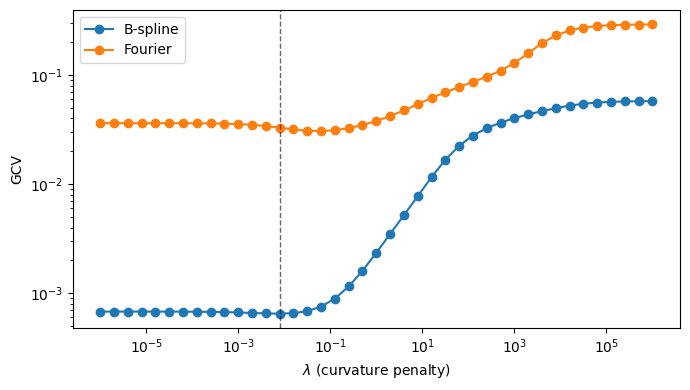

In [ ]:
# REFERENCE: Penalized B-Spline Functional Representation
#
# This implementation uses penalized B-splines (P-splines) for functional data
# representation, with smoothing parameter (lambda) selection via Generalized
# Cross-Validation (GCV), as described in:
#   Ramsay, J. O.; Silverman, B. W. (2005). Functional Data Analysis, 2nd ed.
#   Springer, Chapters 4-5.
#
# The approach represents each PSD curve as a linear combination of B-spline basis
# functions, with a roughness penalty controlled by lambda to balance fit and
# smoothness. GCV provides an automated, data-driven criterion for selecting the
# optimal lambda value.

def design_matrix(basis, t):
    M = np.asarray(basis(t)); return M.reshape(M.shape[0], -1).T          # [n_points, n_basis]

def penalty_matrix(basis, order=PENALTY_ORDER):
    return np.asarray(gram_matrix(LinearDifferentialOperator(order), basis))

def gcv_curve(lam, Phi, Y, Pmat):
    """Y: [n_curves, n_points]. Returns average GCV and effective degrees of freedom (edf)."""
    n = Phi.shape[0]
    A = Phi.T @ Phi + lam * Pmat
    Ainv_Phit = np.linalg.solve(A, Phi.T)          # [n_basis, n_points]
    H = Phi @ Ainv_Phit                             # smoothing (hat) matrix [n_points, n_points]
    edf = np.trace(H)
    coefs = Ainv_Phit @ Y.T                          # [n_basis, n_curves]
    Yhat = (Phi @ coefs).T
    rss_per_curve = np.mean((Y - Yhat)**2, axis=1) * n
    gcv_per_curve = rss_per_curve / n / max(1 - edf/n, 1e-6)**2
    return float(gcv_per_curve.mean()), float(edf)

def best_lambda(Phi, Y, Pmat, grid=LAMBDA_GRID):
    scores = [(lam,) + gcv_curve(lam, Phi, Y, Pmat) for lam in grid]
    lam, gcv, edf = min(scores, key=lambda s: s[1])
    return lam, gcv, edf, scores

# sample of curves (electrodes from several subjects across all groups) to pick basis + lambda
rng0 = np.random.default_rng(0)
sample = np.concatenate([np.stack(subjects[g][:min(20, len(subjects[g]))]).reshape(-1, T) for g in [0,1,2]], 0)
sample = sample[rng0.choice(len(sample), size=min(300, len(sample)), replace=False)]

candidates = {
    "B-spline": BSplineBasis(domain_range=(FMIN, FMAX), n_basis=N_BASIS_RICH, order=BSPLINE_ORDER),
    "Fourier":  FourierBasis(domain_range=(FMIN, FMAX), n_basis=N_BASIS_RICH + (1 - N_BASIS_RICH % 2)),  # odd
}

results = {}
for name, basis in candidates.items():
    Phi = design_matrix(basis, GRID)
    Pmat = penalty_matrix(basis)
    lam, gcv, edf, scores = best_lambda(Phi, sample, Pmat)
    results[name] = dict(basis=basis, Phi=Phi, Pmat=Pmat, lam=lam, gcv=gcv, edf=edf, scores=scores)
    print(f"  {name:9s}: lambda*={lam:.2e} | GCV={gcv:.4f} | effective degrees of freedom={edf:.1f} / {basis.n_basis} bases")

BASIS_TYPE = min(results, key=lambda k: results[k]['gcv'])
print(f"\n>>> SELECTED BASIS (penalized): {BASIS_TYPE}  (lambda*={results[BASIS_TYPE]['lam']:.2e}, "
      f"edf={results[BASIS_TYPE]['edf']:.1f})")

plt.figure(figsize=(7,4))
for name, r in results.items():
    lams, gcvs, _ = zip(*r["scores"])
    plt.plot(lams, gcvs, "o-", label=name)
plt.axvline(results[BASIS_TYPE]["lam"], color="k", ls="--", lw=1, alpha=.6)
plt.xscale("log"); plt.yscale("log")
plt.xlabel(r"$\lambda$ (curvature penalty)"); plt.ylabel("GCV")
plt.legend(); plt.title(""); plt.tight_layout(); plt.show()


## 4. Visual check: PSD vs. unpenalized vs. penalized (GCV) reconstruction


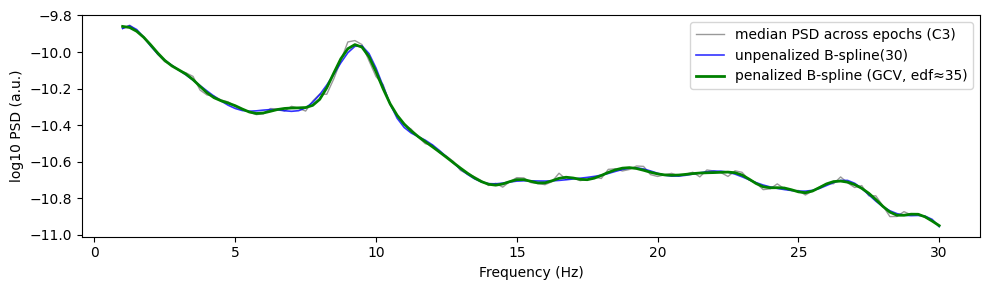

In [ ]:
BASIS = candidates[BASIS_TYPE]
LAMBDA_STAR = results[BASIS_TYPE]["lam"]
Phi_full = results[BASIS_TYPE]["Phi"]
Pmat_full = results[BASIS_TYPE]["Pmat"]

def fit_penalized(Y, Phi=Phi_full, Pmat=Pmat_full, lam=LAMBDA_STAR):
    """Y: [n_curves, n_points] -> coef [n_curves, n_basis]"""
    A = Phi.T @ Phi + lam * Pmat
    Ainv_Phit = np.linalg.solve(A, Phi.T)
    return (Ainv_Phit @ Y.T).T

# example: same C3 electrode, first Normal subject, for a direct comparison
ex = subjects[0][0][8]
fdg = FDataGrid(ex[None, :], grid_points=GRID)

# unpenalized B-spline(30), for reference
bb_demo = BSplineBasis(domain_range=(FMIN, FMAX), n_basis=30, order=4)
rec_unpen = fdg.to_basis(bb_demo)(GRID).ravel()

# penalized: basis + lambda chosen by GCV
coef_pen = fit_penalized(ex[None, :])
rec_pen = (Phi_full @ coef_pen[0])

y_label = "log10 PSD (a.u.)" if PSD_SCALE == "log10" else "PSD (a.u.)"
plt.figure(figsize=(10,3))
plt.plot(GRID, ex, color="0.6", lw=1, label=f"{PSD_AGG} PSD across epochs (C3)")
plt.plot(GRID, rec_unpen, "b", lw=1.2, alpha=.8, label="unpenalized B-spline(30)")
plt.plot(GRID, rec_pen, "g", lw=2, label=f"penalized {BASIS_TYPE} (GCV, edf\u2248{results[BASIS_TYPE]['edf']:.0f})")
plt.xlabel("Frequency (Hz)"); plt.ylabel(y_label); plt.legend()
plt.title("")
plt.tight_layout(); plt.show()


## 5. Functional representation of all electrodes and subjects (PSD curves)


In [ ]:
# REFERENCE: B-Spline Coefficient Representation and Gram-Weighted L2 Dissimilarity
#
# This implementation represents each functional curve by its B-spline basis coefficients
# and uses the Gram matrix to compute weighted L2 dissimilarities between curves,
# following the functional geostatistics framework described in:
#   Giraldo, R.; Delicado, P.; Mateu, J. (2011). "Ordinary kriging for function-valued
#   spatial data." Environ. Ecol. Stat., 18(3), 411–426.
#
# The Gram matrix accounts for the B-spline basis structure when computing distances
# between curves, ensuring that the dissimilarity measure properly reflects the
# functional nature of the data.

W = np.asarray(BASIS.gram_matrix())                 # Gram matrix [n_basis, n_basis]

def coefs_of_subject(sig):                          # sig: PSD curve [19, n_freq] -> coef [19, n_basis]
    return fit_penalized(sig)

coefs = {g: [coefs_of_subject(s) for s in subjects[g]] for g in [0,1,2]}
print("Coefficients per subject:", coefs[0][0].shape, "| Gram:", W.shape)
for g in [0,1,2]:
    print(f"  {GROUP_NAMES[g]:9s}: {len(coefs[g])} subjects with coefficients")


Coefficients per subject: (19, 40) | Gram: (40, 40)
  Normal   : 394 subjects with coefficients
  MCI      : 329 subjects with coefficients
  Dementia : 247 subjects with coefficients


## 5.1 Functional age residualization


In [ ]:
# AGE ADJUSTMENT METHODOLOGY
#
# This section implements an age-residualization approach for the functional PSD data.
# Rather than adjusting scalar variogram parameters post-hoc (as in earlier versions),
# we residualize the B-spline coefficients themselves by age BEFORE computing variograms
# or derived scalar parameters.
#
# For each of the 19 electrodes independently:
#   1. Age is centered on the sample mean and expanded in a CUBIC B-SPLINE basis (6 knots),
#      allowing for nonlinear age effects (not just a linear trend).
#   2. The design matrix includes diagnosis indicators (Normal = reference) and age-spline ×
#      diagnosis INTERACTIONS, permitting each clinical group to have its own age trajectory.
#   3. Ordinary least squares regression is fit for each channel's B-spline coefficient matrix,
#      pooling all subjects across the 3 groups in a single model.
#   4. For each subject, the model predicts their PSD-coefficient curve at:
#         a) their observed age and diagnosis
#         b) a common REFERENCE age (sample mean) with the SAME diagnosis
#      The difference represents the estimated, diagnosis-specific age effect for that subject.
#      Subtracting this from the raw coefficients projects every subject to the same reference
#      age while preserving diagnosis-related differences.
#
# The resulting coefs_age_adj maintains the same structure as coefs (per group, per subject,
# [19 channels, n_basis] arrays) and is used in place of coefs for all age-adjusted group
# comparisons in sections 15.1 and 18.1 below.

REFERENCE_AGE = float(np.nanmean(np.concatenate([np.asarray(AGES[g], dtype=float) for g in [0,1,2]])))
N_AGE_KNOTS = 6
AGE_SPLINE_DEGREE = 3

def _age_design_matrices(ages, groups, reference_age=REFERENCE_AGE,
                          n_knots=N_AGE_KNOTS, degree=AGE_SPLINE_DEGREE):
    """ages, groups: 1-D arrays (same length, same subject order), groups in {0,1,2}.
    Returns (X_design, X_design_reference, age_transformer) -- both design matrices share
    the SAME diagnosis columns (diagnosis is never changed), only the age-spline part
    differs (observed age vs. the common reference age)."""
    age_centered = (ages - reference_age).reshape(-1, 1)
    age_transformer = SplineTransformer(n_knots=n_knots, degree=degree, include_bias=False)
    age_spline = age_transformer.fit_transform(age_centered)

    diag_dummies = np.column_stack([(groups == g).astype(float) for g in [1, 2]])  # MCI, Dementia; Normal=ref
    interactions = np.column_stack([age_spline * diag_dummies[:, [j]] for j in range(diag_dummies.shape[1])])
    X = np.column_stack([np.ones(len(ages)), age_spline, diag_dummies, interactions])

    age_spline_ref = age_transformer.transform(np.zeros((len(ages), 1)))  # reference_age - reference_age = 0
    interactions_ref = np.column_stack([age_spline_ref * diag_dummies[:, [j]] for j in range(diag_dummies.shape[1])])
    X_ref = np.column_stack([np.ones(len(ages)), age_spline_ref, diag_dummies, interactions_ref])
    return X, X_ref

def residualize_functional_by_age(coefs, AGES):
    """coefs: dict {0,1,2: list of [19, n_basis] arrays, one per subject}.
    AGES: dict {0,1,2: list of ages, SAME order as coefs}.
    Returns coefs_adj with identical structure, age-residualized per channel (diagnosis
    effects preserved). Subjects with a missing/non-finite age are left UNADJUSTED (raw
    coefficients kept) and flagged, since they cannot be included in the age regression."""
    groups = [0, 1, 2]
    n_basis = coefs[0][0].shape[1]
    ages_all = np.concatenate([np.asarray(AGES[g], dtype=float) for g in groups])
    group_all = np.concatenate([np.full(len(AGES[g]), g) for g in groups])
    valid = np.isfinite(ages_all)
    n_missing = int((~valid).sum())
    if n_missing:
        print(f"  [age residualization] {n_missing} subject(s) missing age -- left unadjusted.")

    X_full, X_ref_full = _age_design_matrices(ages_all[valid], group_all[valid])

    coefs_adj = {g: [c.copy() for c in coefs[g]] for g in groups}
    flat_index = [(g, i) for g in groups for i in range(len(coefs[g]))]
    valid_flat_index = [fi for fi, v in zip(flat_index, valid) if v]

    for ch in range(N_CH):
        Y = np.stack([coefs[g][i][ch] for (g, i), v in zip(flat_index, valid) if v])  # [n_valid, n_basis]
        beta, *_ = np.linalg.lstsq(X_full, Y, rcond=None)
        age_effect = X_full @ beta - X_ref_full @ beta          # [n_valid, n_basis]
        Y_adj = Y - age_effect
        for (g, i), row in zip(valid_flat_index, Y_adj):
            coefs_adj[g][i][ch] = row
    return coefs_adj

coefs_age_adj = residualize_functional_by_age(coefs, AGES)
print(f"Reference age (sample mean): {REFERENCE_AGE:.2f}")
print("coefs_age_adj computed -- same structure as coefs, age-residualized per channel "
      "(diagnosis effects preserved).")

# --- Quick sanity check: age vs. alpha-band (8-13 Hz) power at a representative posterior
# channel, before vs. after -- should shrink noticeably within each group if the
# residualization worked as intended (mirrors the diagnostic in the codirector's example).
_alpha_mask = (GRID >= 8.0) & (GRID <= 13.0)
_ch_check = CANONICAL.index("O1") if "O1" in CANONICAL else 0
for g in [0, 1, 2]:
    ages_g = np.asarray(AGES[g], dtype=float)
    raw_alpha = np.array([np.log10(np.clip(np.trapz((10**s[_ch_check])[_alpha_mask], GRID[_alpha_mask]), 1e-12, None))
                           for s in subjects[g]])
    ok = np.isfinite(ages_g)
    r_raw = np.corrcoef(ages_g[ok], raw_alpha[ok])[0, 1] if ok.sum() > 2 else np.nan
    print(f"  {GROUP_NAMES[g]:9s} corr(age, {CANONICAL[_ch_check]} alpha power) raw = {r_raw:+.3f}")


Reference age (sample mean): 70.78
coefs_age_adj computed -- same structure as coefs, age-residualized per channel (diagnosis effects preserved).
  Normal    corr(age, O1 alpha power) raw = +0.014
  MCI       corr(age, O1 alpha power) raw = +0.000
  Dementia  corr(age, O1 alpha power) raw = +0.183


/tmp/ipykernel_1701/3255338267.py:97: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  raw_alpha = np.array([np.log10(np.clip(np.trapz((10**s[_ch_check])[_alpha_mask], GRID[_alpha_mask]), 1e-12, None))


### 5.2 Visual check: PSD curves before vs. after age adjustment


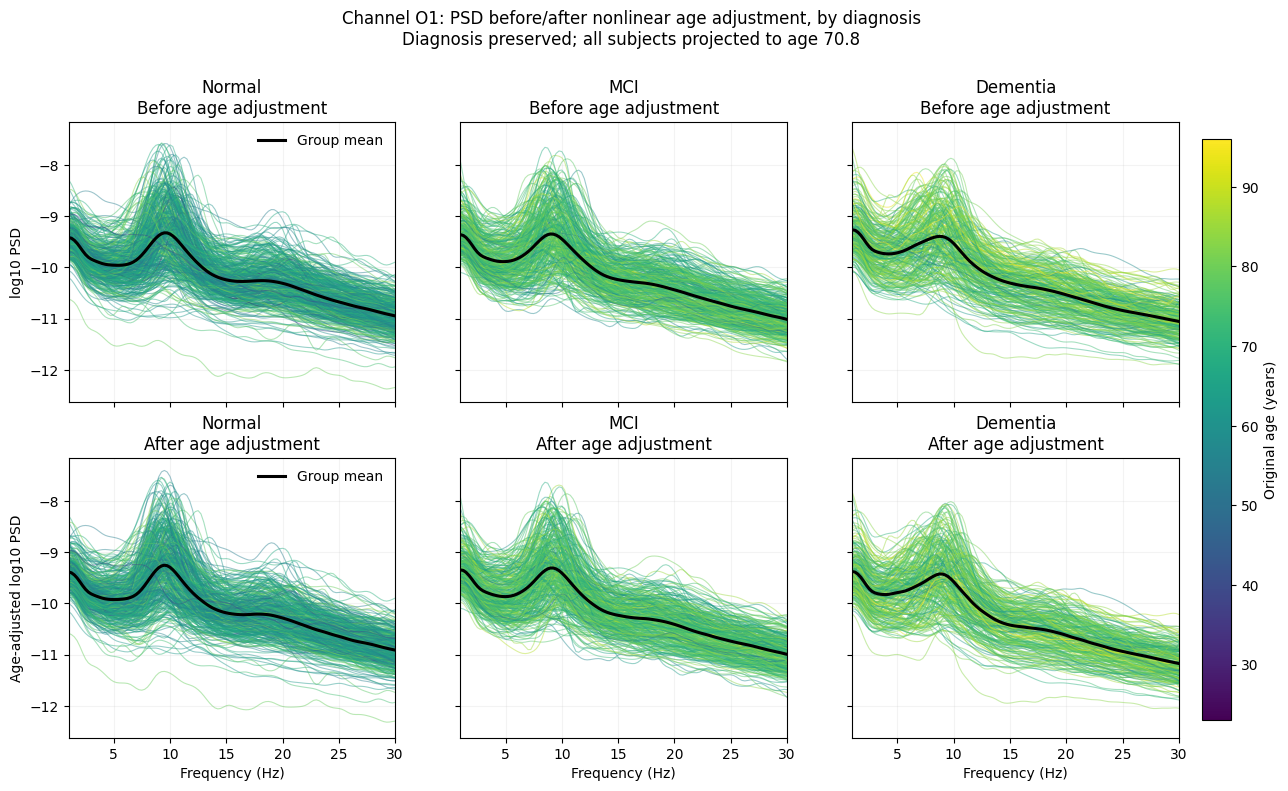

In [ ]:
# VISUAL DIAGNOSTIC OF AGE RESIDUALIZATION (SECTION 5.1)
#
# This visualization assesses the effectiveness of the age-adjustment procedure described
# above. Since we have 19 channels per subject (rather than a single curve), we display
# ONE representative channel: posterior O1, where the alpha peak is most prominent.
#
# The plots show PSD curves reconstructed from B-spline coefficients, comparing:
#   - Before age adjustment (top row)
#   - After age adjustment (bottom row)
#
# Each subject is colored by their original age. Three diagnostic groups are shown
# across columns for visual comparison.
#
# EXPECTED RESULTS IF ADJUSTMENT IS SUCCESSFUL:
#   - The "After" row should show substantially reduced age-related color gradients
#     (e.g., less systematic yellow-vs-purple separation in the alpha peak and
#     high-frequency tail regions)
#   - Between-group differences should remain visible across the three columns,
#     indicating that diagnosis-related signal was preserved while age effects
#     were removed

from matplotlib.colors import Normalize
from matplotlib import colormaps

CHECK_CHANNEL = "O1" if "O1" in CANONICAL else CANONICAL[0]
ch_idx = CANONICAL.index(CHECK_CHANNEL)

all_ages_flat = np.concatenate([np.asarray(AGES[g], dtype=float) for g in [0,1,2]])
age_norm = Normalize(vmin=np.nanmin(all_ages_flat), vmax=np.nanmax(all_ages_flat))
age_cmap = colormaps[plt.rcParams["image.cmap"]]

fig, axes = plt.subplots(2, 3, figsize=(15,8), sharex=True, sharey=True)

for col, g in enumerate([0,1,2]):
    ages_g = np.asarray(AGES[g], dtype=float)
    raw_curves    = np.stack([Phi_full @ coefs[g][i][ch_idx]         for i in range(len(coefs[g]))])
    adj_curves    = np.stack([Phi_full @ coefs_age_adj[g][i][ch_idx] for i in range(len(coefs[g]))])

    ax_before = axes[0, col]
    for age, curve in zip(ages_g, raw_curves):
        ax_before.plot(GRID, curve, color=age_cmap(age_norm(age)), alpha=0.45, linewidth=0.8)
    ax_before.plot(GRID, raw_curves.mean(axis=0), color="k", linewidth=2.2, label="Group mean")
    ax_before.set_title(f"{GROUP_NAMES[g]}\nBefore age adjustment")

    ax_after = axes[1, col]
    for age, curve in zip(ages_g, adj_curves):
        ax_after.plot(GRID, curve, color=age_cmap(age_norm(age)), alpha=0.45, linewidth=0.8)
    ax_after.plot(GRID, adj_curves.mean(axis=0), color="k", linewidth=2.2, label="Group mean")
    ax_after.set_title(f"{GROUP_NAMES[g]}\nAfter age adjustment")
    ax_after.set_xlabel("Frequency (Hz)")

axes[0,0].set_ylabel("log10 PSD"); axes[1,0].set_ylabel("Age-adjusted log10 PSD")
for ax in axes.ravel():
    ax.set_xlim(FMIN, FMAX); ax.grid(alpha=0.15)
axes[0,0].legend(frameon=False); axes[1,0].legend(frameon=False)

sm = plt.cm.ScalarMappable(norm=age_norm, cmap=age_cmap); sm.set_array([])
fig.colorbar(sm, ax=axes, fraction=0.025, pad=0.02, label="Original age (years)")
fig.suptitle(f"Channel {CHECK_CHANNEL}: PSD before/after nonlinear age adjustment, by diagnosis\n"
             f"Diagnosis preserved; all subjects projected to age {REFERENCE_AGE:.1f}", y=1.02)
plt.savefig("psd_age_adjustment_check.png", dpi=150, bbox_inches="tight"); plt.show()


### 5.3 Alternative dissimilarity metric: quantile-function representation for the Wasserstein distance

Computing quantile-function (Wasserstein) representation for all subjects...


100%|██████████| 247/247 [00:00<00:00, 842.43it/s]


Quantile-function shape per subject: (19, 200) (channels x quantile levels)


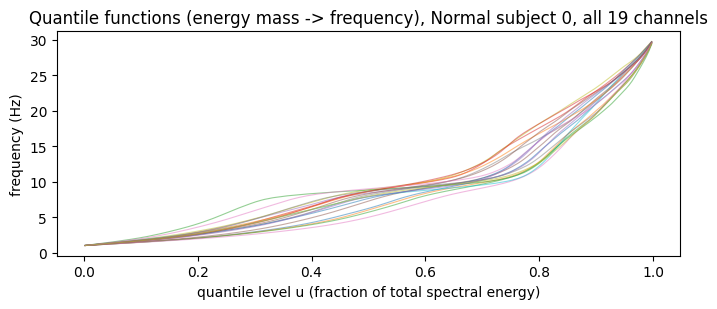

In [ ]:
# WASSERSTEIN DISTANCE METRIC (SECTIONS 6-19)
#
# Sections 6 through 19 quantify pairwise electrode dissimilarity using two different
# distance metrics:
#
# 1. L2 DISTANCE (BASELINE)
#    - Uses Gram-weighted squared L2 distance between B-spline COEFFICIENTS
#    - Equivalent to squared L2 distance between reconstructed PSD curves
#      (since W is the basis Gram matrix)
#    - Treats each PSD curve as a vector in Hilbert space
#    - Measures "vertical" differences in power at matched frequencies
#
# 2. WASSERSTEIN DISTANCE (OPTIMAL TRANSPORT)
#    - Treats each electrode's PSD curve as a distribution of ENERGY MASS along frequency
#    - Measures minimal "cost" (mass × distance moved) to transform one energy distribution
#      into another
#    - Sensitive to HORIZONTAL shifts (e.g., alpha peak frequency migration)
#    - This sensitivity addresses a limitation of purely vertical L2 distance
#
# For 1D densities, the SQUARED 2-Wasserstein distance has a closed-form solution:
#     W2^2(P_i, P_j) = ∫₀¹ (Q_i(u) - Q_j(u))² du
#
# where Q_i, Q_j are quantile functions (inverse CDFs).
#
# IMPORTANT: This computes the SQUARED 2-Wasserstein distance, matching the classical
# semivariogram's squared metric (0.5 × E[d(X,X')²]). This is NOT the 1-Wasserstein
# "earth mover's distance" returned by scipy.stats.wasserstein_distance.
#
# IMPLEMENTATION ADVANTAGE:
# This closed form allows complete reuse of existing functions for the coefficient-based
# representation. Simply:
#   - Replace B-spline coefficients Z with quantile-function vector Q
#   - Replace Gram matrix W with WQ = (1/N_QUANTILE) × I (midpoint rule integration)
#
# All downstream functions remain unchanged:
#   - trace_variogram
#   - regional_fvar
#   - channel_semivariance
#   - subject-level fits
#   - cluster-permutation tests

from scipy.integrate import cumulative_trapezoid

N_QUANTILE = 200   # number of quantile levels used to discretize each curve's inverse CDF
QLEVELS = (np.arange(N_QUANTILE) + 0.5) / N_QUANTILE   # midpoint rule over (0,1)
WQ = np.eye(N_QUANTILE) / N_QUANTILE   # "Gram matrix" for the quantile-function representation

# np.trapz was removed in NumPy>=2.0 (renamed to np.trapezoid); this keeps the new
# Wasserstein code working regardless of which NumPy version the notebook is run with.
_trapz = getattr(np, "trapezoid", None) or np.trapz

def curve_to_quantile_function(curve, grid=GRID, psd_scale=PSD_SCALE, qlevels=QLEVELS):
    """curve: PSD values on `grid` as stored (i.e. log10 PSD if PSD_SCALE=='log10').
    Returns the curve's quantile function (frequency, in Hz) evaluated at `qlevels` --
    treating the curve's LINEAR-scale power as a mass distribution over frequency."""
    lin = 10.0**np.asarray(curve, dtype=float) if psd_scale == "log10" else np.asarray(curve, dtype=float)
    lin = np.clip(lin, 0.0, None)
    mass = _trapz(lin, grid)
    if not np.isfinite(mass) or mass <= 0:
        return np.full(len(qlevels), grid.mean())   # degenerate fallback, should not occur for real PSDs
    cdf = cumulative_trapezoid(lin, grid, initial=0.0) / mass
    cdf[-1] = 1.0   # numerically pin the endpoint so np.interp never has to extrapolate
    return np.interp(qlevels, cdf, grid)

def coefs_to_quantile(Z, Phi=Phi_full):
    """Z: B-spline coefficients [19, n_basis] for one subject -> quantile-function
    representation [19, N_QUANTILE], reusing the same reconstruction (Phi @ coef) already
    used everywhere else in the notebook."""
    curves = Phi @ Z.T          # [n_freq, 19]
    return np.stack([curve_to_quantile_function(curves[:, ch]) for ch in range(curves.shape[1])])

print("Computing quantile-function (Wasserstein) representation for all subjects...")
coefs_qf = {g: [coefs_to_quantile(Z) for Z in tqdm(coefs[g])] for g in [0,1,2]}
print("Quantile-function shape per subject:", coefs_qf[0][0].shape, "(channels x quantile levels)")

# --- Visual sanity check: quantile functions for one example subject (electrode-wise) ---
_ex_g, _ex_i = 0, 0
plt.figure(figsize=(7,3.2))
for ch in range(N_CH):
    plt.plot(QLEVELS, coefs_qf[_ex_g][_ex_i][ch], alpha=0.5, lw=0.8)
plt.xlabel("quantile level u (fraction of total spectral energy)"); plt.ylabel("frequency (Hz)")
plt.title(f"Quantile functions (energy mass -> frequency), {GROUP_NAMES[_ex_g]} subject 0, all 19 channels")
plt.tight_layout(); plt.savefig("quantile_functions_example.png", dpi=150, bbox_inches="tight"); plt.show()


### 5.4 Alternative dissimilarity metric: Mahalanobis distance (covariance-whitened)

In [ ]:
# MAHALANOBIS DISTANCE METRIC
#
# This section introduces Mahalanobis distance as an alternative to:
#   - Gram-weighted L2 distance (Section 5): treats all basis-coefficient directions as equally informative
#   - Wasserstein/quantile-function distance (Section 5.3): based on optimal transport
#
# MAHALANOBIS APPROACH:
# The distance between two electrodes' B-spline coefficient vectors is computed by
# "whitening" the coefficient space using its empirical covariance matrix before
# measuring distance. This weighting scheme:
#   - DOWN-weights directions where coefficients vary substantially across the sample
#   - UP-weights directions that are typically near-constant
#
# IMPLEMENTATION:
# Reuses the SAME B-spline coefficients (coefs) from Section 5; only the weight matrix
# changes from W (Gram matrix) to W_MAHA = Σ⁻¹. All downstream functions remain unchanged:
#   - trace_variogram
#   - regional_fvar
#   - channel_semivariance
#   - fit_subject
#   - cluster-permutation routines
#
# COVARIANCE ESTIMATION:
# Σ is estimated POOLED across all 3 clinical groups. Every channel from every subject
# in every group contributes one n_basis-dimensional coefficient vector to a SINGLE
# shared empirical covariance matrix. This approach:
#   - Prevents injection of group-specific structure into the metric
#   - Ensures the metric itself is unbiased when later comparing those same groups

_all_coef_vectors = np.vstack([Z[ch] for g in [0,1,2] for Z in coefs[g] for ch in range(N_CH)])
print(f"Pooled sample for Sigma: {_all_coef_vectors.shape[0]} (channel x subject) vectors, "
      f"{_all_coef_vectors.shape[1]} B-spline coefficients each.")

_Sigma = np.cov(_all_coef_vectors, rowvar=False)
MAHA_SHRINKAGE = 1e-3   # small ridge shrinkage toward a scaled identity, for numerical safety
_shrink_target = (np.trace(_Sigma) / _Sigma.shape[0]) * np.eye(_Sigma.shape[0])
Sigma_reg = (1 - MAHA_SHRINKAGE) * _Sigma + MAHA_SHRINKAGE * _shrink_target
W_MAHA = np.linalg.inv(Sigma_reg)   # plays the SAME role as the Gram matrix W

print(f"Sigma condition number: raw={np.linalg.cond(_Sigma):.2e}, "
      f"regularized={np.linalg.cond(Sigma_reg):.2e}  (shrinkage={MAHA_SHRINKAGE})")


Pooled sample for Sigma: 18430 (channel x subject) vectors, 40 B-spline coefficients each.
Sigma condition number: raw=3.27e+04, regularized=1.48e+04  (shrinkage=0.001)


### 5.5 Alternative dissimilarity metric: Riemannian (Fisher-Rao) geodesic distance

In [ ]:
# FISHER-RAO (INFORMATION GEOMETRY) DISTANCE METRIC
#
# This section introduces the Fisher-Rao distance as an alternative metric that treats
# each electrode's normalized PSD as a probability density and measures the GEODESIC
# (arc-length) distance between two densities under the Fisher information metric.
#
# THEORETICAL BACKGROUND:
# For 1D densities, this metric has a classical closed form (Rao 1945) via the
# square-root-density / Hellinger embedding (widely used in information geometry and
# shape analysis; e.g., Srivastava et al.):
#
#   1. Map each density p to its square root: ψ = √p
#   2. Since ∫ ψ² df = ∫ p df = 1, ψ lies on the unit sphere of L²([FMIN,FMAX], df)
#   3. The geodesic (great-circle) distance between two such points is:
#        d_Riemann(p, q) = arccos( ∫ √p·√q df )
#
# This represents arc-length on the unit sphere and is fundamentally different from a
# chordal/Euclidean distance between ψ's (which would be the Hellinger distance, a linear
# approximation of this arc length).
#
# IMPLEMENTATION NOTE:
# Because this involves ARCCOS of an inner product (rather than a quadratic form),
# it cannot reuse the (coef, W) einsum trick from Sections 5.3/5.4. Instead, a small
# parallel set of functions is defined below:
#   - trace_variogram_riemann
#   - (mirroring trace_variogram, fit_subject, etc.)
#
# These functions follow the same structure as their counterparts, with the only
# difference being the inner product calculation using the Fisher-Rao formulation.

def _trapz_weights(grid):
    """Per-point trapezoidal quadrature weights for a 1-D grid (handles non-uniform grids)."""
    step = np.diff(grid)
    w = np.zeros(len(grid))
    w[:-1] += step / 2.0
    w[1:]  += step / 2.0
    return w

TRAPZ_W = _trapz_weights(GRID)
SQRT_TRAPZ_W = np.sqrt(TRAPZ_W)

def curve_to_sqrt_density(curve, grid=GRID, psd_scale=PSD_SCALE, sqrt_w=SQRT_TRAPZ_W, trapz_w=TRAPZ_W):
    """curve: PSD values on `grid` as stored (log10 PSD if PSD_SCALE=='log10'). Returns
    psi = sqrt(density) * sqrt(quadrature weight), so that a PLAIN dot product between two
    such vectors equals the weighted integral integral(sqrt(p)*sqrt(q)) df (i.e. psi lies on
    the unit sphere under the plain Euclidean inner product, by construction)."""
    lin = 10.0**np.asarray(curve, dtype=float) if psd_scale == "log10" else np.asarray(curve, dtype=float)
    lin = np.clip(lin, 0.0, None)
    mass = float(np.sum(lin * trapz_w))
    if not np.isfinite(mass) or mass <= 0:
        return np.zeros_like(grid)
    density = lin / mass
    return np.sqrt(density) * sqrt_w

def coefs_to_fisher(Z, Phi=Phi_full):
    """Z: B-spline coefficients [19, n_basis] for one subject -> square-root-density
    representation [19, n_freq], reusing the same reconstruction (Phi @ coef) used
    everywhere else in the notebook."""
    curves = Phi @ Z.T          # [n_freq, 19]
    return np.stack([curve_to_sqrt_density(curves[:, ch]) for ch in range(curves.shape[1])])

print("Computing square-root-density (Riemannian/Fisher-Rao) representation for all subjects...")
coefs_fisher = {g: [coefs_to_fisher(Z) for Z in tqdm(coefs[g])] for g in [0,1,2]}
print("Fisher representation shape per subject:", coefs_fisher[0][0].shape, "(channels x frequency bins)")

def trace_variogram_riemann(psi_list, D, nbins=NBINS_VARIOGRAM):
    """Empirical trace-variogram under the Riemannian (Fisher-Rao) geodesic distance.
    Mirrors trace_variogram (Section 6) exactly, except gamma_ij = 0.5*arccos(inner)^2
    instead of the Gram-weighted quadratic form -- no weight matrix W is needed here, the
    "weighting" is already baked into how psi was constructed (Section 5.5)."""
    iu = np.triu_indices(N_CH, 1); h = D[iu]
    edges = np.linspace(0, h.max()+1e-9, nbins+1); cen = 0.5*(edges[:-1]+edges[1:])
    num = np.zeros(nbins); cnt = np.zeros(nbins)
    b = np.clip(np.digitize(h, edges)-1, 0, nbins-1)
    for Psi in psi_list:                              # Psi: [19, n_freq]
        inner_full = Psi @ Psi.T                        # [19,19], ~Bhattacharyya coefficients
        inner = np.clip(inner_full[iu[0], iu[1]], -1.0, 1.0)
        gij = 0.5 * np.arccos(inner)**2                  # squared geodesic (radians^2)
        np.add.at(num, b, gij); np.add.at(cnt, b, 1.0)
    m = cnt > 0
    return cen[m], (num/np.maximum(cnt,1))[m], cnt[m]

# --- Sanity check: for the first Normal subject, compare the 3 functional metrics on the
# SAME electrode pair (Fp1-O1, a large physical AND expected spectral difference) ---
_chk_g, _chk_i = 0, 0
_i1, _i2 = CANONICAL.index("Fp1"), CANONICAL.index("O1")
_Zc = coefs[_chk_g][_chk_i]
_d_euclid = float(0.5*np.einsum('k,kl,l->', _Zc[_i1]-_Zc[_i2], W, _Zc[_i1]-_Zc[_i2]))
_d_maha   = float(0.5*np.einsum('k,kl,l->', _Zc[_i1]-_Zc[_i2], W_MAHA, _Zc[_i1]-_Zc[_i2]))
_Qc = coefs_qf[_chk_g][_chk_i]
_d_wass   = float(0.5*np.mean((_Qc[_i1]-_Qc[_i2])**2))
_Pc = coefs_fisher[_chk_g][_chk_i]
_d_riemann = float(0.5*np.arccos(np.clip(_Pc[_i1]@_Pc[_i2], -1, 1))**2)
print(f"\nExample subject, Fp1-O1 dissimilarity under each metric (NOT directly comparable in "
      f"scale, just a sanity check all 4 run and return a finite positive number):")
print(f"  Euclidean (Gram/L2):     {_d_euclid:.4f}")
print(f"  Wasserstein:             {_d_wass:.4f}")
print(f"  Mahalanobis:             {_d_maha:.4f}")
print(f"  Riemannian (Fisher-Rao): {_d_riemann:.4f}")


Computing square-root-density (Riemannian/Fisher-Rao) representation for all subjects...


100%|██████████| 247/247 [00:00<00:00, 2398.84it/s]

Fisher representation shape per subject: (19, 117) (channels x frequency bins)

Example subject, Fp1-O1 dissimilarity under each metric (NOT directly comparable in scale, just a sanity check all 4 run and return a finite positive number):
  Euclidean (Gram/L2):     1.7505
  Wasserstein:             1.0370
  Mahalanobis:             24.6696
  Riemannian (Fisher-Rao): 0.0181


## 6. Empirical trace-variogram

In [ ]:
# EMPIRICAL TRACE VARIOGRAM FOR FUNCTIONAL SPATIAL DATA
#
# This implementation follows the methodology for functional trace variograms as
# described in Giraldo, Delicado & Mateu (2011) for spatial data with functional values.
#
# COMPUTATION:
#   - Pairs of electrodes are grouped by their spatial distance
#   - Within each distance interval, the Gram-weighted L2 dissimilarity is averaged
#   - The Gram matrix accounts for the B-spline basis structure in the functional data
#
# THEORETICAL FOUNDATION:
# This follows the classical variogram formulation for spatial statistics
# (Cressie, N., Statistics for Spatial Data, Wiley, 1993), extended to the
# functional data context.
#
# The resulting trace variogram characterizes the spatial dependence structure of
# the functional PSD data across electrode locations on the scalp.

def trace_variogram(coef_list, W, D, nbins=NBINS_VARIOGRAM):
    iu = np.triu_indices(N_CH, 1); h = D[iu]
    edges = np.linspace(0, h.max()+1e-9, nbins+1); cen = 0.5*(edges[:-1]+edges[1:])
    num = np.zeros(nbins); cnt = np.zeros(nbins)
    b = np.clip(np.digitize(h, edges)-1, 0, nbins-1)
    for Z in coef_list:                              # Z: coef [19, n_basis]
        dif = Z[iu[0]] - Z[iu[1]]                     # [n_pairs, n_basis]
        gij = 0.5*np.einsum('pk,kl,pl->p', dif, W, dif)
        np.add.at(num, b, gij); np.add.at(cnt, b, 1.0)
    m = cnt > 0
    return cen[m], (num/np.maximum(cnt,1))[m], cnt[m]

## 7. Variogram models (exponential, spherical, Gaussian, Matérn) and weighted least-squares fit

In [ ]:
# REFERENCE: Classical Parametric Variogram Models
#
# This implementation fits classical parametric variogram models (exponential, spherical,
# Gaussian, and Matérn family) to empirical trace variograms using nonlinear least squares,
# following the spatial statistics framework described in:
#   Cressie, N. (1993). Statistics for Spatial Data. Wiley, Chapter 2.
#
# The fitted models characterize the spatial dependence structure of the functional data:
#   - Exponential:    γ(h) = c₀ + c₁(1 - exp(-h/φ))
#   - Spherical:      γ(h) = c₀ + c₁(1.5h/φ - 0.5(h/φ)³) for h ≤ φ
#   - Gaussian:       γ(h) = c₀ + c₁(1 - exp(-(h/φ)²))
#   - Matérn family:  γ(h) = c₀ + c₁(1 - (1/(2^(ν-1)Γ(ν)))(2√ν h/φ)^ν K_ν(2√ν h/φ))
#
# The nugget (c₀), partial sill (c₁), and range (φ) parameters provide interpretable
# summaries of spatial correlation, with the Matérn smoothness parameter (ν) offering
# additional flexibility in modeling the decay of spatial dependence.


def exponential(h, c0, c1, a): return c0 + c1*(1 - np.exp(-h/a))
def spherical(h, c0, c1, a):
    r = np.minimum(h/a, 1.0); return c0 + c1*(1.5*r - 0.5*r**3)
def gaussian(h, c0, c1, a): return c0 + c1*(1 - np.exp(-(h/a)**2))

from scipy.special import kv as _kv, gamma as _gamma_fn
def _matern_corr(h, a, nu):
    r = np.sqrt(2*nu) * np.maximum(np.asarray(h, dtype=float), 1e-10) / a
    corr = (2**(1 - nu) / _gamma_fn(nu)) * (r**nu) * _kv(nu, r)
    return np.where(np.asarray(h) <= 1e-10, 1.0, corr)

def matern_nu15(h, c0, c1, a): return c0 + c1*(1 - _matern_corr(h, a, 1.5))
def matern_nu25(h, c0, c1, a): return c0 + c1*(1 - _matern_corr(h, a, 2.5))

# REFERENCE: Matérn Variogram Models (Extended Family)
#
# Additional Matérn models with smoothness parameters ν = 1.5 and ν = 2.5 are included
# as candidate variogram models:
#   - ν = 0.5  → equivalent to the Exponential model
#   - ν → ∞    → equivalent to the Gaussian model
#
# The intermediate values ν = 1.5 and ν = 2.5 provide additional flexibility in
# modeling the decay shape of spatial dependence, covering behaviors not captured
# by the Exponential, Spherical, or Gaussian models alone.
#
# The Matérn covariance function is defined as:
#   C(h) = σ² * (1 / (2^(ν-1) Γ(ν))) * (√(2ν) h / φ)^ν * K_ν(√(2ν) h / φ)
#
# where K_ν is the modified Bessel function of the second kind, φ is the range
# parameter, and ν controls the smoothness of the underlying process.

MODELS = {
    "exponential": exponential,
    "spherical": spherical,
    "gaussian": gaussian,
    "matern_nu1.5": matern_nu15,
    "matern_nu2.5": matern_nu25,
}

def fit_model(f, cen, gamma, cnt):
    p0 = [max(gamma.min(),1e-6), max(gamma.max()-gamma.min(),1e-6), max(cen.mean(),1e-3)]
    bounds = ([0,0,1e-3], [gamma.max()*2+1e-6, gamma.max()*5+1e-6, cen.max()*5])
    popt,_ = curve_fit(f, cen, gamma, p0=p0, bounds=bounds, sigma=1/np.sqrt(np.maximum(cnt,1e-6)), maxfev=30000)
    pred = f(cen, *popt); rmse = float(np.sqrt(np.mean((pred-gamma)**2)))
    r2 = float(1 - ((gamma-pred)**2).sum()/(((gamma-gamma.mean())**2).sum()+1e-12))
    return popt, rmse, r2

## 8. Best model per category (Normal, MCI, Dementia) — all patients

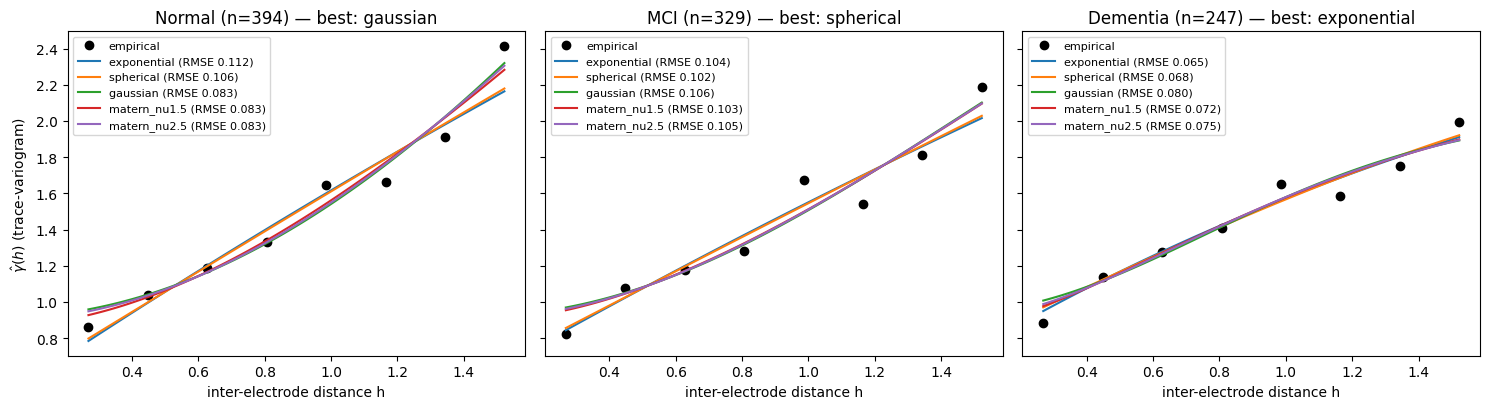

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15,4.2), sharey=True)
summary = []
for ax, g in zip(axes, [0,1,2]):
    cen, gamma, cnt = trace_variogram(coefs[g], W, DIST)
    ax.plot(cen, gamma, "ko", label="empirical")
    hh = np.linspace(cen.min(), cen.max(), 100)
    fits = {}
    for name, f in MODELS.items():
        try:
            popt, rmse, r2 = fit_model(f, cen, gamma, cnt); fits[name] = (popt, rmse, r2)
            ax.plot(hh, f(hh, *popt), label=f"{name} (RMSE {rmse:.3f})")
        except Exception as e:
            print(f"{GROUP_NAMES[g]} / {name}: fit failed ({e})")
    best = min(fits, key=lambda k: fits[k][1]); popt, rmse, r2 = fits[best]
    ax.set_title(f"{GROUP_NAMES[g]} (n={len(coefs[g])}) \u2014 best: {best}"); ax.set_xlabel("inter-electrode distance h")
    ax.legend(fontsize=8)
    summary.append((GROUP_NAMES[g], best, popt[0], popt[0]+popt[1], popt[2], rmse, r2, fits))
axes[0].set_ylabel(r"$\hat{\gamma}(h)$ (trace-variogram)")
plt.tight_layout(); plt.savefig("variogram_by_category.png", dpi=150, bbox_inches="tight"); plt.show()

### 8.1 Best model per category — Wasserstein metric

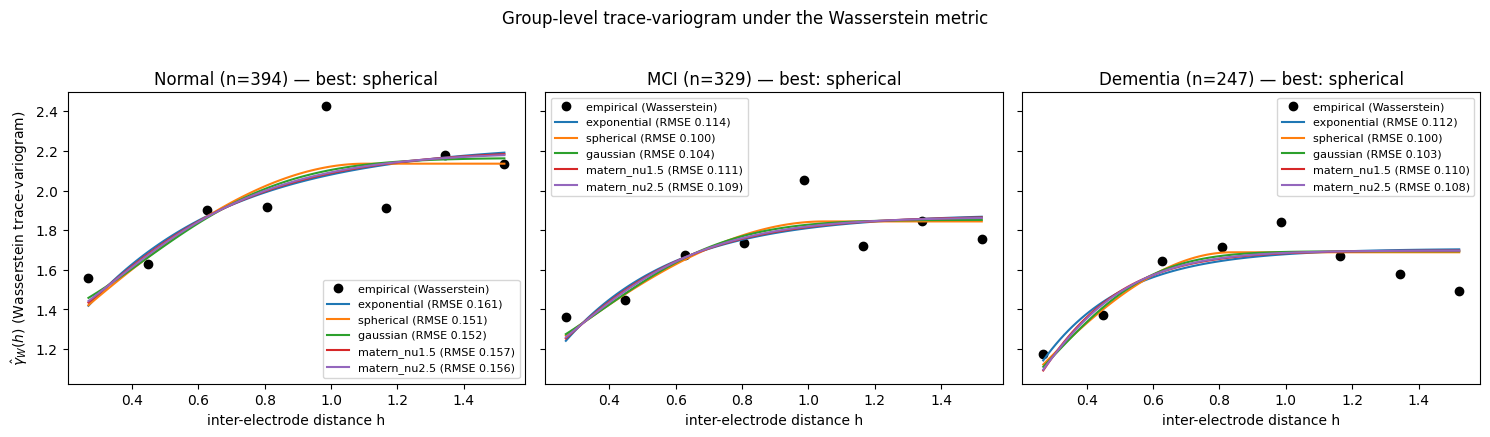

In [ ]:
# WASSERSTEIN-BASED TRACE VARIOGRAM
#
# This section reproduces the trace-variogram analysis from Section 8, but using the
# Wasserstein (optimal transport) metric instead of the Gram-weighted L2 distance.
#
# IMPLEMENTATION DETAILS:
#   - Empirical trace-variogram is built from the quantile-function representation
#     (coefs_qf) and the WQ "Gram" matrix (see Section 5.3)
#   - The dissimilarity between two electrodes' curves is their squared 2-Wasserstein
#     distance, rather than the squared Gram-weighted L2 distance
#
# CODE REUSE:
#   - trace_variogram() and fit_model() are REUSED UNCHANGED from Sections 6/7
#   - Only the inputs differ: coefs_qf replaces coefs, and WQ replaces W
#
# This demonstrates the modularity of the implementation: the same variogram
# infrastructure works with any distance metric that can be expressed as a
# quadratic form zᵀWz.

fig, axes = plt.subplots(1, 3, figsize=(15,4.2), sharey=True)
summary_qf = []
for ax, g in zip(axes, [0,1,2]):
    cen, gamma, cnt = trace_variogram(coefs_qf[g], WQ, DIST)
    ax.plot(cen, gamma, "ko", label="empirical (Wasserstein)")
    hh = np.linspace(cen.min(), cen.max(), 100)
    fits = {}
    for name, f in MODELS.items():
        try:
            popt, rmse, r2 = fit_model(f, cen, gamma, cnt); fits[name] = (popt, rmse, r2)
            ax.plot(hh, f(hh, *popt), label=f"{name} (RMSE {rmse:.3f})")
        except Exception as e:
            print(f"{GROUP_NAMES[g]} / {name}: fit failed ({e})")
    best = min(fits, key=lambda k: fits[k][1]); popt, rmse, r2 = fits[best]
    ax.set_title(f"{GROUP_NAMES[g]} (n={len(coefs_qf[g])}) \u2014 best: {best}"); ax.set_xlabel("inter-electrode distance h")
    ax.legend(fontsize=8)
    summary_qf.append((GROUP_NAMES[g], best, popt[0], popt[0]+popt[1], popt[2], rmse, r2, fits))
axes[0].set_ylabel(r"$\hat{\gamma}_{W}(h)$ (Wasserstein trace-variogram)")
fig.suptitle("Group-level trace-variogram under the Wasserstein metric", y=1.03)
plt.tight_layout(); plt.savefig("variogram_by_category_wasserstein.png", dpi=150, bbox_inches="tight"); plt.show()


### 8.2 Best model per category — Mahalanobis metric

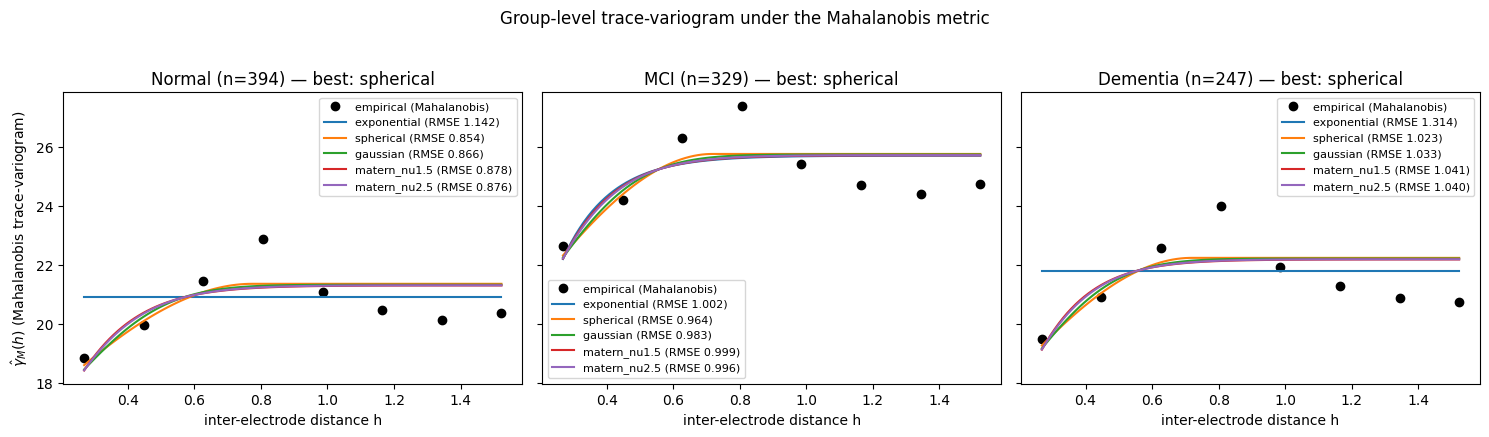

In [ ]:
# MAHALANOBIS-BASED TRACE VARIOGRAM
#
# This section reproduces the trace-variogram analysis from Section 8, but using the
# Mahalanobis distance metric instead of the Gram-weighted L2 distance.
#
# IMPLEMENTATION DETAILS:
#   - Empirical trace-variogram is built from the B-spline coefficient representation
#     (coefs) with the Mahalanobis weight matrix W_MAHA = Σ⁻¹ (see Section 5.4)
#   - The dissimilarity between two electrodes' curves is their Mahalanobis distance,
#     which whitens the coefficient space by its empirical covariance before measuring
#     distance
#
# CODE REUSE:
#   - trace_variogram() and fit_model() are REUSED UNCHANGED from Sections 6/7
#   - Only the inputs differ: W_MAHA replaces W (Gram matrix)
#
# This demonstrates the modularity of the implementation: the same variogram
# infrastructure works with any distance metric that can be expressed as a
# quadratic form zᵀWz.

fig, axes = plt.subplots(1, 3, figsize=(15,4.2), sharey=True)
summary_maha = []
for ax, g in zip(axes, [0,1,2]):
    cen, gamma, cnt = trace_variogram(coefs[g], W_MAHA, DIST)
    ax.plot(cen, gamma, "ko", label="empirical (Mahalanobis)")
    hh = np.linspace(cen.min(), cen.max(), 100)
    fits = {}
    for name, f in MODELS.items():
        try:
            popt, rmse, r2 = fit_model(f, cen, gamma, cnt); fits[name] = (popt, rmse, r2)
            ax.plot(hh, f(hh, *popt), label=f"{name} (RMSE {rmse:.3f})")
        except Exception as e:
            print(f"{GROUP_NAMES[g]} / {name}: fit failed ({e})")
    best = min(fits, key=lambda k: fits[k][1]); popt, rmse, r2 = fits[best]
    ax.set_title(f"{GROUP_NAMES[g]} (n={len(coefs[g])}) \u2014 best: {best}"); ax.set_xlabel("inter-electrode distance h")
    ax.legend(fontsize=8)
    summary_maha.append((GROUP_NAMES[g], best, popt[0], popt[0]+popt[1], popt[2], rmse, r2, fits))
axes[0].set_ylabel(r"$\hat{\gamma}_{M}(h)$ (Mahalanobis trace-variogram)")
fig.suptitle("Group-level trace-variogram under the Mahalanobis metric", y=1.03)
plt.tight_layout(); plt.savefig("variogram_by_category_mahalanobis.png", dpi=150, bbox_inches="tight"); plt.show()


### 8.3 Best model per category — Riemannian (Fisher-Rao) geodesic metric

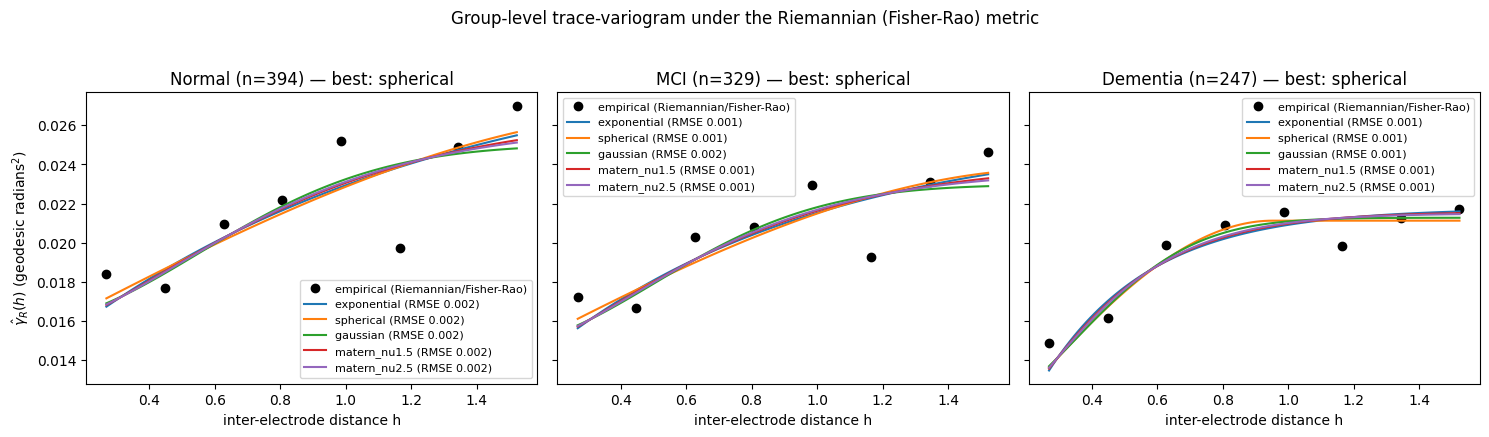

In [ ]:
# FISHER-RAO (RIEMANNIAN) TRACE VARIOGRAM
#
# This section reproduces the trace-variogram analysis from Section 8, but using the
# Fisher-Rao (information-geometry) distance metric.
#
# IMPLEMENTATION DETAILS:
#   - Empirical trace-variogram is built from the normalized PSD densities using the
#     Fisher-Rao geodesic distance (arc-length on the unit sphere under the Fisher
#     information metric)
#   - The dissimilarity between two electrodes' curves is computed as:
#       d_Riemann(p, q) = arccos( ∫ √p·√q df )
#
# CODE REUSE:
#   - trace_variogram_riemann() is used (see Section 5.5)
#   - This function mirrors trace_variogram() exactly, but implements the
#     geodesic distance formula directly
#   - No weight matrix argument is needed; the Riemannian metric is self-contained
#
# Unlike the previous metrics (Gram-weighted L2, Wasserstein, Mahalanobis), the
# Fisher-Rao distance cannot be expressed as a quadratic form zᵀWz, hence the
# separate function implementation while maintaining the same interface pattern.


fig, axes = plt.subplots(1, 3, figsize=(15,4.2), sharey=True)
summary_fisher = []
for ax, g in zip(axes, [0,1,2]):
    cen, gamma, cnt = trace_variogram_riemann(coefs_fisher[g], DIST)
    ax.plot(cen, gamma, "ko", label="empirical (Riemannian/Fisher-Rao)")
    hh = np.linspace(cen.min(), cen.max(), 100)
    fits = {}
    for name, f in MODELS.items():
        try:
            popt, rmse, r2 = fit_model(f, cen, gamma, cnt); fits[name] = (popt, rmse, r2)
            ax.plot(hh, f(hh, *popt), label=f"{name} (RMSE {rmse:.3f})")
        except Exception as e:
            print(f"{GROUP_NAMES[g]} / {name}: fit failed ({e})")
    best = min(fits, key=lambda k: fits[k][1]); popt, rmse, r2 = fits[best]
    ax.set_title(f"{GROUP_NAMES[g]} (n={len(coefs_fisher[g])}) \u2014 best: {best}"); ax.set_xlabel("inter-electrode distance h")
    ax.legend(fontsize=8)
    summary_fisher.append((GROUP_NAMES[g], best, popt[0], popt[0]+popt[1], popt[2], rmse, r2, fits))
axes[0].set_ylabel(r"$\hat{\gamma}_{R}(h)$ (geodesic radians$^2$)")
fig.suptitle("Group-level trace-variogram under the Riemannian (Fisher-Rao) metric", y=1.03)
plt.tight_layout(); plt.savefig("variogram_by_category_riemann.png", dpi=150, bbox_inches="tight"); plt.show()


## 9. Summary table: best-model parameters per category

In [ ]:
print(f"{'Group':10s} {'Best model':12s} {'nugget':>8s} {'sill':>8s} {'range':>8s} {'RMSE':>8s} {'R2':>7s}")
print("-"*70)
for name, best, nug, sill, rng_, rmse, r2, fits in summary:
    print(f"{name:10s} {best:12s} {nug:8.3f} {sill:8.3f} {rng_:8.3f} {rmse:8.4f} {r2:7.3f}")

print("\nGoodness of fit (RMSE) of the 5 models by group:")
print(f"{'Group':10s} " + " ".join(f"{m:>12s}" for m in MODELS))
for name, best, *_ , fits in summary:
    print(f"{name:10s} " + " ".join(f"{fits[m][1]:12.4f}" for m in MODELS) + f"   -> {best}")

print("\nReferences: Giraldo, Delicado & Mateu (2011), 'Ordinary kriging for function-valued spatial data';")
print("Ramsay & Silverman (2005), 'Functional Data Analysis'.")

Group      Best model     nugget     sill    range     RMSE      R2
----------------------------------------------------------------------
Normal     gaussian        0.913   12.980    4.324   0.0828   0.970
MCI        spherical       0.601    5.423    7.613   0.1021   0.939
Dementia   exponential     0.668    3.279    2.355   0.0650   0.962

Goodness of fit (RMSE) of the 5 models by group:
Group       exponential    spherical     gaussian matern_nu1.5 matern_nu2.5
Normal           0.1117       0.1060       0.0828       0.0833       0.0829   -> gaussian
MCI              0.1043       0.1021       0.1059       0.1032       0.1047   -> spherical
Dementia         0.0650       0.0678       0.0803       0.0720       0.0749   -> exponential

References: Giraldo, Delicado & Mateu (2011), 'Ordinary kriging for function-valued spatial data';
Ramsay & Silverman (2005), 'Functional Data Analysis'.


### 9.1 Summary table (Wasserstein) and direct comparison vs. Euclidean

In [ ]:
print("=== Group-level variogram parameters: Wasserstein metric ===")
print(f"{'Group':10s} {'Best model':12s} {'nugget':>8s} {'sill':>8s} {'range':>8s} {'RMSE':>8s} {'R2':>7s}")
print("-"*70)
for name, best, nug, sill, rng_, rmse, r2, fits in summary_qf:
    print(f"{name:10s} {best:12s} {nug:8.3f} {sill:8.3f} {rng_:8.3f} {rmse:8.4f} {r2:7.3f}")

print("\nGoodness of fit (RMSE) of the 5 models by group (Wasserstein):")
print(f"{'Group':10s} " + " ".join(f"{m:>12s}" for m in MODELS))
for name, best, *_ , fits in summary_qf:
    print(f"{name:10s} " + " ".join(f"{fits[m][1]:12.4f}" for m in MODELS) + f"   -> {best}")

print("\n=== Side-by-side: Euclidean (Gram/L2) vs. Wasserstein, group-level fit ===")
print(f"{'Group':10s} {'Metric':11s} {'Best model':12s} {'nugget':>8s} {'sill':>8s} {'range':>8s} {'RMSE':>8s} {'R2':>7s}")
print("-"*80)
for (nameE, bestE, nugE, sillE, rngE, rmseE, r2E, _), (nameW, bestW, nugW, sillW, rngW, rmseW, r2W, _) in zip(summary, summary_qf):
    print(f"{nameE:10s} {'Euclidean':11s} {bestE:12s} {nugE:8.3f} {sillE:8.3f} {rngE:8.3f} {rmseE:8.4f} {r2E:7.3f}")
    print(f"{'':10s} {'Wasserstein':11s} {bestW:12s} {nugW:8.3f} {sillW:8.3f} {rngW:8.3f} {rmseW:8.4f} {r2W:7.3f}")
print("\nNOTE: nugget/sill are NOT directly comparable in scale across metrics (Euclidean is "
      "in squared log10-PSD units via the Gram inner product; Wasserstein is in squared Hz, "
      "since it measures distance travelled along the frequency axis). Compare RANGE (both "
      "in the same inter-electrode-distance units h) and each metric\'s OWN relative pattern "
      "across groups/severity, rather than raw nugget/sill magnitudes across metrics.")


=== Group-level variogram parameters: Wasserstein metric ===
Group      Best model     nugget     sill    range     RMSE      R2
----------------------------------------------------------------------
Normal     spherical       1.023    2.136    1.103   0.1509   0.684
MCI        spherical       0.922    1.844    1.048   0.0997   0.758
Dementia   spherical       0.629    1.689    0.836   0.0997   0.743

Goodness of fit (RMSE) of the 5 models by group (Wasserstein):
Group       exponential    spherical     gaussian matern_nu1.5 matern_nu2.5
Normal           0.1606       0.1509       0.1518       0.1572       0.1557   -> spherical
MCI              0.1142       0.0997       0.1035       0.1107       0.1089   -> spherical
Dementia         0.1116       0.0997       0.1035       0.1098       0.1084   -> spherical

=== Side-by-side: Euclidean (Gram/L2) vs. Wasserstein, group-level fit ===
Group      Metric      Best model     nugget     sill    range     RMSE      R2
---------------------------

## 10. Analysis by brain region (channel grouping)

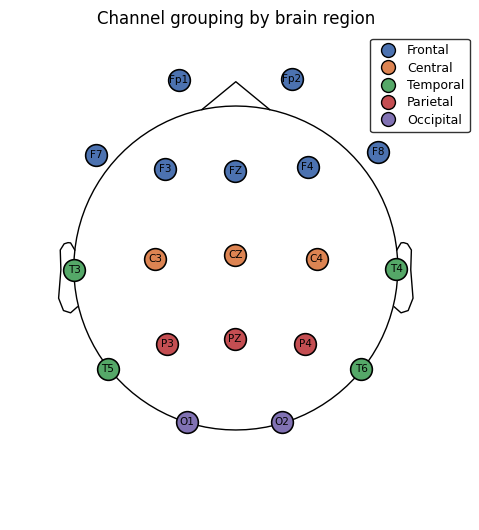

In [ ]:
# ---- BRAIN REGIONS (10-20 CHANNEL GROUPINGS) ----
#
# This section defines regional channel groupings based on the standard 10-20
# montage, following conventional EEG neuroanatomical divisions.
#
# The 19 channels are partitioned into the following regions:
#   - Frontal:      Fp1, Fp2, F7, F3, FZ, F4, F8
#   - Central:      T3, C3, CZ, C4, T4
#   - Parietal:     T5, P3, PZ, P4, T6
#   - Occipital:    O1, O2
#
# These groupings are used for regional analyses, allowing examination of
# spatial patterns and group differences at the lobar level.

REGIONS = {
    "Frontal":   ['Fp1','Fp2','F7','F3','FZ','F4','F8'],
    "Central":   ['C3','CZ','C4'],
    "Temporal":  ['T3','T4','T5','T6'],
    "Parietal":  ['P3','PZ','P4'],
    "Occipital": ['O1','O2'],
}
name2idx = {c:i for i,c in enumerate(CANONICAL)}
REGION_IDX = {r: [name2idx[c] for c in chs] for r,chs in REGIONS.items()}
REGION_COLORS = {"Frontal":"#4C72B0","Central":"#DD8452","Temporal":"#55A868","Parietal":"#C44E52","Occipital":"#8172B3"}

from matplotlib.colors import ListedColormap
from matplotlib.lines import Line2D

# ---- HEAD PLOT BACKGROUND (FOR REGIONAL CHANNEL MAP) ----
#
# This section creates a blank head plot with the anatomical contour (outline, ears, nose)
# using the same SPHERE parameter as the rest of the notebook. Electrodes are then
# overlaid on this background, color-coded by brain region.
#
# The head background is generated using MNE's plotting utilities, which provide
# a consistent anatomical reference for visualizing channel locations and regional
# groupings across all figures in the notebook.
fig, ax = plt.subplots(figsize=(5.4,5.4))
mne.viz.plot_topomap(np.zeros(N_CH), TOPO_INFO, axes=ax, show=False, sensors=False,
                      contours=0, cmap=ListedColormap(["white"]), vlim=(0,1),
                      outlines="head", sphere=SPHERE)

for r, idxs in REGION_IDX.items():
    P = ELECTRODE_XY_PLOT[idxs]
    ax.scatter(P[:,0], P[:,1], s=245, facecolor=REGION_COLORS[r], edgecolor="black",
               linewidth=1.15, zorder=10, label=r)

# ---- CHANNEL LABELS ON REGIONAL HEAD MAP ----
#
# Each electrode position is displayed as a colored node, with the channel name
# centered inside the node for clear identification.
#
# This provides a visual reference for the 10-20 montage layout, with colors
# corresponding to the brain region groupings defined above.
for i, c in enumerate(CANONICAL):
    ax.text(ELECTRODE_XY_PLOT[i,0], ELECTRODE_XY_PLOT[i,1], c, ha="center", va="center",
            fontsize=7.5, color="black", zorder=11)

legend_handles = [Line2D([0],[0], marker="o", linestyle="none", markersize=10,
                          markerfacecolor=REGION_COLORS[r], markeredgecolor="black", label=r)
                   for r in REGIONS]
ax.legend(handles=legend_handles, loc="upper right", bbox_to_anchor=(1.03,1.00),
          frameon=True, facecolor="white", edgecolor="black", fontsize=9,
          handletextpad=0.5, labelspacing=0.35, borderpad=0.45)
ax.set_title("Channel grouping by brain region")
plt.tight_layout(); plt.show()


Region                Normal              MCI         Dementia
---------------------------------------------------------------
Frontal       1.002 ± 1.144   1.042 ± 1.015   1.066 ± 0.981
Central       0.614 ± 0.948   0.738 ± 1.392   0.719 ± 1.086
Temporal      0.799 ± 0.806   0.734 ± 0.796   0.855 ± 1.177
Parietal      0.319 ± 0.918   0.310 ± 0.350   0.411 ± 0.594
Occipital     0.169 ± 0.326   0.168 ± 0.334   0.224 ± 0.467


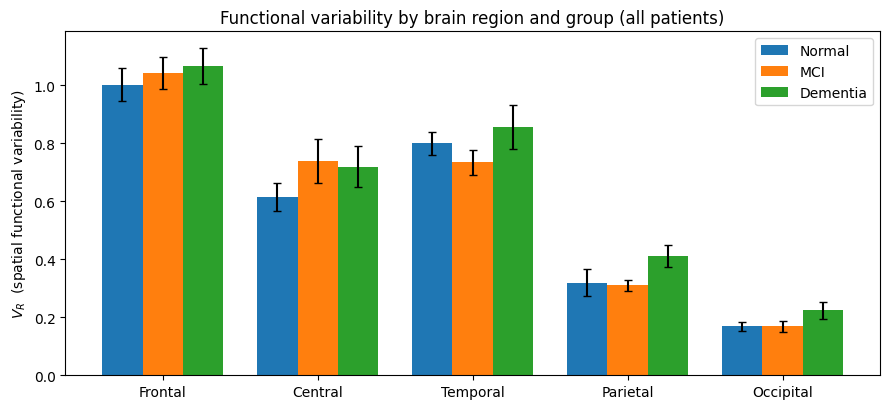

In [ ]:
# ---- SPATIAL FUNCTIONAL VARIABILITY BY REGION AND GROUP ----
#
# This section examines the spatial structure of functional variability across
# brain regions and clinical groups.
#
# Regional functional variability is quantified using the trace-variogram framework,
# allowing comparison of spatial dependence patterns between:
#   - Different brain regions (frontal, central, parietal, occipital)
#   - Clinical groups (Normal, MCI, Dementia)
#
# The analysis characterizes how functional dissimilarity between electrodes
# varies with spatial distance, and whether these spatial patterns differ
# across regions or diagnostic groups.

def regional_fvar(Z, W, idxs):
    C = Z[idxs]; cbar = C.mean(0); dif = C - cbar     # [nr, nb]
    return float(np.mean(np.einsum('rk,kl,rl->r', dif, W, dif)))

# per group and region: array of per-subject values
regvals = {r: {g: np.array([regional_fvar(Z, W, REGION_IDX[r]) for Z in coefs[g]]) for g in [0,1,2]}
           for r in REGIONS}

# mean +/- sd table
print(f"{'Region':11s} " + " ".join(f"{GROUP_NAMES[g]:>16s}" for g in [0,1,2]))
print("-"*63)
for r in REGIONS:
    print(f"{r:11s} " + " ".join(f"{regvals[r][g].mean():7.3f} \u00b1 {regvals[r][g].std():5.3f}" for g in [0,1,2]))

# grouped bars (region x group)
regs = list(REGIONS); x = np.arange(len(regs)); w = 0.26
plt.figure(figsize=(9,4.2))
for j,g in enumerate([0,1,2]):
    means = [regvals[r][g].mean() for r in regs]; sems = [regvals[r][g].std()/np.sqrt(len(regvals[r][g])) for r in regs]
    plt.bar(x+(j-1)*w, means, w, yerr=sems, capsize=3, label=GROUP_NAMES[g])
plt.xticks(x, regs); plt.ylabel(r"$V_R$  (spatial functional variability)")
plt.title("Functional variability by brain region and group (all patients)"); plt.legend()
plt.tight_layout(); plt.savefig("region_variability.png", dpi=150, bbox_inches="tight"); plt.show()

### 10.1 Trend and differences by region (Normal → MCI → Dementia)

In [ ]:
from scipy.stats import spearmanr, kruskal

def bh_fdr(p):
    p=np.asarray(p,float); n=len(p); o=np.argsort(p); r=p[o]
    q=np.minimum.accumulate((r*n/np.arange(1,n+1))[::-1])[::-1]
    out=np.empty(n); out[o]=np.clip(q,0,1); return out

rows=[]
for r in REGIONS:
    vals=np.concatenate([regvals[r][g] for g in [0,1,2]])
    sev =np.concatenate([np.full(len(regvals[r][g]), g) for g in [0,1,2]])
    rho,_=spearmanr(sev, vals)
    _,pk=kruskal(regvals[r][0], regvals[r][1], regvals[r][2])
    rows.append([r, rho, pk])
pk_fdr=bh_fdr([x[2] for x in rows])

print(f"{'Region':11s} {'rho(sev)':>9s} {'Kruskal p':>11s} {'p FDR':>9s}  trend")
print("-"*55)
for (r,rho,pk),q in zip(rows,pk_fdr):
    tend = "\u2191 with worsening severity" if rho>0 else ("\u2193 with worsening severity" if rho<0 else "\u2014")
    sig  = "*" if q<0.05 else " "
    print(f"{r:11s} {rho:+9.3f} {pk:11.4f} {q:9.4f}{sig}  {tend}")
print("\n(* FDR<0.05). High V_R = spatially more decorrelated functional field in the region.")

Region       rho(sev)   Kruskal p     p FDR  trend
-------------------------------------------------------
Frontal        +0.063      0.1357    0.1762   ↑ with worsening severity
Central        -0.007      0.9201    0.9201   ↓ with worsening severity
Temporal       -0.035      0.1410    0.1762   ↓ with worsening severity
Parietal       +0.132      0.0001    0.0004*  ↑ with worsening severity
Occipital      +0.073      0.0775    0.1762   ↑ with worsening severity

(* FDR<0.05). High V_R = spatially more decorrelated functional field in the region.


### 10.2 Sensitivity check: 3 regions with comparable electrode counts


Region                Normal              MCI         Dementia
---------------------------------------------------------------
Anterior      1.002 ± 1.144   1.042 ± 1.015   1.066 ± 0.981
Central       0.757 ± 0.966   0.880 ± 1.191   0.966 ± 0.954
Posterior     0.764 ± 0.696   0.695 ± 0.493   0.790 ± 0.775


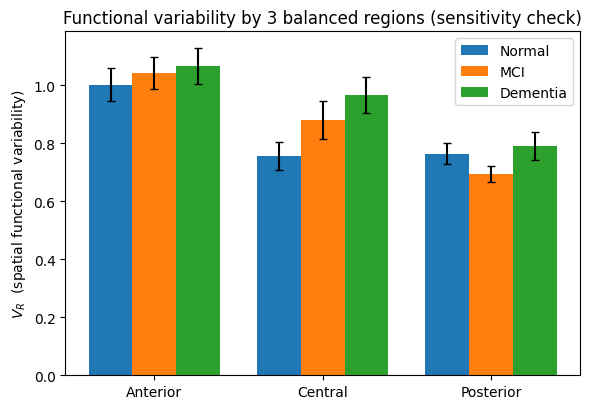


Region       rho(sev)   Kruskal p     p FDR  trend
-------------------------------------------------------
Anterior       +0.063      0.1357    0.2035   ↑ with worsening severity
Central        +0.114      0.0017    0.0050*  ↑ with worsening severity
Posterior      -0.004      0.4947    0.4947   ↓ with worsening severity

(* FDR<0.05). Compare against the 5-region result (Section 10.1): if the pattern of significance/direction is similar despite the more balanced electrode counts, the 5-region result is unlikely to be driven merely by how many channels each region has.


In [ ]:
# ---- SENSITIVITY ANALYSIS: REGIONAL GROUPINGS WITH BALANCED CHANNEL COUNTS ----
#
# The 5-region grouping used above has uneven channel distribution: Frontal (7 electrodes)
# versus Occipital (2 electrodes). This imbalance raises the question of whether the
# number of electrodes per region affects the comparison, as regions with fewer channels
# average over fewer pairs, potentially altering the variance/magnitude of the V_R
# estimator independently of clinical condition.
#
# To address this, the same analysis is repeated here using a coarser 3-region
# anatomical grouping with much more balanced channel counts (7/5/7 electrodes):
#   - Anterior/Frontal:  Fp1, Fp2, F7, F3, FZ, F4, F8  (7 channels)
#   - Central:           T3, C3, CZ, C4, T4            (5 channels)
#   - Posterior:         T5, P3, PZ, P4, T6, O1, O2    (7 channels)
#
# This serves as a sensitivity check to determine whether the observed regional
# differences are robust to the choice of regional parcellation.

REGIONS3 = {
    "Anterior":  ['Fp1','Fp2','F7','F3','FZ','F4','F8'],       # 7 channels
    "Central":   ['T3','C3','CZ','C4','T4'],                    # channels
    "Posterior": ['T5','P3','PZ','P4','T6','O1','O2'],          # 7 channels
}
REGION3_IDX = {r: [name2idx[c] for c in chs] for r,chs in REGIONS3.items()}

regvals3 = {r: {g: np.array([regional_fvar(Z, W, REGION3_IDX[r]) for Z in coefs[g]]) for g in [0,1,2]}
            for r in REGIONS3}

print(f"{'Region':11s} " + " ".join(f"{GROUP_NAMES[g]:>16s}" for g in [0,1,2]))
print("-"*63)
for r in REGIONS3:
    print(f"{r:11s} " + " ".join(f"{regvals3[r][g].mean():7.3f} \u00b1 {regvals3[r][g].std():5.3f}" for g in [0,1,2]))

regs3 = list(REGIONS3); x = np.arange(len(regs3)); w = 0.26
plt.figure(figsize=(6,4.2))
for j,g in enumerate([0,1,2]):
    means = [regvals3[r][g].mean() for r in regs3]
    sems  = [regvals3[r][g].std()/np.sqrt(len(regvals3[r][g])) for r in regs3]
    plt.bar(x+(j-1)*w, means, w, yerr=sems, capsize=3, label=GROUP_NAMES[g])
plt.xticks(x, regs3); plt.ylabel(r"$V_R$  (spatial functional variability)")
plt.title("Functional variability by 3 balanced regions (sensitivity check)"); plt.legend()
plt.tight_layout(); plt.savefig("region3_variability.png", dpi=150, bbox_inches="tight"); plt.show()

rows3 = []
for r in REGIONS3:
    vals = np.concatenate([regvals3[r][g] for g in [0,1,2]])
    sev  = np.concatenate([np.full(len(regvals3[r][g]), g) for g in [0,1,2]])
    rho, _ = spearmanr(sev, vals)
    _, pk  = kruskal(regvals3[r][0], regvals3[r][1], regvals3[r][2])
    rows3.append([r, rho, pk])
pk_fdr3 = bh_fdr([x[2] for x in rows3])

print(f"\n{'Region':11s} {'rho(sev)':>9s} {'Kruskal p':>11s} {'p FDR':>9s}  trend")
print("-"*55)
for (r,rho,pk),q in zip(rows3, pk_fdr3):
    tend = "\u2191 with worsening severity" if rho>0 else ("\u2193 with worsening severity" if rho<0 else "\u2014")
    sig  = "*" if q<0.05 else " "
    print(f"{r:11s} {rho:+9.3f} {pk:11.4f} {q:9.4f}{sig}  {tend}")
print("\n(* FDR<0.05). Compare against the 5-region result (Section 10.1): if the pattern of "
      "significance/direction is similar despite the more balanced electrode counts, the "
      "5-region result is unlikely to be driven merely by how many channels each region has.")


### 10.3 Regional functional variability — Wasserstein metric

=== V_R (Wasserstein, Hz^2) by region and group ===
Region                Normal              MCI         Dementia
---------------------------------------------------------------
Frontal       1.247 ± 1.055   1.139 ± 0.890   1.002 ± 0.837
Central       1.138 ± 1.887   0.889 ± 1.391   0.918 ± 1.565
Temporal      1.140 ± 0.982   1.043 ± 1.193   0.940 ± 0.935
Parietal      0.678 ± 0.716   0.548 ± 0.513   0.648 ± 0.739
Occipital     0.276 ± 0.453   0.231 ± 0.448   0.262 ± 0.598


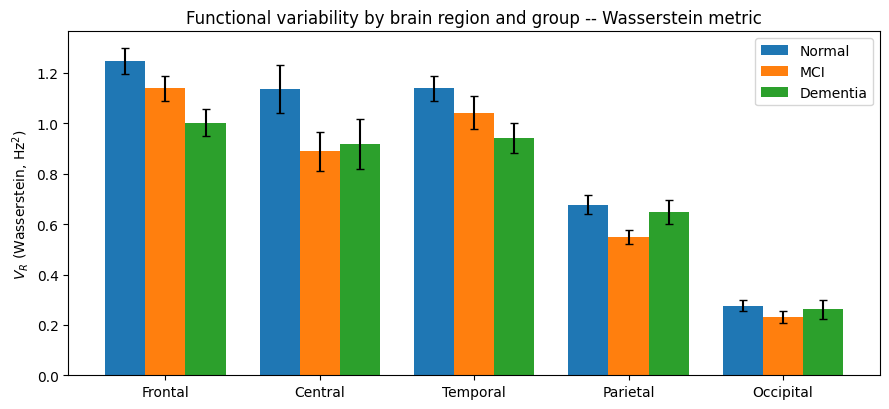


Region       rho(sev)   Kruskal p     p FDR  trend   (Wasserstein)
-------------------------------------------------------
Frontal        -0.100      0.0057    0.0095*  ↓ with worsening severity
Central        -0.175      0.0000    0.0000*  ↓ with worsening severity
Temporal       -0.107      0.0014    0.0034*  ↓ with worsening severity
Parietal       -0.048      0.0411    0.0489*  ↓ with worsening severity
Occipital      -0.067      0.0489    0.0489*  ↓ with worsening severity

=== Region-by-region agreement: does the severity-trend direction match between metrics? ===
Region       rho Euclidean  rho Wasserstein  Same sign?
Frontal              0.063           -0.100          no
Central             -0.007           -0.175         yes
Temporal            -0.035           -0.107         yes
Parietal             0.132           -0.048          no
Occipital            0.073           -0.067          no


In [ ]:
# REGIONAL FUNCTIONAL VARIABILITY: WASSERSTEIN METRIC
#
# This section reproduces the regional functional variability analysis (Section 10)
# using the Wasserstein distance metric instead of the Gram-weighted L2 distance.
#
# IMPLEMENTATION DETAILS:
#   - regional_fvar() is REUSED UNCHANGED from Section 10
#   - The function is generic with respect to the representation:
#       * Inputs: (Z, W, idxs) where Z is coefficient matrix and W is weight matrix
#       * For Wasserstein: pass coefs_qf (quantile functions) and WQ (midpoint-rule weights)
#       * For L2 baseline: pass coefs and W (Gram matrix)
#
# This demonstrates the flexibility of the implementation: the same regional
# variability function works with any distance metric expressible as a quadratic form.


regvals_qf = {r: {g: np.array([regional_fvar(Z, WQ, REGION_IDX[r]) for Z in coefs_qf[g]]) for g in [0,1,2]}
              for r in REGIONS}

print("=== V_R (Wasserstein, Hz^2) by region and group ===")
print(f"{'Region':11s} " + " ".join(f"{GROUP_NAMES[g]:>16s}" for g in [0,1,2]))
print("-"*63)
for r in REGIONS:
    print(f"{r:11s} " + " ".join(f"{regvals_qf[r][g].mean():7.3f} \u00b1 {regvals_qf[r][g].std():5.3f}" for g in [0,1,2]))

regs = list(REGIONS); x = np.arange(len(regs)); w = 0.26
plt.figure(figsize=(9,4.2))
for j,g in enumerate([0,1,2]):
    means = [regvals_qf[r][g].mean() for r in regs]; sems = [regvals_qf[r][g].std()/np.sqrt(len(regvals_qf[r][g])) for r in regs]
    plt.bar(x+(j-1)*w, means, w, yerr=sems, capsize=3, label=GROUP_NAMES[g])
plt.xticks(x, regs); plt.ylabel(r"$V_R$ (Wasserstein, Hz$^2$)")
plt.title("Functional variability by brain region and group -- Wasserstein metric"); plt.legend()
plt.tight_layout(); plt.savefig("region_variability_wasserstein.png", dpi=150, bbox_inches="tight"); plt.show()

rows_qf=[]
for r in REGIONS:
    vals=np.concatenate([regvals_qf[r][g] for g in [0,1,2]])
    sev =np.concatenate([np.full(len(regvals_qf[r][g]), g) for g in [0,1,2]])
    rho,_=spearmanr(sev, vals)
    _,pk=kruskal(regvals_qf[r][0], regvals_qf[r][1], regvals_qf[r][2])
    rows_qf.append([r, rho, pk])
pk_fdr_qf=bh_fdr([x[2] for x in rows_qf])

print(f"\n{'Region':11s} {'rho(sev)':>9s} {'Kruskal p':>11s} {'p FDR':>9s}  trend   (Wasserstein)")
print("-"*55)
for (r,rho,pk),q in zip(rows_qf,pk_fdr_qf):
    tend = "\u2191 with worsening severity" if rho>0 else ("\u2193 with worsening severity" if rho<0 else "\u2014")
    sig  = "*" if q<0.05 else " "
    print(f"{r:11s} {rho:+9.3f} {pk:11.4f} {q:9.4f}{sig}  {tend}")

print("\n=== Region-by-region agreement: does the severity-trend direction match between metrics? ===")
print(f"{'Region':11s} {'rho Euclidean':>14s} {'rho Wasserstein':>16s} {'Same sign?':>11s}")
for (r, rhoE, pkE), (_, rhoW, pkW) in zip(rows, rows_qf):
    print(f"{r:11s} {rhoE:14.3f} {rhoW:16.3f} {'yes' if np.sign(rhoE)==np.sign(rhoW) else 'no':>11s}")


## 11. Trace-variogram by condition (direct comparison)

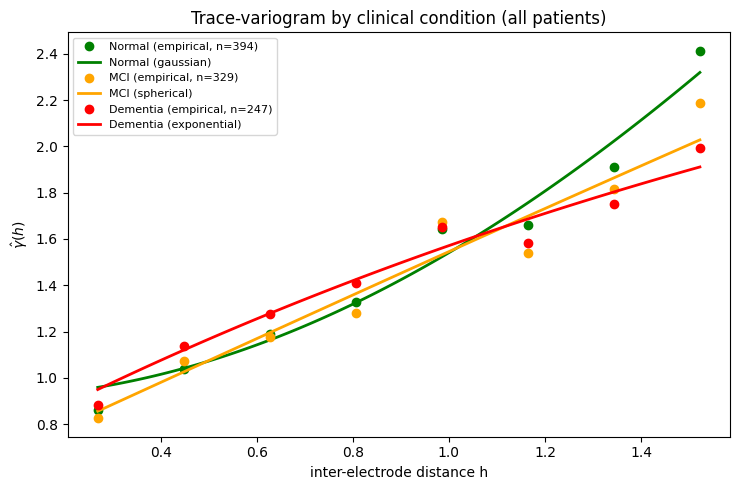

In [ ]:
COLG = {0:"green", 1:"orange", 2:"red"}
plt.figure(figsize=(7.5,5))
for g in [0,1,2]:
    cen, gamma, cnt = trace_variogram(coefs[g], W, DIST)
    plt.plot(cen, gamma, "o", color=COLG[g], label=f"{GROUP_NAMES[g]} (empirical, n={len(coefs[g])})")
    fits = {n: fit_model(f, cen, gamma, cnt) for n,f in MODELS.items()}
    best = min(fits, key=lambda k: fits[k][1]); popt = fits[best][0]
    hh = np.linspace(cen.min(), cen.max(), 120)
    plt.plot(hh, MODELS[best](hh, *popt), "-", color=COLG[g], lw=2, label=f"{GROUP_NAMES[g]} ({best})")
plt.xlabel("inter-electrode distance h"); plt.ylabel(r"$\hat{\gamma}(h)$")
plt.title("Trace-variogram by clinical condition (all patients)"); plt.legend(fontsize=8)
plt.tight_layout(); plt.savefig("variogram_by_condition.png", dpi=150, bbox_inches="tight"); plt.show()

### 11.1 Trace-variogram by condition — Wasserstein metric

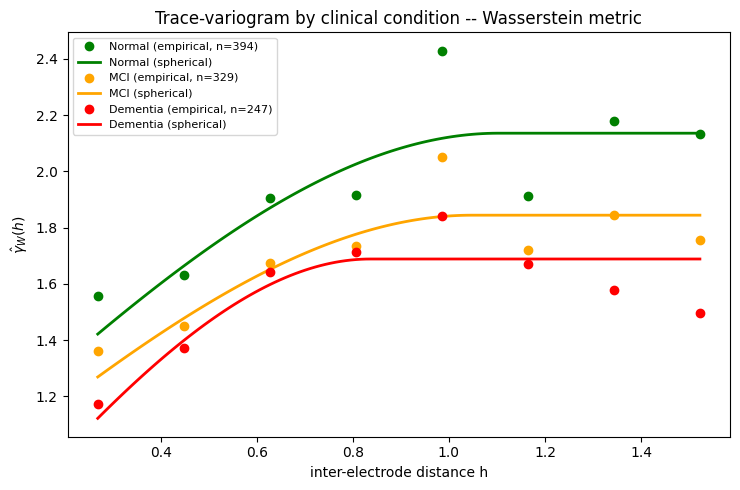

In [ ]:
plt.figure(figsize=(7.5,5))
for g in [0,1,2]:
    cen, gamma, cnt = trace_variogram(coefs_qf[g], WQ, DIST)
    plt.plot(cen, gamma, "o", color=COLG[g], label=f"{GROUP_NAMES[g]} (empirical, n={len(coefs_qf[g])})")
    fits = {n: fit_model(f, cen, gamma, cnt) for n,f in MODELS.items()}
    best = min(fits, key=lambda k: fits[k][1]); popt = fits[best][0]
    hh = np.linspace(cen.min(), cen.max(), 120)
    plt.plot(hh, MODELS[best](hh, *popt), "-", color=COLG[g], lw=2, label=f"{GROUP_NAMES[g]} ({best})")
plt.xlabel("inter-electrode distance h"); plt.ylabel(r"$\hat{\gamma}_W(h)$")
plt.title("Trace-variogram by clinical condition -- Wasserstein metric"); plt.legend(fontsize=8)
plt.tight_layout(); plt.savefig("variogram_by_condition_wasserstein.png", dpi=150, bbox_inches="tight"); plt.show()


## 12. Topomaps by condition

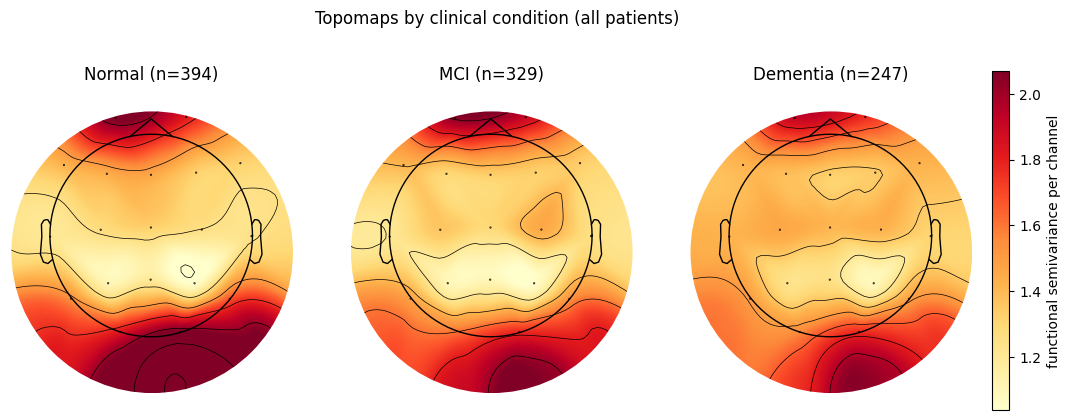

In [ ]:
# REFERENCE: Functional Semivariance by Electrode
#
# This implementation computes the functional semivariance for each individual
# electrode, using the same Gram-weighted L2 metric employed for the trace
# variogram, as described in:
#   Giraldo, R.; Delicado, P.; Mateu, J. (2011). "Ordinary kriging for function-valued
#   spatial data." Environ. Ecol. Stat., 18(3), 411–426.
#
# The channel-wise semivariance quantifies the average dissimilarity between a
# given electrode and all other electrodes, providing a measure of how each
# channel's functional curve deviates from the spatial average.
#
# IMPLEMENTATION:
#   For each channel i:
#     γ_i = (1/(2N)) * Σⱼ [ (Z_i - Z_j)ᵀ W (Z_i - Z_j) ]
#
# where Z are the B-spline coefficients, W is the weight matrix (Gram matrix,
# Mahalanobis, or other), and the sum is over all other channels j.

def channel_semivariance(coef_list, W):
    acc = np.zeros(N_CH)
    for Z in coef_list:
        Q = np.einsum('ik,kl,il->i', Z, W, Z)            # [19]
        Cross = Z @ W @ Z.T                               # [19,19]
        D2 = np.clip(Q[:,None] + Q[None,:] - 2*Cross, 0, None)  # int(Xi-Xj)^2
        np.fill_diagonal(D2, 0.0)
        acc += 0.5*D2.sum(1)/(N_CH-1)
    return acc/len(coef_list)

# --- TOPOMAP PLOTTING (MNE-BASED) ---
#
# This section implements topomap visualization using mne.viz.plot_topomap.
#
# IMPLEMENTATION RATIONALE:
# Previous versions used a hand-rolled interpolation with scipy.griddata
# ("cubic" method) over 19 irregularly-spaced electrode positions. This approach
# produced interpolation artifacts including:
#   - Ringing/overshoot effects
#   - Spurious "arrow"-like shapes
#   - A visible "topomap within a topomap" seam
#
# These artifacts are a known limitation of cubic griddata with sparse,
# non-uniform sampling points.
#
# MNE's plot_topomap addresses these issues by using a purpose-built
# interpolation method specifically designed for EEG scalp topography,
# combined with proper handling of the head outline, nose, and ears.
#
# IMPLEMENTATION:
# The function provides a thin wrapper around mne.viz.plot_topomap,
# maintaining the same interface while leveraging MNE's robust interpolation
# and visualization capabilities.

def plot_topomap(values, ax, title, vlim, cmap="YlOrRd", mask=None):
# --- TOPOMAP PLOTTING (MNE-BASED) ---
#
# This section implements topomap visualization using mne.viz.plot_topomap.
#
# IMPLEMENTATION DETAILS:
#   - Uses TOPO_INFO (full Info object with montage), NOT the bare ELECTRODE_XY array,
#     as the 'pos' argument. This enables MNE to draw the complete anatomical outline
#     (head + nose + EARS), producing a standard published-style topomap.
#   - Contours and electrode dots are included to match standard reference style.
#
# NOTES ON VISUALIZATION WITH SPARSE ELECTRODES:
# With only 19 electrodes (compared to 64+ in typical reference figures), a local
# extremum near a single channel can produce contour lines forming a small closed
# loop around that channel. This is an expected property of contour plots with
# sparse spatial sampling, not a rendering artifact. The anatomically correct
# head/ears/nose model makes this visually natural and interpretable.
    mask_params = dict(marker="o", markerfacecolor="none", markeredgecolor="lime",
                        markersize=12, markeredgewidth=2.2) if mask is not None else None
    im, _ = mne.viz.plot_topomap(
        values, TOPO_INFO, axes=ax, cmap=cmap, vlim=vlim, sensors=True,
        outlines="head", contours=6, sphere=SPHERE,
        mask=mask, mask_params=mask_params, show=False,
    )
    ax.set_title(title)
    return im

sv = {g: channel_semivariance(coefs[g], W) for g in [0,1,2]}
vmin = min(v.min() for v in sv.values()); vmax = max(v.max() for v in sv.values())
fig, axes = plt.subplots(1, 3, figsize=(13,4.4))
for ax, g in zip(axes, [0,1,2]):
    cf = plot_topomap(sv[g], ax, f"{GROUP_NAMES[g]} (n={len(coefs[g])})", (vmin,vmax), cmap="YlOrRd")
fig.colorbar(cf, ax=axes, fraction=0.025, pad=0.02, label="functional semivariance per channel")
fig.suptitle("Topomaps by clinical condition (all patients)", y=1.02)
plt.savefig("topomaps_by_condition.png", dpi=150, bbox_inches="tight"); plt.show()

### 12.1 Topomaps by condition — Wasserstein metric

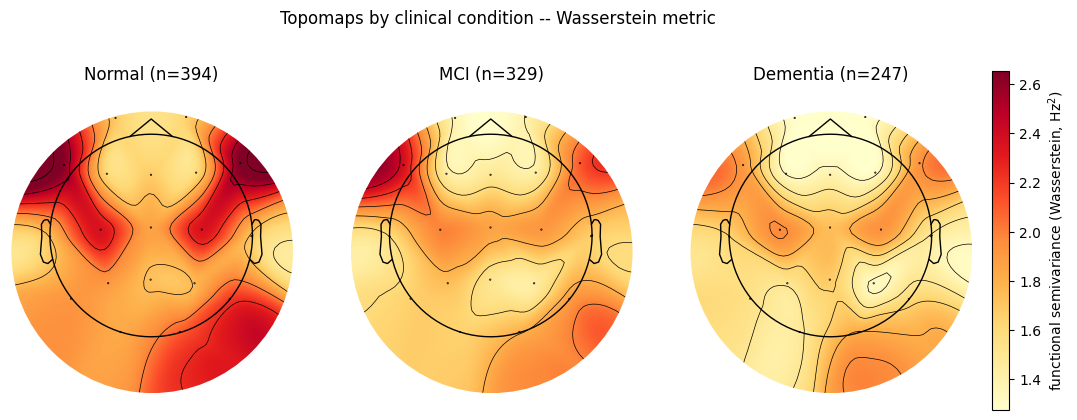

In [ ]:
sv_qf = {g: channel_semivariance(coefs_qf[g], WQ) for g in [0,1,2]}
vmin_qf = min(v.min() for v in sv_qf.values()); vmax_qf = max(v.max() for v in sv_qf.values())
fig, axes = plt.subplots(1, 3, figsize=(13,4.4))
for ax, g in zip(axes, [0,1,2]):
    cf = plot_topomap(sv_qf[g], ax, f"{GROUP_NAMES[g]} (n={len(coefs_qf[g])})", (vmin_qf,vmax_qf), cmap="YlOrRd")
fig.colorbar(cf, ax=axes, fraction=0.025, pad=0.02, label="functional semivariance (Wasserstein, Hz$^2$)")
fig.suptitle("Topomaps by clinical condition -- Wasserstein metric", y=1.02)
plt.savefig("topomaps_by_condition_wasserstein.png", dpi=150, bbox_inches="tight"); plt.show()


## 13. Normal vs. Abnormal grouping (MCI + Dementia), all patients

Class sizes (all patients):
  Normal  : 394 subjects
  Abnormal: 576 subjects


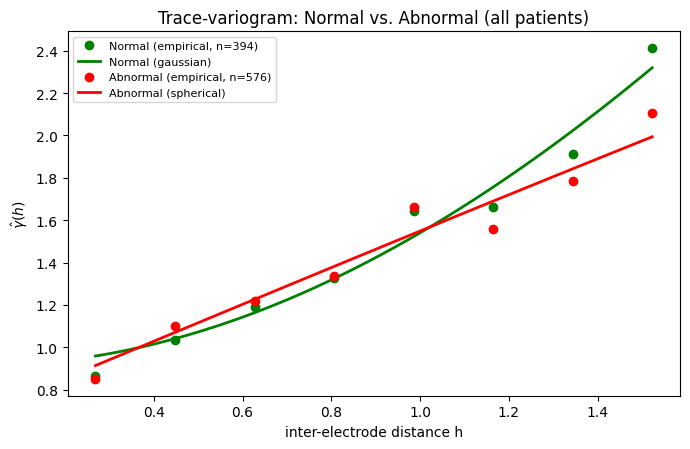

Group     model          nugget     sill    range     RMSE      R2
Normal    gaussian        0.913   12.980    4.324   0.0828   0.970
Abnormal  spherical       0.679    5.121    7.613   0.0838   0.951


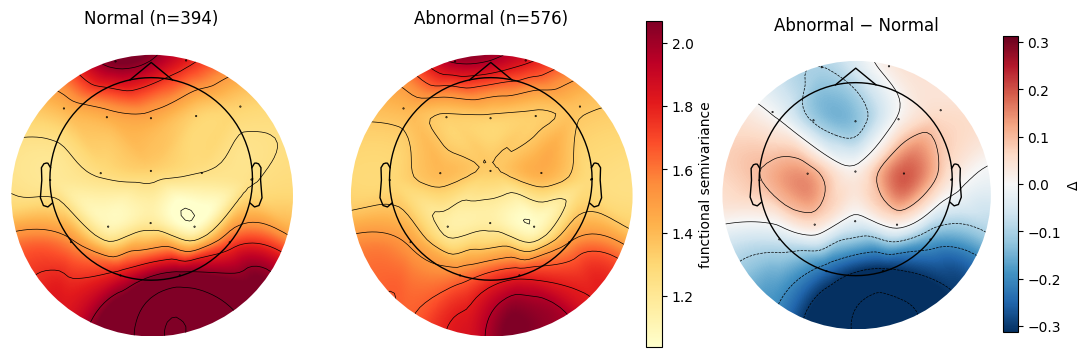

In [ ]:
# "Abnormal" = union of ALL available MCI and Dementia subjects (not a 40+40 subsample),
# compared against ALL Normal subjects.
coefs_bin = {"Normal": coefs[0], "Abnormal": coefs[1] + coefs[2]}
COLB = {"Normal":"green", "Abnormal":"red"}
print("Class sizes (all patients):")
for k, cl in coefs_bin.items():
    print(f"  {k:8s}: {len(cl)} subjects")

# --- trace-variogram Normal vs Abnormal ---
plt.figure(figsize=(7,4.6)); rows_bin=[]
for k, cl in coefs_bin.items():
    cen, gamma, cnt = trace_variogram(cl, W, DIST)
    plt.plot(cen, gamma, "o", color=COLB[k], label=f"{k} (empirical, n={len(cl)})")
    fits = {n: fit_model(f, cen, gamma, cnt) for n,f in MODELS.items()}
    best = min(fits, key=lambda kk: fits[kk][1]); popt, rmse, r2 = fits[best]
    hh=np.linspace(cen.min(),cen.max(),120); plt.plot(hh, MODELS[best](hh,*popt), "-", color=COLB[k], lw=2, label=f"{k} ({best})")
    rows_bin.append((k, best, popt[0], popt[0]+popt[1], popt[2], rmse, r2))
plt.xlabel("inter-electrode distance h"); plt.ylabel(r"$\hat{\gamma}(h)$")
plt.title("Trace-variogram: Normal vs. Abnormal (all patients)"); plt.legend(fontsize=8)
plt.tight_layout(); plt.savefig("variogram_normal_abnormal.png", dpi=150, bbox_inches="tight"); plt.show()

print(f"{'Group':9s} {'model':12s} {'nugget':>8s} {'sill':>8s} {'range':>8s} {'RMSE':>8s} {'R2':>7s}")
for k,b,nug,sill,rng_,rmse,r2 in rows_bin:
    print(f"{k:9s} {b:12s} {nug:8.3f} {sill:8.3f} {rng_:8.3f} {rmse:8.4f} {r2:7.3f}")

# --- topomaps Normal, Abnormal, and their difference ---
svb = {k: channel_semivariance(cl, W) for k,cl in coefs_bin.items()}
# --- TOPOMAP COLOR SCALING FIX ---
#
# BUG FIX: Previous versions passed a 15-level array (intended for contour 'levels')
# as the `vlim` parameter to mne.viz.plot_topomap, which expects a tuple (vmin, vmax).
# When this array was truncated to its first two values, the resulting vmax was
# artificially low, causing most channels to appear "saturated" in red.
#
# CORRECTION: Pass proper (vmin, vmax) tuples for color scaling.
#
# This ensures that the topomap color scale accurately represents the full range
# of the data, with appropriate minimum and maximum values for each panel.
vmn = min(v.min() for v in svb.values()); vmx = max(v.max() for v in svb.values())
vlim_shared = (vmn, vmx)
diff = svb["Abnormal"] - svb["Normal"]; dmax=np.abs(diff).max()
vlim_diff = (-dmax, dmax)
fig, ax = plt.subplots(1, 3, figsize=(13,4.4))
plot_topomap(svb["Normal"],  ax[0], f"Normal (n={len(coefs_bin['Normal'])})",  vlim_shared,  cmap="YlOrRd")
cf1=plot_topomap(svb["Abnormal"], ax[1], f"Abnormal (n={len(coefs_bin['Abnormal'])})", vlim_shared,  cmap="YlOrRd")
fig.colorbar(cf1, ax=ax[:2], fraction=0.025, pad=0.02, label="functional semivariance")
cf2=plot_topomap(diff, ax[2], "Abnormal \u2212 Normal", vlim_diff, cmap="RdBu_r")
fig.colorbar(cf2, ax=ax[2], fraction=0.05, pad=0.04, label="\u0394")
plt.savefig("topomaps_normal_abnormal.png", dpi=150, bbox_inches="tight"); plt.show()

### 13.1 Normal vs. Abnormal grouping — Wasserstein metric

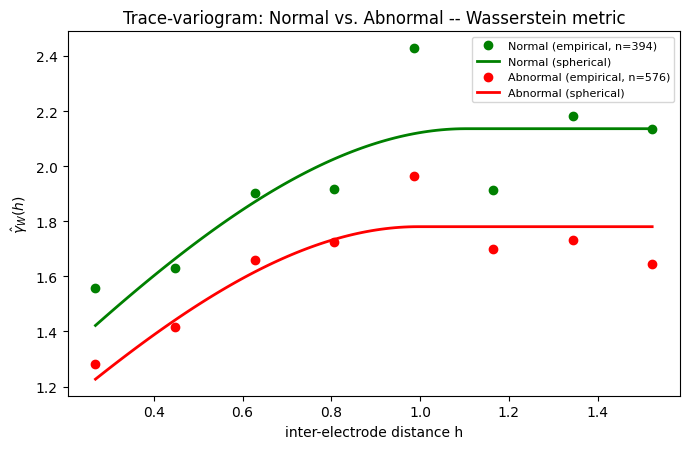

Group     model          nugget     sill    range     RMSE      R2
Normal    spherical       1.023    2.136    1.103   0.1509   0.684
Abnormal  spherical       0.865    1.780    0.995   0.0909   0.781


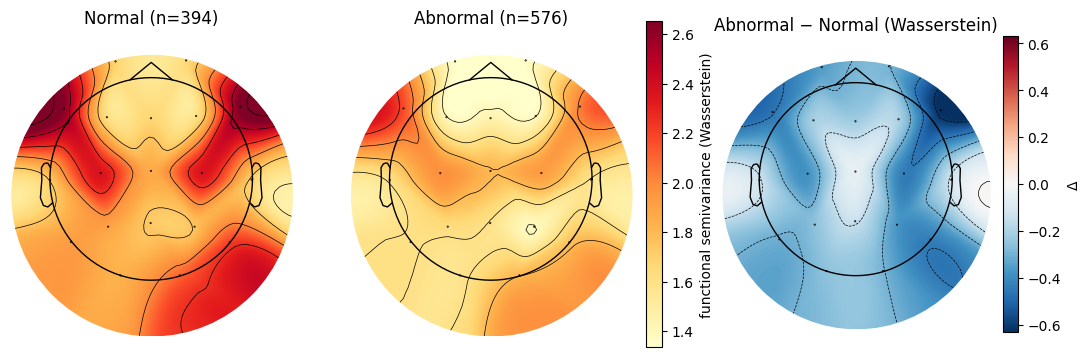

In [ ]:
coefs_bin_qf = {"Normal": coefs_qf[0], "Abnormal": coefs_qf[1] + coefs_qf[2]}

plt.figure(figsize=(7,4.6)); rows_bin_qf=[]
for k, cl in coefs_bin_qf.items():
    cen, gamma, cnt = trace_variogram(cl, WQ, DIST)
    plt.plot(cen, gamma, "o", color=COLB[k], label=f"{k} (empirical, n={len(cl)})")
    fits = {n: fit_model(f, cen, gamma, cnt) for n,f in MODELS.items()}
    best = min(fits, key=lambda kk: fits[kk][1]); popt, rmse, r2 = fits[best]
    hh=np.linspace(cen.min(),cen.max(),120); plt.plot(hh, MODELS[best](hh,*popt), "-", color=COLB[k], lw=2, label=f"{k} ({best})")
    rows_bin_qf.append((k, best, popt[0], popt[0]+popt[1], popt[2], rmse, r2))
plt.xlabel("inter-electrode distance h"); plt.ylabel(r"$\hat{\gamma}_W(h)$")
plt.title("Trace-variogram: Normal vs. Abnormal -- Wasserstein metric"); plt.legend(fontsize=8)
plt.tight_layout(); plt.savefig("variogram_normal_abnormal_wasserstein.png", dpi=150, bbox_inches="tight"); plt.show()

print(f"{'Group':9s} {'model':12s} {'nugget':>8s} {'sill':>8s} {'range':>8s} {'RMSE':>8s} {'R2':>7s}")
for k,b,nug,sill,rng_,rmse,r2 in rows_bin_qf:
    print(f"{k:9s} {b:12s} {nug:8.3f} {sill:8.3f} {rng_:8.3f} {rmse:8.4f} {r2:7.3f}")

svb_qf = {k: channel_semivariance(cl, WQ) for k,cl in coefs_bin_qf.items()}
vmn_qf = min(v.min() for v in svb_qf.values()); vmx_qf = max(v.max() for v in svb_qf.values())
vlim_shared_qf = (vmn_qf, vmx_qf)
diff_qf = svb_qf["Abnormal"] - svb_qf["Normal"]; dmax_qf=np.abs(diff_qf).max()
vlim_diff_qf = (-dmax_qf, dmax_qf)
fig, ax = plt.subplots(1, 3, figsize=(13,4.4))
plot_topomap(svb_qf["Normal"],  ax[0], f"Normal (n={len(coefs_bin_qf['Normal'])})",  vlim_shared_qf,  cmap="YlOrRd")
cf1=plot_topomap(svb_qf["Abnormal"], ax[1], f"Abnormal (n={len(coefs_bin_qf['Abnormal'])})", vlim_shared_qf,  cmap="YlOrRd")
fig.colorbar(cf1, ax=ax[:2], fraction=0.025, pad=0.02, label="functional semivariance (Wasserstein)")
cf2=plot_topomap(diff_qf, ax[2], "Abnormal \u2212 Normal (Wasserstein)", vlim_diff_qf, cmap="RdBu_r")
fig.colorbar(cf2, ax=ax[2], fraction=0.05, pad=0.04, label="\u0394")
plt.savefig("topomaps_normal_abnormal_wasserstein.png", dpi=150, bbox_inches="tight"); plt.show()


### 13.2 Normal vs. Abnormal grouping — Mahalanobis and Riemannian (Fisher-Rao) metrics

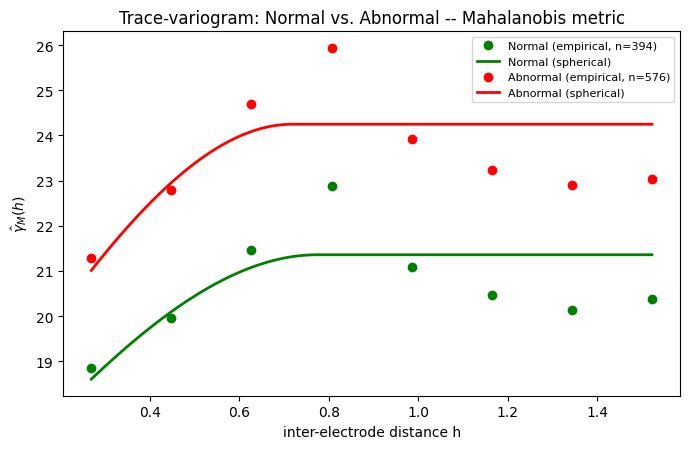

Group     model          nugget     sill    range     RMSE      R2   (Mahalanobis)
Normal    spherical      15.851   21.359    0.774   0.8542   0.411
Abnormal  spherical      17.284   24.249    0.718   0.9844   0.432


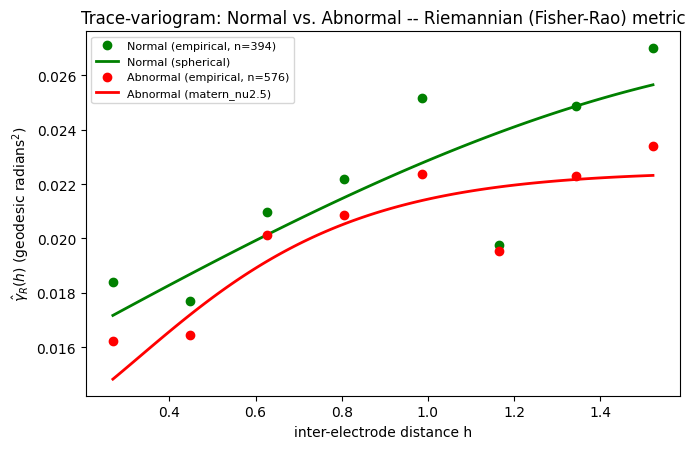


Group     model          nugget     sill    range     RMSE      R2   (Riemannian/Fisher-Rao)
Normal    spherical       0.015    0.027    2.036   0.0019   0.648
Abnormal  matern_nu2.5    0.013    0.022    0.458   0.0012   0.776


In [ ]:
# MAHALANOBIS-BASED FUNCTIONAL SEMIVARIANCE BY ELECTRODE
#
# This section reproduces the functional semivariance by electrode analysis
# (Section 13) using the Mahalanobis distance metric.
#
# IMPLEMENTATION DETAILS:
#   - Reuses the SAME coefs_bin dictionary already built in Section 13 (Euclidean)
#   - Only the weight matrix changes: W_MAHA replaces W (Gram matrix)
#   - channel_semivariance() is REUSED UNCHANGED, as it accepts any weight matrix
#
# This demonstrates the modularity of the implementation: the same semivariance
# infrastructure works with any distance metric expressible as a quadratic form.

plt.figure(figsize=(7,4.6)); rows_bin_maha=[]
for k, cl in coefs_bin.items():
    cen, gamma, cnt = trace_variogram(cl, W_MAHA, DIST)
    plt.plot(cen, gamma, "o", color=COLB[k], label=f"{k} (empirical, n={len(cl)})")
    fits = {n: fit_model(f, cen, gamma, cnt) for n,f in MODELS.items()}
    best = min(fits, key=lambda kk: fits[kk][1]); popt, rmse, r2 = fits[best]
    hh=np.linspace(cen.min(),cen.max(),120); plt.plot(hh, MODELS[best](hh,*popt), "-", color=COLB[k], lw=2, label=f"{k} ({best})")
    rows_bin_maha.append((k, best, popt[0], popt[0]+popt[1], popt[2], rmse, r2))
plt.xlabel("inter-electrode distance h"); plt.ylabel(r"$\hat{\gamma}_M(h)$")
plt.title("Trace-variogram: Normal vs. Abnormal -- Mahalanobis metric"); plt.legend(fontsize=8)
plt.tight_layout(); plt.savefig("variogram_normal_abnormal_mahalanobis.png", dpi=150, bbox_inches="tight"); plt.show()

print(f"{'Group':9s} {'model':12s} {'nugget':>8s} {'sill':>8s} {'range':>8s} {'RMSE':>8s} {'R2':>7s}   (Mahalanobis)")
for k,b,nug,sill,rng_,rmse,r2 in rows_bin_maha:
    print(f"{k:9s} {b:12s} {nug:8.3f} {sill:8.3f} {rng_:8.3f} {rmse:8.4f} {r2:7.3f}")

# --- Riemannian (Fisher-Rao) metric: needs its own bin grouping, from coefs_fisher ---
coefs_fisher_bin = {"Normal": coefs_fisher[0], "Abnormal": coefs_fisher[1] + coefs_fisher[2]}
plt.figure(figsize=(7,4.6)); rows_bin_fisher=[]
for k, cl in coefs_fisher_bin.items():
    cen, gamma, cnt = trace_variogram_riemann(cl, DIST)
    plt.plot(cen, gamma, "o", color=COLB[k], label=f"{k} (empirical, n={len(cl)})")
    fits = {n: fit_model(f, cen, gamma, cnt) for n,f in MODELS.items()}
    best = min(fits, key=lambda kk: fits[kk][1]); popt, rmse, r2 = fits[best]
    hh=np.linspace(cen.min(),cen.max(),120); plt.plot(hh, MODELS[best](hh,*popt), "-", color=COLB[k], lw=2, label=f"{k} ({best})")
    rows_bin_fisher.append((k, best, popt[0], popt[0]+popt[1], popt[2], rmse, r2))
plt.xlabel("inter-electrode distance h"); plt.ylabel(r"$\hat{\gamma}_R(h)$ (geodesic radians$^2$)")
plt.title("Trace-variogram: Normal vs. Abnormal -- Riemannian (Fisher-Rao) metric"); plt.legend(fontsize=8)
plt.tight_layout(); plt.savefig("variogram_normal_abnormal_riemann.png", dpi=150, bbox_inches="tight"); plt.show()

print(f"\n{'Group':9s} {'model':12s} {'nugget':>8s} {'sill':>8s} {'range':>8s} {'RMSE':>8s} {'R2':>7s}   (Riemannian/Fisher-Rao)")
for k,b,nug,sill,rng_,rmse,r2 in rows_bin_fisher:
    print(f"{k:9s} {b:12s} {nug:8.3f} {sill:8.3f} {rng_:8.3f} {rmse:8.4f} {r2:7.3f}")


### 13.3 Final consolidated table: parameter estimates across all 4 distance metrics

In [ ]:
# ============================================================================
# COMPARATIVE TABLE: VARIOGRAM PARAMETER ESTIMATES ACROSS METRICS
#
# This section generates a comprehensive table of variogram parameter estimates
# comparing all four distance metrics:
#   1. Euclidean (Gram/L2)
#   2. Wasserstein (optimal transport)
#   3. Mahalanobis (covariance-weighted)
#   4. Riemannian (Fisher-Rao / information geometry)
#
# For each metric, the table reports:
#   - Nugget (c₀): spatial variability at zero distance
#   - Partial Sill (c₁): total spatial variance contribution
#   - Sill (c₀ + c₁): overall variance plateau
#   - Range (φ): effective spatial correlation distance
#   - Best-fitting model: Exponential, Spherical, Gaussian, or Matérn (ν=1.5, 2.5)
#   - RMSE: root mean square error of the fitted model
#   - R²: coefficient of determination (goodness-of-fit)
#
# Estimates are provided for:
#   - Each clinical group: Normal, MCI, Dementia
#   - Binary grouping: Normal vs. Abnormal (MCI + Dementia pooled)
#
# This table addresses Criterion 1 (variogram goodness-of-fit) from the
# comparative evaluation framework.
# ============================================================================


METRIC_LABELS = ["Euclidean (Gram/L2)", "Wasserstein", "Mahalanobis", "Riemannian (Fisher-Rao)"]

three_group_summaries = {
    "Euclidean (Gram/L2)": summary,
    "Wasserstein": summary_qf,
    "Mahalanobis": summary_maha,
    "Riemannian (Fisher-Rao)": summary_fisher,
}
binary_summaries = {
    "Euclidean (Gram/L2)": rows_bin,
    "Wasserstein": rows_bin_qf,
    "Mahalanobis": rows_bin_maha,
    "Riemannian (Fisher-Rao)": rows_bin_fisher,
}

print("="*100)
print("FINAL TABLE -- variogram parameter estimates by metric and clinical grouping")
print("="*100)
header = f"{'Metric':24s} {'Group':10s} {'Best model':14s} {'Nugget':>9s} {'Sill':>9s} {'Range':>9s} {'RMSE':>9s} {'R2':>7s}"
print(header); print("-"*len(header))
_rows_export = []
for metric in METRIC_LABELS:
    for name, best, nug, sill, rng_, rmse, r2, *_ in three_group_summaries[metric]:
        print(f"{metric:24s} {name:10s} {best:14s} {nug:9.3f} {sill:9.3f} {rng_:9.3f} {rmse:9.4f} {r2:7.3f}")
        _rows_export.append([metric, name, best, nug, sill, rng_, rmse, r2])
    for name, best, nug, sill, rng_, rmse, r2 in binary_summaries[metric]:
        print(f"{metric:24s} {name:10s} {best:14s} {nug:9.3f} {sill:9.3f} {rng_:9.3f} {rmse:9.4f} {r2:7.3f}")
        _rows_export.append([metric, name, best, nug, sill, rng_, rmse, r2])
    print("-"*len(header))

print("\nNOTE on comparability (Criterion 1 -- variogram goodness of fit): RMSE/R2 ARE comparable")
print("WITHIN a metric across groups (same units), and the RANGE is on the same inter-electrode-")
print("distance scale across ALL 4 metrics. Nugget/sill are on DIFFERENT physical scales across")
print("metrics (squared log10-power for Euclidean/Mahalanobis, squared Hz for Wasserstein, squared")
print("radians for the Riemannian geodesic distance) -- compare each metric\'s OWN relative pattern")
print("across groups/severity, not raw nugget/sill numbers ACROSS metrics.")

final_table_df = pd.DataFrame(_rows_export, columns=["Metric","Group","BestModel","Nugget","Sill","Range","RMSE","R2"])
final_table_df.to_csv("final_variogram_parameter_table.csv", index=False)
final_table_df


FINAL TABLE -- variogram parameter estimates by metric and clinical grouping
Metric                   Group      Best model        Nugget      Sill     Range      RMSE      R2
--------------------------------------------------------------------------------------------------
Euclidean (Gram/L2)      Normal     gaussian           0.913    12.980     4.324    0.0828   0.970
Euclidean (Gram/L2)      MCI        spherical          0.601     5.423     7.613    0.1021   0.939
Euclidean (Gram/L2)      Dementia   exponential        0.668     3.279     2.355    0.0650   0.962
Euclidean (Gram/L2)      Normal     gaussian           0.913    12.980     4.324    0.0828   0.970
Euclidean (Gram/L2)      Abnormal   spherical          0.679     5.121     7.613    0.0838   0.951
--------------------------------------------------------------------------------------------------
Wasserstein              Normal     spherical          1.023     2.136     1.103    0.1509   0.684
Wasserstein              MCI    

,Metric,Group,BestModel,Nugget,Sill,Range,RMSE,R2
0,Euclidean (Gram/L2),Normal,gaussian,0.912535,12.979762,4.324486,0.082754,0.969502
1,Euclidean (Gram/L2),MCI,spherical,0.600834,5.422915,7.613198,0.102095,0.939132
2,Euclidean (Gram/L2),Dementia,exponential,0.668069,3.278870,2.355093,0.065002,0.962212
3,Euclidean (Gram/L2),Normal,gaussian,0.912535,12.979762,4.324486,0.082754,0.969502
4,Euclidean (Gram/L2),Abnormal,spherical,0.679109,5.120698,7.613198,0.083850,0.950982
5,Wasserstein,Normal,spherical,1.023214,2.135956,1.102958,0.150863,0.683776
6,Wasserstein,MCI,spherical,0.922223,1.844458,1.047635,0.099719,0.757650
7,Wasserstein,Dementia,spherical,0.629109,1.688704,0.836309,0.099716,0.743113
8,Wasserstein,Normal,spherical,1.023214,2.135956,1.102958,0.150863,0.683776
9,Wasserstein,Abnormal,spherical,0.865256,1.780327,0.995084,0.090926,0.780855


## 14. Subject-level variogram (nugget, sill, range, and model comparison)

In [ ]:
# ============================================================================
# SUBJECT-LEVEL VARIOGRAM FITTING: DISTRIBUTION-BASED GROUP COMPARISONS
#
# The group-level trace-variogram (Sections 6-9) aggregates all subjects within
# each group, producing a descriptive curve per group but providing only one
# observation per group — insufficient for formal statistical testing.
#
# APPROACH:
#   The 5 candidate variogram models (Exponential, Spherical, Gaussian, Matérn
#   ν=1.5, Matérn ν=2.5) are fitted to EACH SUBJECT INDIVIDUALLY, using only
#   that subject's 171 electrode pairs (19 channels → 19×18/2 pairs).
#
# OUTPUT:
#   Per-subject parameter estimates for each metric:
#     - Nugget (c₀)
#     - Partial Sill (c₁)
#     - Range (φ)
#     - Best-fitting model
#     - RMSE and R²
#
# This yields a per-group DISTRIBUTION of parameters (not just a single curve),
# enabling standard nonparametric group comparisons (e.g., Kruskal-Wallis,
# Mann-Whitney U tests) across Normal, MCI, and Dementia groups.
# ============================================================================

NBINS_SUBJECT = 7   # fewer bins than the group-level variogram (fewer pairs available per subject)

def trace_variogram_subject(Z, W, D, nbins=NBINS_SUBJECT):
    """Empirical trace-variogram for a SINGLE subject (Z: coef [19, n_basis])."""
    iu = np.triu_indices(N_CH, 1); h = D[iu]
    edges = np.linspace(0, h.max()+1e-9, nbins+1); cen = 0.5*(edges[:-1]+edges[1:])
    dif = Z[iu[0]] - Z[iu[1]]
    gij = 0.5*np.einsum('pk,kl,pl->p', dif, W, dif)
    b = np.clip(np.digitize(h, edges)-1, 0, nbins-1)
    num = np.zeros(nbins); cnt = np.zeros(nbins)
    np.add.at(num, b, gij); np.add.at(cnt, b, 1.0)
    m = cnt > 0
    return cen[m], (num/np.maximum(cnt,1))[m], cnt[m]

def fit_subject(Z, W, D):
    """Fits the 5 models to one subject; returns a dict with each model's parameters/RMSE
    and which one was best (lowest RMSE). Returns None if the fit fails (too few valid bins)."""
    cen, gamma, cnt = trace_variogram_subject(Z, W, D)
    if len(cen) < 4:
        return None
    out = {}
    for name, f in MODELS.items():
        try:
            popt, rmse, r2 = fit_model(f, cen, gamma, cnt)
            out[name] = dict(c0=popt[0], c1=popt[1], a=popt[2], sill=popt[0]+popt[1], rmse=rmse, r2=r2)
        except Exception:
            out[name] = None
    valid = {k: v for k, v in out.items() if v is not None}
    if not valid:
        return None
    best = min(valid, key=lambda k: valid[k]["rmse"])
    return dict(models=out, best=best, **{f"best_{k}": valid[best][k] for k in ("c0","c1","a","sill","rmse","r2")})

# per-subject fit for the 3 groups (may take a few seconds depending on sample size)
subject_fits = {g: [fit_subject(Z, W, DIST) for Z in coefs[g]] for g in [0,1,2]}
for g in [0,1,2]:
    n_ok = sum(f is not None for f in subject_fits[g])
    print(f"  {GROUP_NAMES[g]:9s}: {n_ok}/{len(subject_fits[g])} subjects with a valid fit")

  Normal   : 394/394 subjects with a valid fit
  MCI      : 329/329 subjects with a valid fit
  Dementia : 247/247 subjects with a valid fit


### 14.1 Subject-level variogram — Wasserstein metric

In [ ]:
print("Fitting subject-level variograms under the Wasserstein metric (may take a moment)...")
subject_fits_qf = {g: [fit_subject(Z, WQ, DIST) for Z in coefs_qf[g]] for g in [0,1,2]}
for g in [0,1,2]:
    n_ok = sum(f is not None for f in subject_fits_qf[g])
    print(f"  {GROUP_NAMES[g]:9s}: {n_ok}/{len(subject_fits_qf[g])} subjects with a valid fit (Wasserstein)")


Fitting subject-level variograms under the Wasserstein metric (may take a moment)...
  Normal   : 394/394 subjects with a valid fit (Wasserstein)
  MCI      : 329/329 subjects with a valid fit (Wasserstein)
  Dementia : 247/247 subjects with a valid fit (Wasserstein)


## 15. Statistical comparison of nugget, sill, and range across groups

In [ ]:
# ============================================================================
# STATISTICAL COMPARISONS OF SUBJECT-LEVEL VARIOGRAM PARAMETERS
#
# For each geostatistical parameter (nugget c₀, total sill c₀+c₁, range φ),
# subject-level estimates are taken from the best-fitting model for that
# subject (selected by lowest RMSE among the 5 candidate models).
#
# STATISTICAL PROCEDURE:
#   1. Kruskal-Wallis test: compares the distribution of each parameter
#      across the 3 clinical groups (Normal, MCI, Dementia)
#   2. Post-hoc pairwise comparisons: if the Kruskal-Wallis test is significant,
#      Mann-Whitney U tests are performed for each pair of groups
#   3. Multiple comparison correction: Benjamini-Hochberg False Discovery
#      Rate (FDR) adjustment applied to post-hoc p-values
#
# ADDITIONAL COMPARISON:
#   The same analysis is repeated for the binary grouping:
#     - Normal vs. Abnormal (MCI + Dementia pooled)
#
# PARAMETERS TESTED:
#   - Nugget (c₀):     spatial variability at zero distance
#   - Total Sill (c₀+c₁): overall variance plateau
#   - Range (φ):       effective spatial correlation distance
# ============================================================================

from scipy.stats import mannwhitneyu

def bh_fdr(pvals):
    p = np.asarray(pvals, float); n = len(p); order = np.argsort(p); ranked = p[order]
    q = np.minimum.accumulate((ranked * n / np.arange(1, n+1))[::-1])[::-1]
    out = np.empty(n); out[order] = np.clip(q, 0, 1); return out

def param_arrays(group_fits, key):
    """key in {'c0','sill','a'}. Returns array (ignoring subjects without a valid fit)."""
    return np.array([f[f"best_{key}"] for f in group_fits if f is not None])

PARAM_LABELS = {"c0": "nugget (c\u2080)", "sill": "total sill (c\u2080+c)", "a": "range (a)"}

print("=== Comparison across the 3 clinical groups (Kruskal-Wallis) ===")
kw_results = {}
for key, label in PARAM_LABELS.items():
    arrs = [param_arrays(subject_fits[g], key) for g in [0,1,2]]
    H, p = kruskal(*arrs)
    kw_results[key] = (H, p)
    meds = [np.median(a) for a in arrs]
    print(f"{label:24s} H={H:7.2f}  p={p:.2e}   medians: Normal={meds[0]:.1f}  MCI={meds[1]:.1f}  Dementia={meds[2]:.1f}")

print("\n=== Pairwise post-hoc tests (Mann-Whitney U, FDR-corrected) ===")
pairs = [(0,1,"Normal vs MCI"), (1,2,"MCI vs Dementia"), (0,2,"Normal vs Dementia")]
posthoc_rows = []
for key, label in PARAM_LABELS.items():
    pvals = []
    for g1, g2, name in pairs:
        a1 = param_arrays(subject_fits[g1], key); a2 = param_arrays(subject_fits[g2], key)
        _, p = mannwhitneyu(a1, a2, alternative="two-sided")
        pvals.append(p)
    qvals = bh_fdr(pvals)
    for (g1, g2, name), p, q in zip(pairs, pvals, qvals):
        posthoc_rows.append((label, name, p, q))

print(f"{'Parameter':24s} {'Comparison':20s} {'p':>10s} {'q (FDR)':>10s}")
for label, name, p, q in posthoc_rows:
    sig = "*" if q < 0.05 else " "
    print(f"{label:24s} {name:20s} {p:10.4f} {q:10.4f}{sig}")

print("\n=== Normal vs. Abnormal (MCI+Dementia), Mann-Whitney U ===")
fits_bin = {"Normal": subject_fits[0], "Abnormal": subject_fits[1] + subject_fits[2]}
for key, label in PARAM_LABELS.items():
    aN = param_arrays(fits_bin["Normal"], key); aA = param_arrays(fits_bin["Abnormal"], key)
    _, p = mannwhitneyu(aN, aA, alternative="two-sided")
    print(f"{label:24s} p={p:.2e}   median Normal={np.median(aN):.1f}   median Abnormal={np.median(aA):.1f}")

=== Comparison across the 3 clinical groups (Kruskal-Wallis) ===
nugget (c₀)              H=   1.55  p=4.60e-01   medians: Normal=0.5  MCI=0.5  Dementia=0.5
total sill (c₀+c)        H=  32.65  p=8.15e-08   medians: Normal=7.8  MCI=4.2  Dementia=2.9
range (a)                H=  29.91  p=3.20e-07   medians: Normal=3.6  MCI=2.7  Dementia=1.4

=== Pairwise post-hoc tests (Mann-Whitney U, FDR-corrected) ===
Parameter                Comparison                    p    q (FDR)
nugget (c₀)              Normal vs MCI            0.2218     0.6178 
nugget (c₀)              MCI vs Dementia          0.9250     0.9250 
nugget (c₀)              Normal vs Dementia       0.4119     0.6178 
total sill (c₀+c)        Normal vs MCI            0.0003     0.0004*
total sill (c₀+c)        MCI vs Dementia          0.0649     0.0649 
total sill (c₀+c)        Normal vs Dementia       0.0000     0.0000*
range (a)                Normal vs MCI            0.0007     0.0011*
range (a)                MCI vs Dementia   

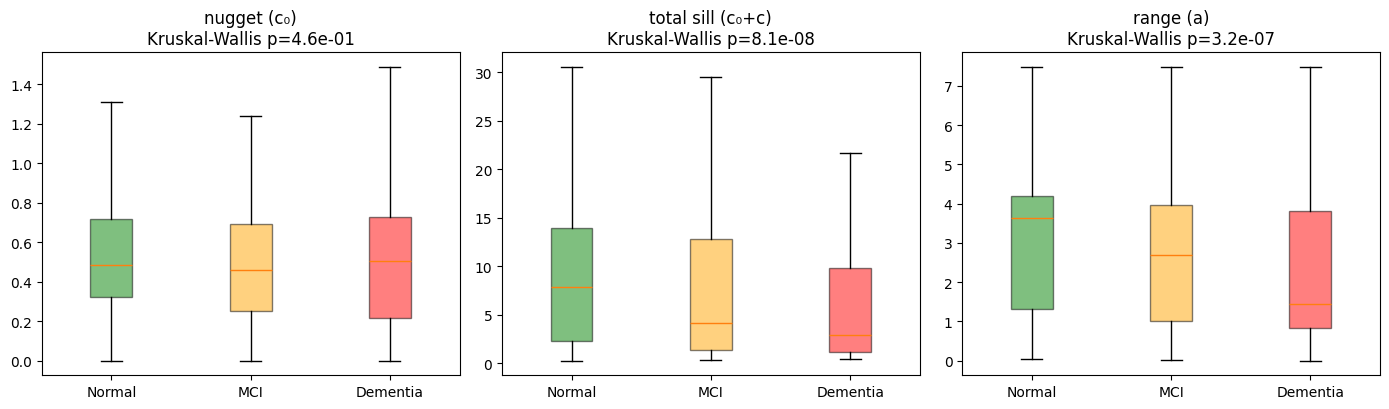

In [ ]:
# --- Boxplots of the 3 parameters by group ---
fig, axes = plt.subplots(1, 3, figsize=(14,4.2))
for ax, (key, label) in zip(axes, PARAM_LABELS.items()):
    data = [param_arrays(subject_fits[g], key) for g in [0,1,2]]
    bp = ax.boxplot(data, tick_labels=[GROUP_NAMES[g] for g in [0,1,2]], showfliers=False, patch_artist=True)
    for patch, g in zip(bp['boxes'], [0,1,2]):
        patch.set_facecolor(COLG[g]); patch.set_alpha(.5)
    H, p = kw_results[key]
    ax.set_title(f"{label}\nKruskal-Wallis p={p:.1e}")
plt.tight_layout(); plt.savefig("boxplots_variogram_parameters.png", dpi=150, bbox_inches="tight"); plt.show()

### 15.1 Age as a potential confound (nugget, sill, range)


In [ ]:
# ============================================================================
# AGE DISTRIBUTION ACROSS CLINICAL GROUPS
#
# This section examines the age distribution across the three clinical groups
# (Normal, MCI, Dementia).
#
# NOTE: This is based on the raw age data, independent of any downstream
# residualization method used in the functional analysis (age adjustment is
# applied later, not here).
# ============================================================================

age_arrays = [np.array([a for a in AGES[g] if a is not None], dtype=float) for g in [0,1,2]]
if any(len(a) == 0 for a in age_arrays):
    print("Age not available for one or more groups -- skipping the age-adjustment analysis.")
else:
    print("=== Age distribution by group ===")
    for g, arr in zip([0,1,2], age_arrays):
        print(f"  {GROUP_NAMES[g]:9s}: n={len(arr):3d}  mean={arr.mean():5.1f}  sd={arr.std():4.1f}  median={np.median(arr):5.1f}")
    H_age, p_age = kruskal(*age_arrays)
    print(f"Kruskal-Wallis on age across groups: H={H_age:.2f}  p={p_age:.2e}"
          + ("  -> groups differ significantly in age: treat diagnosis effects below with caution"
             if p_age < 0.05 else "  -> no significant age difference across groups here"))

# --- AGE-ADJUSTED COMPARISON: FUNCTIONAL RESIDUALIZATION METHOD (SECTION 5.1) ---
#
# This section repeats the subject-level variogram fitting using the age-residualized
# functional data (coefs_age_adj), where age effects were removed at the PSD-coefficient
# level prior to any variogram computation (see Section 5.1 for details).
#
# KEY DISTINCTION FROM SCALAR CORRECTION:
#   - The variogram is REFIT FROM SCRATCH on the age-adjusted functional data
#   - Nugget, sill, and range are natively age-adjusted by construction
#   - This differs from a simple post-hoc scalar correction applied directly
#     to the parameter estimates (nugget/sill/range) after variogram fitting
#
# All downstream analyses (statistical comparisons, tables, figures) are then
# repeated on these age-adjusted parameter distributions.

    print("\nFitting subject-level variograms on age-adjusted functional data (may take a moment)...")
    subject_fits_age_adj = {g: [fit_subject(Z, W, DIST) for Z in coefs_age_adj[g]] for g in [0,1,2]}
    for g in [0,1,2]:
        n_ok = sum(f is not None for f in subject_fits_age_adj[g])
        print(f"  {GROUP_NAMES[g]:9s}: {n_ok}/{len(subject_fits_age_adj[g])} subjects with a valid fit (age-adjusted)")

    print("\n=== nugget/sill/range: raw vs. age-adjusted group comparison (Kruskal-Wallis) ===")
    for key, label in PARAM_LABELS.items():
        adj_vals = [param_arrays(subject_fits_age_adj[g], key) for g in [0,1,2]]
        H, p = kruskal(*adj_vals)
        H0, p0 = kw_results[key]
        flag = "  <- weakens after age adjustment" if (p0 < 0.05 <= p) else ""
        print(f"{label:24s} raw: H={H0:7.2f} p={p0:.2e}   |   age-adjusted: H={H:7.2f} p={p:.2e}{flag}")


=== Age distribution by group ===
  Normal   : n=394  mean= 64.7  sd= 9.4  median= 64.0
  MCI      : n=329  mean= 73.7  sd= 7.8  median= 75.0
  Dementia : n=247  mean= 76.5  sd= 8.4  median= 78.0
Kruskal-Wallis on age across groups: H=253.28  p=1.00e-55  -> groups differ significantly in age: treat diagnosis effects below with caution

Fitting subject-level variograms on age-adjusted functional data (may take a moment)...
  Normal   : 394/394 subjects with a valid fit (age-adjusted)
  MCI      : 329/329 subjects with a valid fit (age-adjusted)
  Dementia : 247/247 subjects with a valid fit (age-adjusted)

=== nugget/sill/range: raw vs. age-adjusted group comparison (Kruskal-Wallis) ===
nugget (c₀)              raw: H=   1.55 p=4.60e-01   |   age-adjusted: H=   0.93 p=6.28e-01
total sill (c₀+c)        raw: H=  32.65 p=8.15e-08   |   age-adjusted: H=  25.96 p=2.31e-06
range (a)                raw: H=  29.91 p=3.20e-07   |   age-adjusted: H=  18.04 p=1.21e-04


### 15.2 Statistical comparison of nugget, sill, and range — Wasserstein metric

=== Comparison across the 3 clinical groups (Kruskal-Wallis) -- Wasserstein metric ===
nugget (c₀)              H=  14.46  p=7.24e-04   medians: Normal=0.7  MCI=0.5  Dementia=0.4
total sill (c₀+c)        H=  24.78  p=4.17e-06   medians: Normal=2.4  MCI=2.0  Dementia=1.8
range (a)                H=   4.34  p=1.14e-01   medians: Normal=1.0  MCI=0.9  Dementia=0.8

=== Pairwise post-hoc tests (Mann-Whitney U, FDR-corrected) -- Wasserstein metric ===
Parameter                Comparison                    p    q (FDR)
nugget (c₀)              Normal vs MCI            0.0062     0.0093*
nugget (c₀)              MCI vs Dementia          0.3601     0.3601 
nugget (c₀)              Normal vs Dementia       0.0004     0.0011*
total sill (c₀+c)        Normal vs MCI            0.0002     0.0003*
total sill (c₀+c)        MCI vs Dementia          0.3372     0.3372 
total sill (c₀+c)        Normal vs Dementia       0.0000     0.0000*
range (a)                Normal vs MCI            0.5937     0.5937 

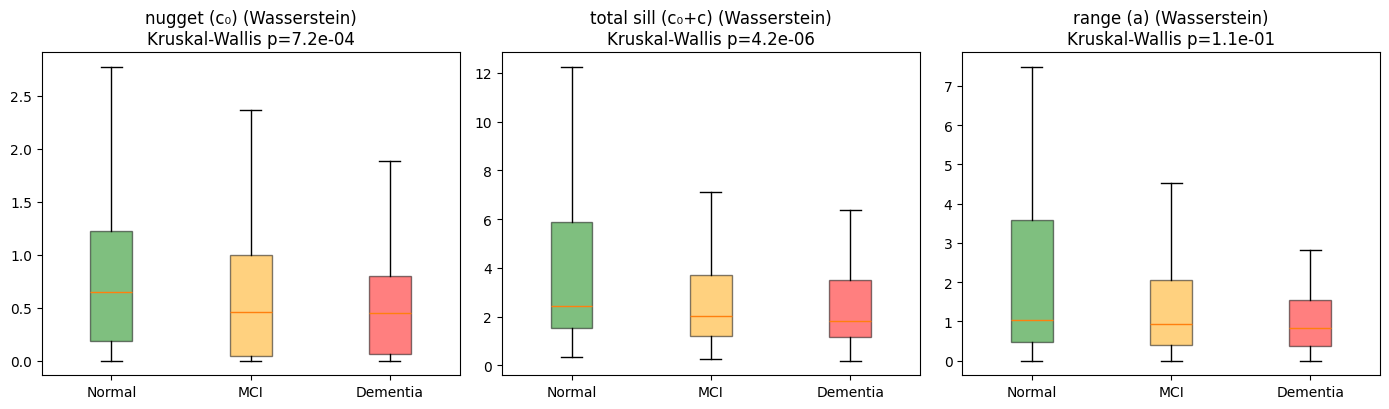

In [ ]:
print("=== Comparison across the 3 clinical groups (Kruskal-Wallis) -- Wasserstein metric ===")
kw_results_qf = {}
for key, label in PARAM_LABELS.items():
    arrs = [param_arrays(subject_fits_qf[g], key) for g in [0,1,2]]
    H, p = kruskal(*arrs)
    kw_results_qf[key] = (H, p)
    meds = [np.median(a) for a in arrs]
    print(f"{label:24s} H={H:7.2f}  p={p:.2e}   medians: Normal={meds[0]:.1f}  MCI={meds[1]:.1f}  Dementia={meds[2]:.1f}")

print("\n=== Pairwise post-hoc tests (Mann-Whitney U, FDR-corrected) -- Wasserstein metric ===")
posthoc_rows_qf = []
for key, label in PARAM_LABELS.items():
    pvals = []
    for g1, g2, name in pairs:
        a1 = param_arrays(subject_fits_qf[g1], key); a2 = param_arrays(subject_fits_qf[g2], key)
        _, p = mannwhitneyu(a1, a2, alternative="two-sided")
        pvals.append(p)
    qvals = bh_fdr(pvals)
    for (g1, g2, name), p, q in zip(pairs, pvals, qvals):
        posthoc_rows_qf.append((label, name, p, q))

print(f"{'Parameter':24s} {'Comparison':20s} {'p':>10s} {'q (FDR)':>10s}")
for label, name, p, q in posthoc_rows_qf:
    sig = "*" if q < 0.05 else " "
    print(f"{label:24s} {name:20s} {p:10.4f} {q:10.4f}{sig}")

print("\n=== Normal vs. Abnormal (MCI+Dementia), Mann-Whitney U -- Wasserstein metric ===")
fits_bin_qf = {"Normal": subject_fits_qf[0], "Abnormal": subject_fits_qf[1] + subject_fits_qf[2]}
for key, label in PARAM_LABELS.items():
    aN = param_arrays(fits_bin_qf["Normal"], key); aA = param_arrays(fits_bin_qf["Abnormal"], key)
    _, p = mannwhitneyu(aN, aA, alternative="two-sided")
    print(f"{label:24s} p={p:.2e}   median Normal={np.median(aN):.1f}   median Abnormal={np.median(aA):.1f}")

fig, axes = plt.subplots(1, 3, figsize=(14,4.2))
for ax, (key, label) in zip(axes, PARAM_LABELS.items()):
    data = [param_arrays(subject_fits_qf[g], key) for g in [0,1,2]]
    bp = ax.boxplot(data, tick_labels=[GROUP_NAMES[g] for g in [0,1,2]], showfliers=False, patch_artist=True)
    for patch, g in zip(bp['boxes'], [0,1,2]):
        patch.set_facecolor(COLG[g]); patch.set_alpha(.5)
    H, p = kw_results_qf[key]
    ax.set_title(f"{label} (Wasserstein)\nKruskal-Wallis p={p:.1e}")
plt.tight_layout(); plt.savefig("boxplots_variogram_parameters_wasserstein.png", dpi=150, bbox_inches="tight"); plt.show()


### 15.3 Direct comparison: Euclidean (Gram/L2) vs. Wasserstein parameter estimates

In [ ]:
print("=== Group-level significance (Kruskal-Wallis across the 3 groups): Euclidean vs. Wasserstein ===")
print(f"{'Parameter':24s} {'p (Euclidean)':>14s} {'p (Wasserstein)':>16s} {'Same conclusion (alpha=0.05)?':>30s}")
for key, label in PARAM_LABELS.items():
    _, pE = kw_results[key]; _, pW = kw_results_qf[key]
    same = "yes" if (pE < 0.05) == (pW < 0.05) else "no"
    print(f"{label:24s} {pE:14.2e} {pW:16.2e} {same:>30s}")

print("\n=== Do the two metrics agree at the SUBJECT level? (Spearman correlation of best-fit parameters) ===")
print(f"{'Parameter':24s} {'rho (pooled, all 3 groups)':>28s} {'p':>10s}")
for key, label in PARAM_LABELS.items():
    # align subjects that have a VALID fit under BOTH metrics, preserving order
    vE, vW = [], []
    for g in [0,1,2]:
        for fE, fW in zip(subject_fits[g], subject_fits_qf[g]):
            if fE is not None and fW is not None:
                vE.append(fE[f"best_{key}"]); vW.append(fW[f"best_{key}"])
    rho, p = spearmanr(vE, vW)
    print(f"{label:24s} {rho:28.3f} {p:10.2e}")

print("\nInterpretation: a high positive rho means subjects the Gram/L2 metric calls "
      "\'spatially decorrelated\' (high sill / short range) tend to also be called that way "
      "by the Wasserstein metric -- i.e. the two notions of dissimilarity are picking out "
      "similar subjects, even though their raw units differ (log10-power^2 vs. Hz^2). A low "
      "or non-significant rho would mean the two metrics are capturing genuinely different "
      "aspects of spectral (dis)similarity across the scalp.")


=== Group-level significance (Kruskal-Wallis across the 3 groups): Euclidean vs. Wasserstein ===
Parameter                 p (Euclidean)  p (Wasserstein)  Same conclusion (alpha=0.05)?
nugget (c₀)                    4.60e-01         7.24e-04                             no
total sill (c₀+c)              8.15e-08         4.17e-06                            yes
range (a)                      3.20e-07         1.14e-01                             no

=== Do the two metrics agree at the SUBJECT level? (Spearman correlation of best-fit parameters) ===
Parameter                  rho (pooled, all 3 groups)          p
nugget (c₀)                                     0.254   1.03e-15
total sill (c₀+c)                               0.228   6.37e-13
range (a)                                       0.105   1.11e-03

Interpretation: a high positive rho means subjects the Gram/L2 metric calls 'spatially decorrelated' (high sill / short range) tend to also be called that way by the Wasserstein metric -- 

## 16. Which model fits best? (Friedman test)

In [ ]:
# ============================================================================
# VARIOGRAM MODEL SELECTION: COMPARISON ACROSS CANDIDATE MODELS
#
# For each subject, the 5 candidate variogram models (Exponential, Spherical,
# Gaussian, Matérn ν=1.5, Matérn ν=2.5) are fitted and their RMSE values
# compared to determine which model provides the best fit.
#
# ANALYSES PERFORMED:
#   1. Friedman test (nonparametric, repeated measures):
#      - Each subject is a block
#      - Each model is a "condition"
#      - Tests whether model performance (RMSE) differs significantly across models
#
#   2. Best-fit frequency:
#      - For each subject, the model with lowest RMSE is identified
#      - The proportion of subjects for which each model is selected as best
#        is reported, within each clinical group
#
# This provides insight into which variogram model best characterizes the
# spatial dependence structure of EEG functional data, and whether the
# preferred model varies across clinical groups.
# ============================================================================

from scipy.stats import friedmanchisquare

model_names = list(MODELS.keys())

def rmse_matrix(group_fits):
    rows = []
    for f in group_fits:
        if f is None:
            continue
        if all(f["models"].get(m) is not None for m in model_names):
            rows.append([f["models"][m]["rmse"] for m in model_names])
    return np.array(rows)

print("=== Friedman test (RMSE of the 5 models, by group) ===")
for g in [0,1,2]:
    M = rmse_matrix(subject_fits[g])
    if len(M) < 3:
        print(f"  {GROUP_NAMES[g]}: insufficient sample"); continue
    stat, p = friedmanchisquare(*[M[:,j] for j in range(M.shape[1])])
    print(f"  {GROUP_NAMES[g]:9s} (n={len(M)}): chi2={stat:8.2f}  p={p:.2e}   "
          f"mean RMSE: " + ", ".join(f"{m}={M[:,j].mean():.1f}" for j, m in enumerate(model_names)))

print("\n=== Frequency of the best-fitting model per subject (%) ===")
print(f"{'Group':10s} " + " ".join(f"{m:>13s}" for m in model_names))
for g in [0,1,2]:
    valid = [f for f in subject_fits[g] if f is not None]
    counts = {m: 0 for m in model_names}
    for f in valid: counts[f["best"]] += 1
    pct = [100*counts[m]/max(len(valid),1) for m in model_names]
    print(f"{GROUP_NAMES[g]:10s} " + " ".join(f"{v:12.1f}%" for v in pct))

=== Friedman test (RMSE of the 5 models, by group) ===
  Normal    (n=394): chi2=  831.67  p=1.06e-178   mean RMSE: exponential=0.3, spherical=0.3, gaussian=0.2, matern_nu1.5=0.2, matern_nu2.5=0.2
  MCI       (n=329): chi2=  510.10  p=4.39e-109   mean RMSE: exponential=0.2, spherical=0.2, gaussian=0.2, matern_nu1.5=0.2, matern_nu2.5=0.2
  Dementia  (n=247): chi2=  342.31  p=8.01e-73   mean RMSE: exponential=0.2, spherical=0.2, gaussian=0.2, matern_nu1.5=0.2, matern_nu2.5=0.2

=== Frequency of the best-fitting model per subject (%) ===
Group        exponential     spherical      gaussian  matern_nu1.5  matern_nu2.5
Normal              3.3%         21.1%         67.0%          5.3%          3.3%
MCI                 7.3%         26.1%         55.9%          6.4%          4.3%
Dementia            8.1%         29.1%         53.8%          4.9%          4.0%


### 16.1 Which model fits best? — Wasserstein metric (Friedman test)

In [ ]:
print("=== Friedman test (RMSE of the 5 models, by group) -- Wasserstein metric ===")
for g in [0,1,2]:
    M = rmse_matrix(subject_fits_qf[g])
    if len(M) < 3:
        print(f"  {GROUP_NAMES[g]}: insufficient sample"); continue
    stat, p = friedmanchisquare(*[M[:,j] for j in range(M.shape[1])])
    print(f"  {GROUP_NAMES[g]:9s} (n={len(M)}): chi2={stat:8.2f}  p={p:.2e}   "
          f"mean RMSE: " + ", ".join(f"{m}={M[:,j].mean():.1f}" for j, m in enumerate(model_names)))

print("\n=== Frequency of the best-fitting model per subject (%) -- Wasserstein metric ===")
print(f"{'Group':10s} " + " ".join(f"{m:>13s}" for m in model_names))
for g in [0,1,2]:
    valid = [f for f in subject_fits_qf[g] if f is not None]
    counts = {m: 0 for m in model_names}
    for f in valid: counts[f["best"]] += 1
    pct = [100*counts[m]/max(len(valid),1) for m in model_names]
    print(f"{GROUP_NAMES[g]:10s} " + " ".join(f"{v:12.1f}%" for v in pct))


=== Friedman test (RMSE of the 5 models, by group) -- Wasserstein metric ===
  Normal    (n=394): chi2=  402.71  p=7.21e-86   mean RMSE: exponential=0.3, spherical=0.3, gaussian=0.3, matern_nu1.5=0.3, matern_nu2.5=0.3
  MCI       (n=329): chi2=  258.15  p=1.14e-54   mean RMSE: exponential=0.3, spherical=0.3, gaussian=0.3, matern_nu1.5=0.3, matern_nu2.5=0.3
  Dementia  (n=247): chi2=  235.64  p=8.04e-50   mean RMSE: exponential=0.3, spherical=0.3, gaussian=0.3, matern_nu1.5=0.3, matern_nu2.5=0.3

=== Frequency of the best-fitting model per subject (%) -- Wasserstein metric ===
Group        exponential     spherical      gaussian  matern_nu1.5  matern_nu2.5
Normal             10.2%         42.9%         38.8%          4.6%          3.6%
MCI                11.9%         42.9%         35.0%          5.2%          5.2%
Dementia            9.3%         46.2%         34.8%          4.0%          5.7%


## 17. Functional semivariance per channel, per subject

In [ ]:
# ============================================================================
# PER-ELECTRODE STATISTICAL TESTING: SUBJECT-LEVEL SEMIVARIANCE
#
# The topomaps in Sections 12-13 were built by averaging the per-channel semivariance
# over all subjects within each clinical group (group-level average).
#
# For formal statistical testing at the electrode level, we require PER-SUBJECT
# values (not just group averages) to enable group comparisons with appropriate
# variance estimates.
#
# IMPLEMENTATION:
#   The per-channel semivariance is recomputed as an array of shape:
#     [n_subjects_per_group, 19 channels]
#
#   This allows statistical tests (e.g., Kruskal-Wallis, Mann-Whitney) to be
#   performed at each electrode independently, comparing the distribution of
#   semivariance values across clinical groups.
# ============================================================================

def channel_semivariance_subject(Z, W):
    """Functional semivariance per channel for ONE subject. Z: coef [19, n_basis] -> [19]"""
    Q = np.einsum('ik,kl,il->i', Z, W, Z)
    Cross = Z @ W @ Z.T
    D2 = np.clip(Q[:,None] + Q[None,:] - 2*Cross, 0, None)
    np.fill_diagonal(D2, 0.0)
    return 0.5*D2.sum(1)/(N_CH-1)

sv_subject = {g: np.stack([channel_semivariance_subject(Z, W) for Z in coefs[g]]) for g in [0,1,2]}
for g in [0,1,2]:
    print(f"  {GROUP_NAMES[g]:9s}: {sv_subject[g].shape}  (subjects x channels)")

sv_subject_bin = {"Normal": sv_subject[0], "Abnormal": np.concatenate([sv_subject[1], sv_subject[2]], axis=0)}

  Normal   : (394, 19)  (subjects x channels)
  MCI      : (329, 19)  (subjects x channels)
  Dementia : (247, 19)  (subjects x channels)


### 17.1 Functional semivariance per channel, per subject — Wasserstein metric

In [ ]:
sv_subject_qf = {g: np.stack([channel_semivariance_subject(Z, WQ) for Z in coefs_qf[g]]) for g in [0,1,2]}
for g in [0,1,2]:
    print(f"  {GROUP_NAMES[g]:9s}: {sv_subject_qf[g].shape}  (subjects x channels, Wasserstein)")

sv_subject_bin_qf = {"Normal": sv_subject_qf[0], "Abnormal": np.concatenate([sv_subject_qf[1], sv_subject_qf[2]], axis=0)}


  Normal   : (394, 19)  (subjects x channels, Wasserstein)
  MCI      : (329, 19)  (subjects x channels, Wasserstein)
  Dementia : (247, 19)  (subjects x channels, Wasserstein)


## 18. Electrode-level statistical tests (with FDR correction)

In [ ]:
# ============================================================================
# PER-ELECTRODE STATISTICAL TESTS ON FUNCTIONAL SEMIVARIANCE
#
# For each of the 19 electrodes, statistical tests are performed on the
# per-subject functional semivariance values computed in the previous section.
#
# ANALYSES PERFORMED:
#   1. Kruskal-Wallis test: compares semivariance distributions across the
#      3 clinical groups (Normal, MCI, Dementia) at each electrode
#
#   2. Mann-Whitney U test: compares Normal vs. Abnormal (MCI + Dementia pooled)
#      at each electrode
#
# MULTIPLE COMPARISON CORRECTION:
#   Since 19 simultaneous tests are conducted (one per electrode), p-values
#   are corrected using Benjamini-Hochberg False Discovery Rate (FDR) control.
#
# This identifies electrodes showing significant differences in spatial
# functional variability across diagnostic groups.
# ============================================================================

# --- (a) Kruskal-Wallis per channel, 3 groups ---
p_kw_channel = np.array([
    kruskal(sv_subject[0][:,c], sv_subject[1][:,c], sv_subject[2][:,c])[1]
    for c in range(N_CH)
])
q_kw_channel = bh_fdr(p_kw_channel)

# --- (b) Mann-Whitney U per channel, Normal vs Abnormal ---
p_mw_channel = np.array([
    mannwhitneyu(sv_subject_bin["Normal"][:,c], sv_subject_bin["Abnormal"][:,c], alternative="two-sided")[1]
    for c in range(N_CH)
])
q_mw_channel = bh_fdr(p_mw_channel)

print(f"{'Channel':6s} {'p KW (3 grp)':>13s} {'q KW':>8s} {'p MW (N vs A)':>14s} {'q MW':>8s}")
for c, ch in enumerate(CANONICAL):
    sig_kw = "*" if q_kw_channel[c] < 0.05 else " "
    sig_mw = "*" if q_mw_channel[c] < 0.05 else " "
    print(f"{ch:6s} {p_kw_channel[c]:13.4f} {q_kw_channel[c]:7.4f}{sig_kw} {p_mw_channel[c]:14.4f} {q_mw_channel[c]:7.4f}{sig_mw}")

n_sig_kw = int((q_kw_channel < 0.05).sum()); n_sig_mw = int((q_mw_channel < 0.05).sum())
print(f"\nChannels significant after FDR (q<0.05): KW(3 groups)={n_sig_kw}/19   MW(Normal vs Abnormal)={n_sig_mw}/19")

Channel  p KW (3 grp)     q KW  p MW (N vs A)     q MW
Fp1           0.0613  0.2330          0.0261  0.0991 
Fp2           0.8637  0.8637          0.5949  0.7423 
F7            0.6733  0.7995          0.8716  0.9100 
F3            0.1684  0.4000          0.0597  0.1891 
FZ            0.6148  0.7856          0.3455  0.7423 
F4            0.7339  0.8203          0.4803  0.7423 
F8            0.6028  0.7856          0.4920  0.7423 
T3            0.2956  0.4680          0.6642  0.7423 
C3            0.8250  0.8637          0.5766  0.7423 
CZ            0.2435  0.4680          0.3058  0.7423 
C4            0.6202  0.7856          0.6243  0.7423 
T4            0.0873  0.2765          0.6396  0.7423 
T5            0.0378  0.1798          0.0127  0.0604 
P3            0.2565  0.4680          0.6206  0.7423 
PZ            0.1115  0.3026          0.9100  0.9100 
P4            0.2742  0.4680          0.4742  0.7423 
T6            0.0030  0.0190*         0.0009  0.0055*
O1            0.0026  0.019

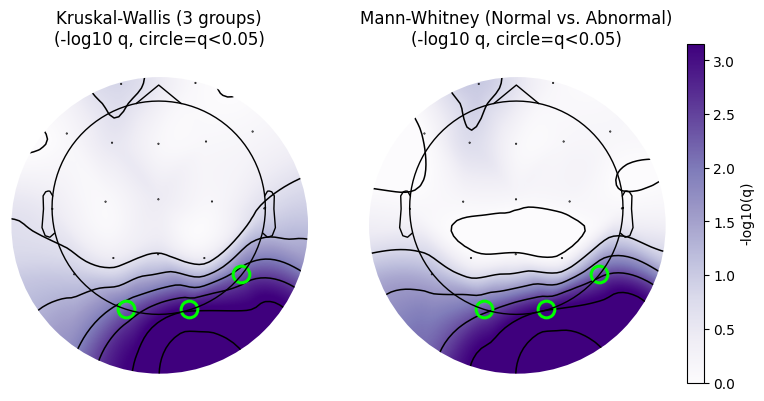

In [ ]:
# --- Topomap of -log10(q) per channel, marking the significant electrodes ---
# (mask now drawn by MNE's own mask_params inside plot_topomap, instead of a manual
# ax.scatter overlay -- one less place for a plotting artifact to creep in.)
def plot_topomap_sig(qvals, ax, title, cmap="Purples"):
    vals = -np.log10(np.clip(qvals, 1e-12, 1))
    vlim = (0, max(vals.max(), 1.5))
    mask = qvals < 0.05
    cf = plot_topomap(vals, ax, title, vlim, cmap=cmap, mask=mask)
    return cf

fig, ax = plt.subplots(1, 2, figsize=(9,4.4))
cf1 = plot_topomap_sig(q_kw_channel, ax[0], "Kruskal-Wallis (3 groups)\n(-log10 q, circle=q<0.05)")
cf2 = plot_topomap_sig(q_mw_channel, ax[1], "Mann-Whitney (Normal vs. Abnormal)\n(-log10 q, circle=q<0.05)")
fig.colorbar(cf2, ax=ax, fraction=0.03, pad=0.03, label="-log10(q)")
plt.savefig("topomap_fdr_significance.png", dpi=150, bbox_inches="tight"); plt.show()

### 18.1 Age as a potential confound (electrode-level)


In [ ]:
# ============================================================================
# AGE-ADJUSTED PER-ELECTRODE TESTS: FUNCTIONAL RESIDUALIZATION METHOD (SECTION 5.1)
#
# This section repeats the per-electrode statistical tests (previous section)
# using the age-residualized functional data.
#
# IMPLEMENTATION:
#   - Per-subject, per-channel functional semivariance is recomputed directly
#     from coefs_age_adj (age-residualized at the PSD-coefficient level)
#   - This contrasts with scalar-residualizing the raw semivariance values
#     per channel using a pooled linear trend (post-hoc correction)
#
# KEY ADVANTAGE:
#   The variogram is refit from scratch on age-adjusted functional data,
#   so the semivariance values themselves are natively age-adjusted by
#   construction, rather than corrected after the fact.
#
# All statistical tests (Kruskal-Wallis across groups, Mann-Whitney Normal vs.
# Abnormal) are then repeated on these age-adjusted semivariance values.
# ============================================================================

ages_sv = [np.array([a if a is not None else np.nan for a in AGES[g]], dtype=float) for g in [0,1,2]]
if any(len(a) == 0 or np.all(~np.isfinite(a)) for a in ages_sv):
    print("Age not available for one or more groups -- skipping age-adjusted electrode-level tests.")
else:
    sv_subject_adj = {g: np.stack([channel_semivariance_subject(Z, W) for Z in coefs_age_adj[g]]) for g in [0,1,2]}

    sv_subject_bin_adj = {"Normal": sv_subject_adj[0],
                           "Abnormal": np.concatenate([sv_subject_adj[1], sv_subject_adj[2]], axis=0)}

    p_kw_channel_adj = np.array([
        kruskal(sv_subject_adj[0][:, c], sv_subject_adj[1][:, c], sv_subject_adj[2][:, c])[1]
        for c in range(N_CH)
    ])
    q_kw_channel_adj = bh_fdr(p_kw_channel_adj)

    p_mw_channel_adj = np.array([
        mannwhitneyu(sv_subject_bin_adj["Normal"][:, c], sv_subject_bin_adj["Abnormal"][:, c], alternative="two-sided")[1]
        for c in range(N_CH)
    ])
    q_mw_channel_adj = bh_fdr(p_mw_channel_adj)

    n_sig_kw_adj = int((q_kw_channel_adj < 0.05).sum()); n_sig_mw_adj = int((q_mw_channel_adj < 0.05).sum())
    print("=== Channels significant after FDR (q<0.05): raw vs. age-adjusted (functional method) ===")
    print(f"  Raw:          KW(3 groups)={n_sig_kw}/19   MW(Normal vs Abnormal)={n_sig_mw}/19")
    print(f"  Age-adjusted: KW(3 groups)={n_sig_kw_adj}/19   MW(Normal vs Abnormal)={n_sig_mw_adj}/19")
    if n_sig_kw_adj < n_sig_kw or n_sig_mw_adj < n_sig_mw:
        print("  -> Some channel-level effects weaken after age adjustment: interpret with some caution, "
              "age may be a partial confound for those channels.")
    else:
        print("  -> Channel-level effects are stable after age adjustment.")


=== Channels significant after FDR (q<0.05): raw vs. age-adjusted (functional method) ===
  Raw:          KW(3 groups)=3/19   MW(Normal vs Abnormal)=3/19
  Age-adjusted: KW(3 groups)=1/19   MW(Normal vs Abnormal)=3/19
  -> Some channel-level effects weaken after age adjustment: interpret with some caution, age may be a partial confound for those channels.


### 18.2 Electrode-level statistical tests — Wasserstein metric

Channel  p KW (3 grp)     q KW  p MW (N vs A)     q MW   (Wasserstein)
Fp1           0.0000  0.0000*         0.0000  0.0000*
Fp2           0.0000  0.0000*         0.0000  0.0000*
F7            0.0000  0.0000*         0.0002  0.0002*
F3            0.0010  0.0012*         0.0003  0.0004*
FZ            0.0000  0.0000*         0.0000  0.0000*
F4            0.0001  0.0001*         0.0001  0.0001*
F8            0.0000  0.0000*         0.0000  0.0000*
T3            0.1427  0.1427          0.0493  0.0493*
C3            0.0000  0.0001*         0.0000  0.0000*
CZ            0.0044  0.0050*         0.0028  0.0031*
C4            0.0000  0.0000*         0.0000  0.0000*
T4            0.0009  0.0012*         0.0004  0.0004*
T5            0.0000  0.0000*         0.0000  0.0000*
P3            0.0000  0.0000*         0.0000  0.0000*
PZ            0.0232  0.0245*         0.0061  0.0064*
P4            0.0000  0.0000*         0.0000  0.0000*
T6            0.0000  0.0000*         0.0000  0.0000*
O1         

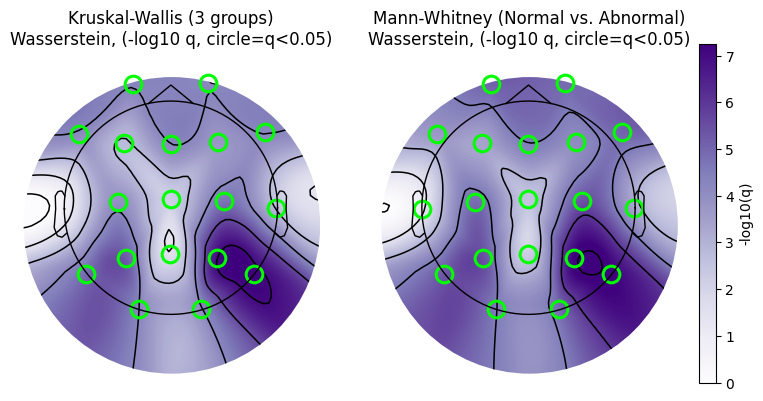

In [ ]:
p_kw_channel_qf = np.array([
    kruskal(sv_subject_qf[0][:,c], sv_subject_qf[1][:,c], sv_subject_qf[2][:,c])[1]
    for c in range(N_CH)
])
q_kw_channel_qf = bh_fdr(p_kw_channel_qf)

p_mw_channel_qf = np.array([
    mannwhitneyu(sv_subject_bin_qf["Normal"][:,c], sv_subject_bin_qf["Abnormal"][:,c], alternative="two-sided")[1]
    for c in range(N_CH)
])
q_mw_channel_qf = bh_fdr(p_mw_channel_qf)

print(f"{'Channel':6s} {'p KW (3 grp)':>13s} {'q KW':>8s} {'p MW (N vs A)':>14s} {'q MW':>8s}   (Wasserstein)")
for c, ch in enumerate(CANONICAL):
    sig_kw = "*" if q_kw_channel_qf[c] < 0.05 else " "
    sig_mw = "*" if q_mw_channel_qf[c] < 0.05 else " "
    print(f"{ch:6s} {p_kw_channel_qf[c]:13.4f} {q_kw_channel_qf[c]:7.4f}{sig_kw} {p_mw_channel_qf[c]:14.4f} {q_mw_channel_qf[c]:7.4f}{sig_mw}")

n_sig_kw_qf = int((q_kw_channel_qf < 0.05).sum()); n_sig_mw_qf = int((q_mw_channel_qf < 0.05).sum())
print(f"\nChannels significant after FDR (q<0.05), Wasserstein: KW(3 groups)={n_sig_kw_qf}/19   MW(Normal vs Abnormal)={n_sig_mw_qf}/19")

fig, ax = plt.subplots(1, 2, figsize=(9,4.4))
cf1 = plot_topomap_sig(q_kw_channel_qf, ax[0], "Kruskal-Wallis (3 groups)\nWasserstein, (-log10 q, circle=q<0.05)")
cf2 = plot_topomap_sig(q_mw_channel_qf, ax[1], "Mann-Whitney (Normal vs. Abnormal)\nWasserstein, (-log10 q, circle=q<0.05)")
fig.colorbar(cf2, ax=ax, fraction=0.03, pad=0.03, label="-log10(q)")
plt.savefig("topomap_fdr_significance_wasserstein.png", dpi=150, bbox_inches="tight"); plt.show()


### 18.3 Electrode-level agreement: Euclidean vs. Wasserstein

In [ ]:
print("=== Which channels are significant (q<0.05) under EACH metric? ===")
print(f"{'Channel':6s} {'KW Euclidean':>13s} {'KW Wasserstein':>15s} {'MW Euclidean':>13s} {'MW Wasserstein':>15s}")
for c, ch in enumerate(CANONICAL):
    e_kw = "*" if q_kw_channel[c] < 0.05 else "."
    w_kw = "*" if q_kw_channel_qf[c] < 0.05 else "."
    e_mw = "*" if q_mw_channel[c] < 0.05 else "."
    w_mw = "*" if q_mw_channel_qf[c] < 0.05 else "."
    print(f"{ch:6s} {e_kw:>13s} {w_kw:>15s} {e_mw:>13s} {w_mw:>15s}")

kw_agree = int(((q_kw_channel<0.05) == (q_kw_channel_qf<0.05)).sum())
mw_agree = int(((q_mw_channel<0.05) == (q_mw_channel_qf<0.05)).sum())
print(f"\nAgreement on significance (q<0.05) across metrics: KW {kw_agree}/19 channels, MW {mw_agree}/19 channels.")
rho_kw, _ = spearmanr(-np.log10(np.clip(q_kw_channel,1e-12,1)), -np.log10(np.clip(q_kw_channel_qf,1e-12,1)))
rho_mw, _ = spearmanr(-np.log10(np.clip(q_mw_channel,1e-12,1)), -np.log10(np.clip(q_mw_channel_qf,1e-12,1)))
print(f"Spearman rho between -log10(q) across the 19 channels: KW={rho_kw:.3f}, MW={rho_mw:.3f} "
      "(rho close to 1 means both metrics rank electrodes similarly by strength of evidence, "
      "even if the exact q-values/significant set differ).")


=== Which channels are significant (q<0.05) under EACH metric? ===
Channel  KW Euclidean  KW Wasserstein  MW Euclidean  MW Wasserstein
Fp1                .               *             .               *
Fp2                .               *             .               *
F7                 .               *             .               *
F3                 .               *             .               *
FZ                 .               *             .               *
F4                 .               *             .               *
F8                 .               *             .               *
T3                 .               .             .               *
C3                 .               *             .               *
CZ                 .               *             .               *
C4                 .               *             .               *
T4                 .               *             .               *
T5                 .               *             .           

## 19. Cluster-based permutation test (Maris & Oostenveld, 2007)

Neighbors per electrode (Delaunay): {'Fp1': 4, 'Fp2': 4, 'F7': 4, 'F3': 5, 'FZ': 5, 'F4': 5, 'F8': 4, 'T3': 4, 'C3': 5, 'CZ': 8, 'C4': 5, 'T4': 4, 'T5': 3, 'P3': 6, 'PZ': 5, 'P4': 6, 'T6': 3, 'O1': 4, 'O2': 4}


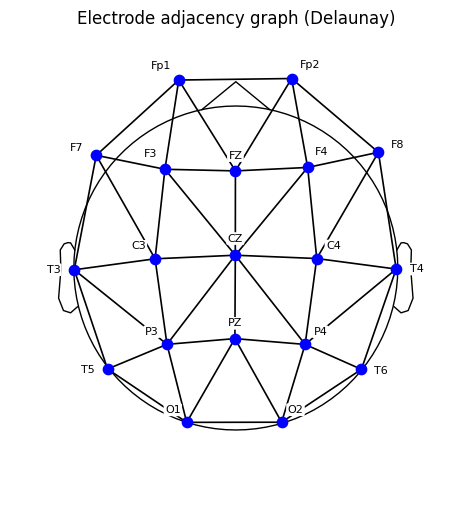

In [ ]:
# ============================================================================
# CLUSTER-BASED PERMUTATION TESTING (SPATIAL MULTIPLE COMPARISON CORRECTION)
#
# The FDR correction in Section 18 treats each channel as independent, which is
# conservative because it ignores spatial correlation between neighboring
# electrodes — a "smooth" topomap (as seen in Sections 12-13) has, by construction,
# similar values between nearby channels.
#
# RATIONALE FOR CLUSTER-BASED APPROACH:
# The cluster-based permutation test exploits spatial structure by:
#   1. Grouping neighboring channels whose test statistic exceeds a threshold
#      into "clusters"
#   2. Testing the significance of the CLUSTER MASS (not each channel separately)
#   3. Generating a null distribution by permuting group labels thousands of times
#
# REFERENCE:
# This is the de facto standard in neuroscience for declaring an EEG/MEG topographic
# difference robust:
#   Maris, E.; Oostenveld, R. (2007). "Nonparametric statistical testing of
#   EEG- and MEG-data." J. Neurosci. Methods, 164, 177-190.
#
# This approach controls the family-wise error rate while accounting for the
# spatial smoothness of the data, providing greater sensitivity than channel-wise
# correction methods.
# ============================================================================


from scipy.spatial import Delaunay

# ============================================================================
# ELECTRODE ADJACENCY GRAPH (DELAUNAY TRIANGULATION)
#
# This section constructs the spatial adjacency graph between electrodes using
# Delaunay triangulation based on the 2D electrode positions.
#
# USAGE:
#   The resulting adjacency matrix (ADJACENCY) is used in the cluster-based
#   permutation test below to define which electrodes are considered
#   neighbors for spatial clustering.
#
# NOTE:
#   The Delaunay triangulation provides a natural, data-driven definition
#   of spatial adjacency that respects the irregular sampling geometry
#   of the 10-20 montage.
# ============================================================================
tri = Delaunay(ELECTRODE_XY)
ADJACENCY = [set() for _ in range(N_CH)]
for simplex in tri.simplices:
    for i in simplex:
        for j in simplex:
            if i != j:
                ADJACENCY[i].add(int(j))
n_neighbors = [len(a) for a in ADJACENCY]
print("Neighbors per electrode (Delaunay):", dict(zip(CANONICAL, n_neighbors)))

# ============================================================================
# ENHANCED ELECTRODE ADJACENCY VISUALIZATION
#
# This section generates an improved visualization of the Delaunay-based
# electrode adjacency graph, overlaid on the anatomical head background.
#
# IMPLEMENTATION DETAILS:
#   - Uses the same SPHERE parameter as the rest of the notebook to ensure
#     electrode positions are properly centered within the head outline
#   - Channel labels are manually offset to avoid overlap with:
#       * Adjacency lines (edges between neighboring electrodes)
#       * Other channel labels
#
# The resulting figure provides a clear, publication-ready visualization
# of the spatial adjacency structure used in the cluster-based permutation
# tests.
# ============================================================================

fig, ax = plt.subplots(figsize=(5.4,5.4))
mne.viz.plot_topomap(np.zeros(N_CH), TOPO_INFO, axes=ax, show=False, sensors=False,
                      contours=0, cmap=ListedColormap(["white"]), vlim=(0,1),
                      outlines="head", sphere=SPHERE)


edges = sorted({tuple(sorted((i, j))) for i in range(N_CH) for j in ADJACENCY[i]})
for i, j in edges:
    ax.plot(ELECTRODE_XY_PLOT[[i,j],0], ELECTRODE_XY_PLOT[[i,j],1], color="black", linewidth=1.2, zorder=8)
ax.scatter(ELECTRODE_XY_PLOT[:,0], ELECTRODE_XY_PLOT[:,1], s=55, facecolor="blue", edgecolor="blue", zorder=10)

# ============================================================================
# CHANNEL LABEL OFFSETS FOR ADJACENCY VISUALIZATION
#
# Manual label offsets (in points) defined per channel to prevent overlap
# between channel labels, adjacency lines, and other text elements in the
# electrode adjacency graph visualization.
#
# These offsets are applied to the electrode positions to ensure each
# channel label is clearly readable without obscuring the underlying
# graph structure or neighboring labels.
# ============================================================================
LABEL_OFFSETS = {
    "Fp1": (-13, 10), "Fp2": (13, 10),
    "F7": (-14, 5), "F3": (-10, 11), "FZ": (0, 11),
    "F4": (10, 11), "F8": (14, 5),
    "T3": (-15, 0), "C3": (-12, 9), "CZ": (0, 12),
    "C4": (12, 9), "T4": (15, 0),
    "T5": (-14, -1), "P3": (-11, 9), "PZ": (0, 11),
    "P4": (11, 9), "T6": (14, -1),
    "O1": (-10, 9), "O2": (10, 9),
}
for ch_name, xy in zip(CANONICAL, ELECTRODE_XY_PLOT):
    dx, dy = LABEL_OFFSETS[ch_name]
    lbl = ax.annotate(ch_name, xy=xy, xytext=(dx, dy), textcoords="offset points",
                       ha="center", va="center", fontsize=8, color="black", zorder=12,
                       annotation_clip=False,
                       bbox=dict(boxstyle="round,pad=0.12", facecolor="white", edgecolor="none", alpha=1.0))
    lbl.get_bbox_patch().set_zorder(11)   # caja blanca opaca por encima de las líneas

ax.set_title("Electrode adjacency graph (Delaunay)")
plt.tight_layout(); plt.show()


In [ ]:
# ============================================================================
# CLUSTER-BASED PERMUTATION TEST: CHANNEL STATISTICS AND CLUSTER FORMATION
#
# This section implements the channel-wise statistics and spatial clustering
# procedure for the cluster-based permutation test.
#
# REFERENCE:
#   Maris, E.; Oostenveld, R. (2007). "Nonparametric statistical testing of
#   EEG- and MEG-data." J. Neurosci. Methods, 164(1), 177-190.
#
# IMPLEMENTATION STEPS:
#   1. Compute the test statistic for each channel (e.g., F-statistic from
#      Kruskal-Wallis, or t-statistic from Mann-Whitney)
#   2. Apply a threshold to identify channels with statistically meaningful effects
#   3. Cluster spatially contiguous electrodes that exceed the threshold,
#      using the Delaunay-based adjacency matrix
#   4. Calculate cluster mass (sum of statistics within each cluster)
#
# These clusters are then tested against a null distribution generated by
# permuting group labels, providing cluster-level inference that accounts
# for the spatial structure of the data.
# ============================================================================

def channel_stat_2groups(A, B):
    """A:[nA,C], B:[nB,C] -> per-channel z statistic (normal approx. of Mann-Whitney U), signed:
    z>0 means group A tends toward larger values than B in that channel."""
    nA, nB = A.shape[0], B.shape[0]; n = nA + nB
    pooled = np.concatenate([A, B], axis=0)
    ranks = pooled.argsort(axis=0).argsort(axis=0).astype(float) + 1
    RB = ranks[nA:].sum(axis=0)
    UB = RB - nB*(nB+1)/2
    muU = nA*nB/2; sdU = np.sqrt(nA*nB*(n+1)/12)
    return (UB - muU) / sdU   # >0: B > A (with A=Normal, B=Abnormal -> z>0 = Abnormal higher)

def channel_stat_kgroups(list_of_group_vals):
    """list of arrays [n_g, C] -> Kruskal-Wallis H statistic per channel (always >=0)."""
    C = list_of_group_vals[0].shape[1]
    H = np.zeros(C)
    for c in range(C):
        H[c] = kruskal(*[g[:,c] for g in list_of_group_vals])[0]
    return H

def find_clusters(stat, adjacency, thresh, signed=True):
    n = len(stat); visited = np.zeros(n, bool); clusters = []
    for i in range(n):
        if visited[i] or abs(stat[i]) < thresh:
            continue
        sign = np.sign(stat[i]) if signed else 1
        comp = []; stack = [i]; visited[i] = True
        while stack:
            u = stack.pop(); comp.append(u)
            for v in adjacency[u]:
                if not visited[v] and abs(stat[v]) >= thresh and (not signed or np.sign(stat[v]) == sign):
                    visited[v] = True; stack.append(v)
        mass = sum(abs(stat[c]) for c in comp)
        clusters.append({"channels": comp, "mass": mass, "sign": sign})
    return clusters

def cluster_permutation_2groups(A, B, adjacency, n_perm=2000, thresh=1.96, seed=0):
    rng = np.random.default_rng(seed)
    z_obs = channel_stat_2groups(A, B)
    obs_clusters = find_clusters(z_obs, adjacency, thresh, signed=True)
    pooled = np.vstack([A, B]); nA = A.shape[0]; nT = pooled.shape[0]
    null_max = np.zeros(n_perm)
    for p in range(n_perm):
        idx = rng.permutation(nT)
        zp = channel_stat_2groups(pooled[idx[:nA]], pooled[idx[nA:]])
        cl = find_clusters(zp, adjacency, thresh, signed=True)
        null_max[p] = max([c["mass"] for c in cl], default=0.0)
    for c in obs_clusters:
        c["p_value"] = (1 + np.sum(null_max >= c["mass"])) / (n_perm + 1)
    return sorted(obs_clusters, key=lambda c: c["p_value"]), z_obs, null_max

def cluster_permutation_kgroups(list_of_group_vals, adjacency, n_perm=2000, thresh=None, seed=0):
    rng = np.random.default_rng(seed)
    if thresh is None:
        from scipy.stats import chi2
        thresh = chi2.ppf(0.95, df=len(list_of_group_vals)-1)   # threshold ~ uncorrected p<0.05
    H_obs = channel_stat_kgroups(list_of_group_vals)
    obs_clusters = find_clusters(H_obs, adjacency, thresh, signed=False)
    sizes = [g.shape[0] for g in list_of_group_vals]
    pooled = np.vstack(list_of_group_vals); nT = pooled.shape[0]
    null_max = np.zeros(n_perm)
    for p in range(n_perm):
        idx = rng.permutation(nT)
        groups_p, start = [], 0
        for s in sizes:
            groups_p.append(pooled[idx[start:start+s]]); start += s
        Hp = channel_stat_kgroups(groups_p)
        cl = find_clusters(Hp, adjacency, thresh, signed=False)
        null_max[p] = max([c["mass"] for c in cl], default=0.0)
    for c in obs_clusters:
        c["p_value"] = (1 + np.sum(null_max >= c["mass"])) / (n_perm + 1)
    return sorted(obs_clusters, key=lambda c: c["p_value"]), H_obs, null_max, thresh

In [ ]:
N_PERM = 2000        # number of permutations (raise to 5000-10000 for the final analysis)
Z_THRESH = 1.96       # cluster-forming threshold (~uncorrected p<0.05, z statistic)

def report_clusters(clusters, label):
    print(f"--- {label}: {len(clusters)} cluster(s) found ---")
    if not clusters:
        print("  (no channel exceeded the cluster-forming threshold)")
    for k, c in enumerate(clusters):
        chs = [CANONICAL[i] for i in c["channels"]]
        sig = "significant (p<0.05)" if c["p_value"] < 0.05 else "not significant"
        print(f"  Cluster {k+1}: channels={chs}  mass={c['mass']:.2f}  p={c['p_value']:.4f}  -> {sig}")
    print()

# --- (a) Normal vs. Abnormal (all patients) ---
clusters_NA, z_NA, null_NA = cluster_permutation_2groups(
    sv_subject_bin["Normal"], sv_subject_bin["Abnormal"], ADJACENCY, n_perm=N_PERM, thresh=Z_THRESH, seed=1)
report_clusters(clusters_NA, "Normal vs. Abnormal (MCI+Dementia)")

# --- (b) pairwise comparisons across the 3 clinical groups ---
pair_defs = [(0,1,"Normal vs MCI"), (1,2,"MCI vs Dementia"), (0,2,"Normal vs Dementia")]
clusters_pairs = {}
for g1, g2, name in pair_defs:
    cl, z, nullmax = cluster_permutation_2groups(
        sv_subject[g1], sv_subject[g2], ADJACENCY, n_perm=N_PERM, thresh=Z_THRESH, seed=hash(name) % 1000)
    clusters_pairs[name] = cl
    report_clusters(cl, name)

# --- (c) 3-group omnibus (Kruskal-Wallis per channel) ---
clusters_omni, H_omni, null_omni, thresh_omni = cluster_permutation_kgroups(
    [sv_subject[0], sv_subject[1], sv_subject[2]], ADJACENCY, n_perm=N_PERM, seed=42)
report_clusters(clusters_omni, f"3-group omnibus (Kruskal-Wallis, threshold H={thresh_omni:.2f})")

--- Normal vs. Abnormal (MCI+Dementia): 2 cluster(s) found ---
  Cluster 1: channels=['T5', 'O1', 'O2', 'T6']  mass=13.29  p=0.0295  -> significant (p<0.05)
  Cluster 2: channels=['Fp1']  mass=2.23  p=0.1929  -> not significant

--- Normal vs MCI: 1 cluster(s) found ---
  Cluster 1: channels=['T6', 'O2', 'O1']  mass=8.84  p=0.0495  -> significant (p<0.05)

--- MCI vs Dementia: 2 cluster(s) found ---
  Cluster 1: channels=['T4']  mass=2.11  p=0.2434  -> not significant
  Cluster 2: channels=['PZ']  mass=2.06  p=0.2654  -> not significant

--- Normal vs Dementia: 2 cluster(s) found ---
  Cluster 1: channels=['T5', 'O1', 'O2', 'T6']  mass=11.79  p=0.0245  -> significant (p<0.05)
  Cluster 2: channels=['Fp1']  mass=2.31  p=0.1644  -> not significant

--- 3-group omnibus (Kruskal-Wallis, threshold H=5.99): 1 cluster(s) found ---
  Cluster 1: channels=['T5', 'O1', 'O2', 'T6']  mass=47.22  p=0.0245  -> significant (p<0.05)



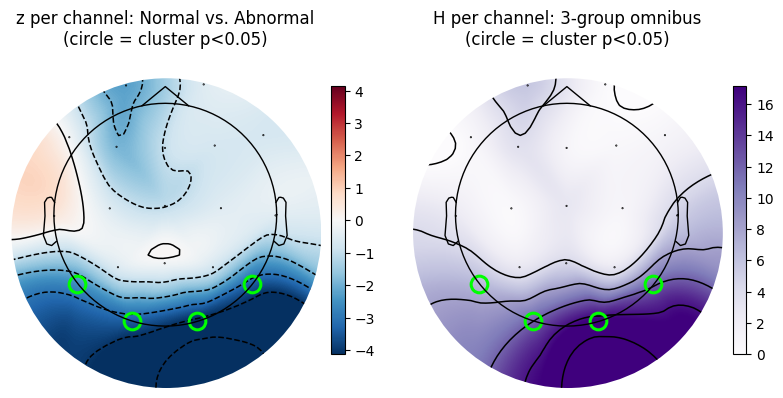

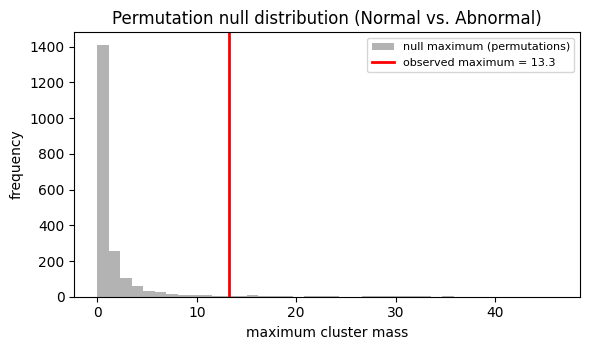

In [ ]:
# --- Topomap of the observed statistic, highlighting channels in significant clusters ---
# (mask now drawn by MNE's own mask_params inside plot_topomap; this is the figure the
# codirector flagged -- the v12 version's manual scatter overlay was not itself the source
# of the "arrow" artifacts, but the underlying griddata interpolation was, so it is fixed
# by the switch to mne.viz.plot_topomap in the base plot_topomap function above.)
def plot_topomap_clusters(stat, clusters, ax, title, cmap="RdBu_r", signed=True):
    vmax = np.abs(stat).max() if signed else stat.max()
    vlim = (-vmax, vmax) if signed else (0, vmax)
    sig_idx = [ch for c in clusters if c["p_value"] < 0.05 for ch in c["channels"]]
    mask = np.zeros(N_CH, dtype=bool)
    if sig_idx:
        mask[sig_idx] = True
    cf = plot_topomap(stat, ax, title, vlim, cmap=cmap if signed else "Purples",
                       mask=mask if sig_idx else None)
    return cf

fig, ax = plt.subplots(1, 2, figsize=(9.5,4.4))
cf1 = plot_topomap_clusters(z_NA, clusters_NA, ax[0], "z per channel: Normal vs. Abnormal\n(circle = cluster p<0.05)")
cf2 = plot_topomap_clusters(H_omni, clusters_omni, ax[1], "H per channel: 3-group omnibus\n(circle = cluster p<0.05)",
                             signed=False)
fig.colorbar(cf1, ax=ax[0], fraction=0.04, pad=0.03)
fig.colorbar(cf2, ax=ax[1], fraction=0.04, pad=0.03)
plt.savefig("cluster_permutation_topomap.png", dpi=150, bbox_inches="tight"); plt.show()

# --- null distribution vs. observed statistic (Normal vs Abnormal) ---
plt.figure(figsize=(6,3.6))
plt.hist(null_NA, bins=40, color="0.7", label="null maximum (permutations)")
if clusters_NA:
    obs_mass = clusters_NA[0]["mass"]
    plt.axvline(obs_mass, color="red", lw=2, label=f"observed maximum = {obs_mass:.1f}")
plt.xlabel("maximum cluster mass"); plt.ylabel("frequency")
plt.title("Permutation null distribution (Normal vs. Abnormal)"); plt.legend(fontsize=8)
plt.tight_layout(); plt.savefig("null_distribution.png", dpi=150, bbox_inches="tight"); plt.show()

### Section 19 notes
- Low `N_PERM` implies a floor p-value of `1/(N_PERM+1)` (e.g. 2000 perms -> smallest reportable p is 0.0005); raise `N_PERM` to 5000-10000 for the final analysis.
- The cluster-forming threshold (`Z_THRESH` / `thresh_omni`) is a methodological choice, not a result: lower thresholds give larger, less anatomically specific clusters; higher thresholds give smaller, more focal ones. Report the threshold used (already printed above) and, if possible, check that the conclusion is qualitatively stable under a nearby threshold (e.g. z=1.65 or z=2.33).

### 19.1 Cluster-based permutation test — Wasserstein metric

--- Normal vs. Abnormal (MCI+Dementia) -- Wasserstein: 1 cluster(s) found ---
  Cluster 1: channels=['Fp1', 'FZ', 'CZ', 'P4', 'O2', 'O1', 'T5', 'T3', 'T6', 'T4', 'F8', 'PZ', 'P3', 'C4', 'C3', 'F4', 'F3', 'F7', 'Fp2']  mass=80.58  p=0.0005  -> significant (p<0.05)

--- Normal vs MCI -- Wasserstein: 1 cluster(s) found ---
  Cluster 1: channels=['Fp1', 'FZ', 'F4', 'C4', 'P4', 'O2', 'O1', 'P3', 'C3', 'T5', 'T6', 'PZ', 'T4', 'F8', 'F3', 'F7', 'Fp2']  mass=53.94  p=0.0015  -> significant (p<0.05)

--- MCI vs Dementia -- Wasserstein: 3 cluster(s) found ---
  Cluster 1: channels=['P4', 'T6']  mass=4.94  p=0.0745  -> not significant
  Cluster 2: channels=['T5', 'P3']  mass=4.20  p=0.1114  -> not significant
  Cluster 3: channels=['F7']  mass=2.60  p=0.1374  -> not significant

--- Normal vs Dementia -- Wasserstein: 1 cluster(s) found ---
  Cluster 1: channels=['Fp1', 'FZ', 'CZ', 'P4', 'O2', 'O1', 'T5', 'T6', 'T4', 'F8', 'PZ', 'P3', 'C4', 'C3', 'F4', 'F3', 'F7', 'Fp2']  mass=79.24  p=0.0005  -> 

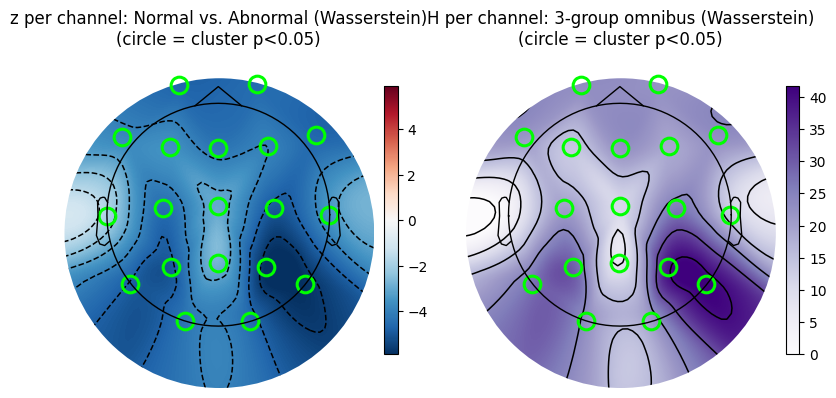


=== Cluster overlap: Euclidean vs. Wasserstein (Normal vs. Abnormal) ===
Euclidean significant cluster channels:   ['O1', 'O2', 'T5', 'T6']
Wasserstein significant cluster channels: ['C3', 'C4', 'CZ', 'F3', 'F4', 'F7', 'F8', 'FZ', 'Fp1', 'Fp2', 'O1', 'O2', 'P3', 'P4', 'PZ', 'T3', 'T4', 'T5', 'T6']
Overlap: ['O1', 'O2', 'T5', 'T6']  (4/19 of the union)


In [ ]:
clusters_NA_qf, z_NA_qf, null_NA_qf = cluster_permutation_2groups(
    sv_subject_bin_qf["Normal"], sv_subject_bin_qf["Abnormal"], ADJACENCY, n_perm=N_PERM, thresh=Z_THRESH, seed=1)
report_clusters(clusters_NA_qf, "Normal vs. Abnormal (MCI+Dementia) -- Wasserstein")

clusters_pairs_qf = {}
for g1, g2, name in pair_defs:
    cl, z, nullmax = cluster_permutation_2groups(
        sv_subject_qf[g1], sv_subject_qf[g2], ADJACENCY, n_perm=N_PERM, thresh=Z_THRESH, seed=hash(name) % 1000)
    clusters_pairs_qf[name] = cl
    report_clusters(cl, f"{name} -- Wasserstein")

clusters_omni_qf, H_omni_qf, null_omni_qf, thresh_omni_qf = cluster_permutation_kgroups(
    [sv_subject_qf[0], sv_subject_qf[1], sv_subject_qf[2]], ADJACENCY, n_perm=N_PERM, seed=42)
report_clusters(clusters_omni_qf, f"3-group omnibus (Kruskal-Wallis, Wasserstein, threshold H={thresh_omni_qf:.2f})")

fig, ax = plt.subplots(1, 2, figsize=(9.5,4.4))
cf1 = plot_topomap_clusters(z_NA_qf, clusters_NA_qf, ax[0], "z per channel: Normal vs. Abnormal (Wasserstein)\n(circle = cluster p<0.05)")
cf2 = plot_topomap_clusters(H_omni_qf, clusters_omni_qf, ax[1], "H per channel: 3-group omnibus (Wasserstein)\n(circle = cluster p<0.05)",
                             signed=False)
fig.colorbar(cf1, ax=ax[0], fraction=0.04, pad=0.03)
fig.colorbar(cf2, ax=ax[1], fraction=0.04, pad=0.03)
plt.savefig("cluster_permutation_topomap_wasserstein.png", dpi=150, bbox_inches="tight"); plt.show()

print("\n=== Cluster overlap: Euclidean vs. Wasserstein (Normal vs. Abnormal) ===")
sig_channels_E = set(ch for c in clusters_NA if c["p_value"]<0.05 for ch in c["channels"])
sig_channels_W = set(ch for c in clusters_NA_qf if c["p_value"]<0.05 for ch in c["channels"])
overlap = sig_channels_E & sig_channels_W
print(f"Euclidean significant cluster channels:   {sorted(CANONICAL[i] for i in sig_channels_E)}")
print(f"Wasserstein significant cluster channels: {sorted(CANONICAL[i] for i in sig_channels_W)}")
print(f"Overlap: {sorted(CANONICAL[i] for i in overlap)}  ({len(overlap)}/{len(sig_channels_E|sig_channels_W) or 1} of the union)")


## 20. Summary: Euclidean (Gram/L2) vs. Wasserstein dissimilarity

In [ ]:
# Consolidated view of everything computed under both metrics above, to answer the core
# methodological question: does treating each electrode's PSD curve as a vector in a
# Hilbert space (Euclidean/Gram) vs. as an energy-mass distribution over frequency
# (Wasserstein) change WHICH variogram model wins, HOW STRONG the parameter/electrode/
# cluster group differences are, and WHERE (which electrodes/clusters) the effect is
# localized?

print("=== 1. Best variogram model per group ===")
print(f"{'Group':10s} {'Euclidean':>14s} {'Wasserstein':>14s}")
for (nameE, bestE, *_), (nameW, bestW, *_) in zip(summary, summary_qf):
    print(f"{nameE:10s} {bestE:>14s} {bestW:>14s}")

print("\n=== 2. Group-level RMSE of the winning model ===")
print(f"{'Group':10s} {'RMSE Euclidean':>15s} {'RMSE Wasserstein':>17s}")
for (nameE, bestE, _,_,_, rmseE, r2E, _), (nameW, bestW, _,_,_, rmseW, r2W, _) in zip(summary, summary_qf):
    print(f"{nameE:10s} {rmseE:15.4f} {rmseW:17.4f}")

print("\n=== 3. Subject-level group-difference significance (Kruskal-Wallis p, 3 groups) ===")
for key, label in PARAM_LABELS.items():
    _, pE = kw_results[key]; _, pW = kw_results_qf[key]
    print(f"{label:24s} Euclidean p={pE:.2e}   Wasserstein p={pW:.2e}")

print("\n=== 4. Electrode-level significant channels (q<0.05) ===")
print(f"  Euclidean:   KW={n_sig_kw}/19   MW(N vs A)={n_sig_mw}/19")
print(f"  Wasserstein: KW={n_sig_kw_qf}/19   MW(N vs A)={n_sig_mw_qf}/19")

print("\n=== 5. Cluster-permutation, Normal vs. Abnormal ===")
def _best_cluster_str(clusters):
    sig = [c for c in clusters if c["p_value"] < 0.05]
    if not sig:
        return "no significant cluster"
    c = sig[0]
    return f"{len(c['channels'])} channels, mass={c['mass']:.2f}, p={c['p_value']:.4f}"
print(f"  Euclidean:   {_best_cluster_str(clusters_NA)}")
print(f"  Wasserstein: {_best_cluster_str(clusters_NA_qf)}")

print("\nCaveat: nugget/sill are on DIFFERENT physical scales for the two metrics (squared "
      "log10-power for the Gram/L2 dissimilarity vs. squared Hz for the Wasserstein "
      "dissimilarity), so only within-metric comparisons across groups/severity, and the "
      "RANGE parameter (both expressed in the same inter-electrode-distance units), are "
      "directly comparable side by side. Whether the two metrics point to the SAME clinical "
      "conclusion (Normal vs. Abnormal separable; frontal/parietal sites driving it) is the "
      "relevant robustness check, not whether their raw sill/nugget numbers match.")


=== 1. Best variogram model per group ===
Group           Euclidean    Wasserstein
Normal           gaussian      spherical
MCI             spherical      spherical
Dementia      exponential      spherical

=== 2. Group-level RMSE of the winning model ===
Group       RMSE Euclidean  RMSE Wasserstein
Normal              0.0828            0.1509
MCI                 0.1021            0.0997
Dementia            0.0650            0.0997

=== 3. Subject-level group-difference significance (Kruskal-Wallis p, 3 groups) ===
nugget (c₀)              Euclidean p=4.60e-01   Wasserstein p=7.24e-04
total sill (c₀+c)        Euclidean p=8.15e-08   Wasserstein p=4.17e-06
range (a)                Euclidean p=3.20e-07   Wasserstein p=1.14e-01

=== 4. Electrode-level significant channels (q<0.05) ===
  Euclidean:   KW=3/19   MW(N vs A)=3/19
  Wasserstein: KW=18/19   MW(N vs A)=19/19

=== 5. Cluster-permutation, Normal vs. Abnormal ===
  Euclidean:   4 channels, mass=13.29, p=0.0295
  Wasserstein: 19 chann